######## PLOTTING DER FEATURE MAPS ########

In [1]:

import torch
import torch.nn as nn
import sys
sys.path.append("/home/zimame/ma-chaymaa-zimame")
from model.resnet18 import ResNet18
from torch.utils.data import DataLoader
from data.dataset import ImageWoofDataset

model = ResNet18(num_classes=7)

# Gewichte des besten Modells laden
model.load_state_dict(torch.load("/home/zimame/ma-chaymaa-zimame/checkpoints/best_model_test0_sgd5_2_test.pth"))

# Gerät festlegen
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Modell auf Gerät verschieben und in den Evaluierungsmodus setzen
model = model.to(device).eval()

# Datensatz mit 7 Klassen laden
val_dataset_7 = ImageWoofDataset(img_path="/home/zimame/data/imagewoof2", split='val', class_indices = [0,1,2,3,4,5,6])
# DataLoader für den Validierungsdatensatz erstellen, mit BS==8
val_loader = DataLoader(val_dataset_7, batch_size=8, shuffle=False)

# nur der erste Batch wird geladen (8 Bilder)
for images, labels in val_loader:
    break 

# Bilder ins Gerät verschieben
# with torch.no_grad() um den Speicherverbrauch zu reduzieren
with torch.no_grad():
    input_images = images.to(device)

feature_maps = []     # Liste um feature_maps zu speichern
layer_names = []      # Liste um Layer_namen zu speichern
handles = []       # Liste um Hook-Handles zu speichern, da diese zum Entfernen der Hooks benötigt werden

# forward hook wird für jedes Conv2d Layer registriert
# speichert output des Layers (feature_maps/activations) in feature_maps Liste
# name ist der Name des Layers

# "The hook will be called every time after forward() has computed an output" 
# deswegen muss ich später forward pass ausführen um die Hooks auszulösen und die feature maps zu bekommen
def hook_fn(name):
    def hook(module, inp, out):
        feature_maps.append(out.detach().cpu())
        layer_names.append(name)
    return hook

# echtes ResNet liegt im Wrapper unter model.model
for name, module in model.model.named_modules():
    if isinstance(module, nn.Conv2d):
        # Hook registrieren für jedes Conv2d Layer indem hook_fn mit dem Layer-Namen aufgerufen wird
        handles.append(module.register_forward_hook(hook_fn(name)))

# forward pass durchführen um die Hooks auszulösen
with torch.no_grad():
    forward_output = model(input_images)   
  
# Hooks entfernen
for h in handles:
    h.remove()

print("Anzahl Conv-Layer-Feature-Maps:", len(feature_maps))


Anzahl Conv-Layer-Feature-Maps: 20


In [2]:
# Feature Maps shape anzeigen (Output eines Conv Layers)
print("\nFeature maps shape")
for feature_map in feature_maps:
    print(feature_map.shape)



Feature maps shape
torch.Size([8, 64, 112, 112])
torch.Size([8, 64, 56, 56])
torch.Size([8, 64, 56, 56])
torch.Size([8, 64, 56, 56])
torch.Size([8, 64, 56, 56])
torch.Size([8, 128, 28, 28])
torch.Size([8, 128, 28, 28])
torch.Size([8, 128, 28, 28])
torch.Size([8, 128, 28, 28])
torch.Size([8, 128, 28, 28])
torch.Size([8, 256, 14, 14])
torch.Size([8, 256, 14, 14])
torch.Size([8, 256, 14, 14])
torch.Size([8, 256, 14, 14])
torch.Size([8, 256, 14, 14])
torch.Size([8, 512, 7, 7])
torch.Size([8, 512, 7, 7])
torch.Size([8, 512, 7, 7])
torch.Size([8, 512, 7, 7])
torch.Size([8, 512, 7, 7])


Batch size: 8


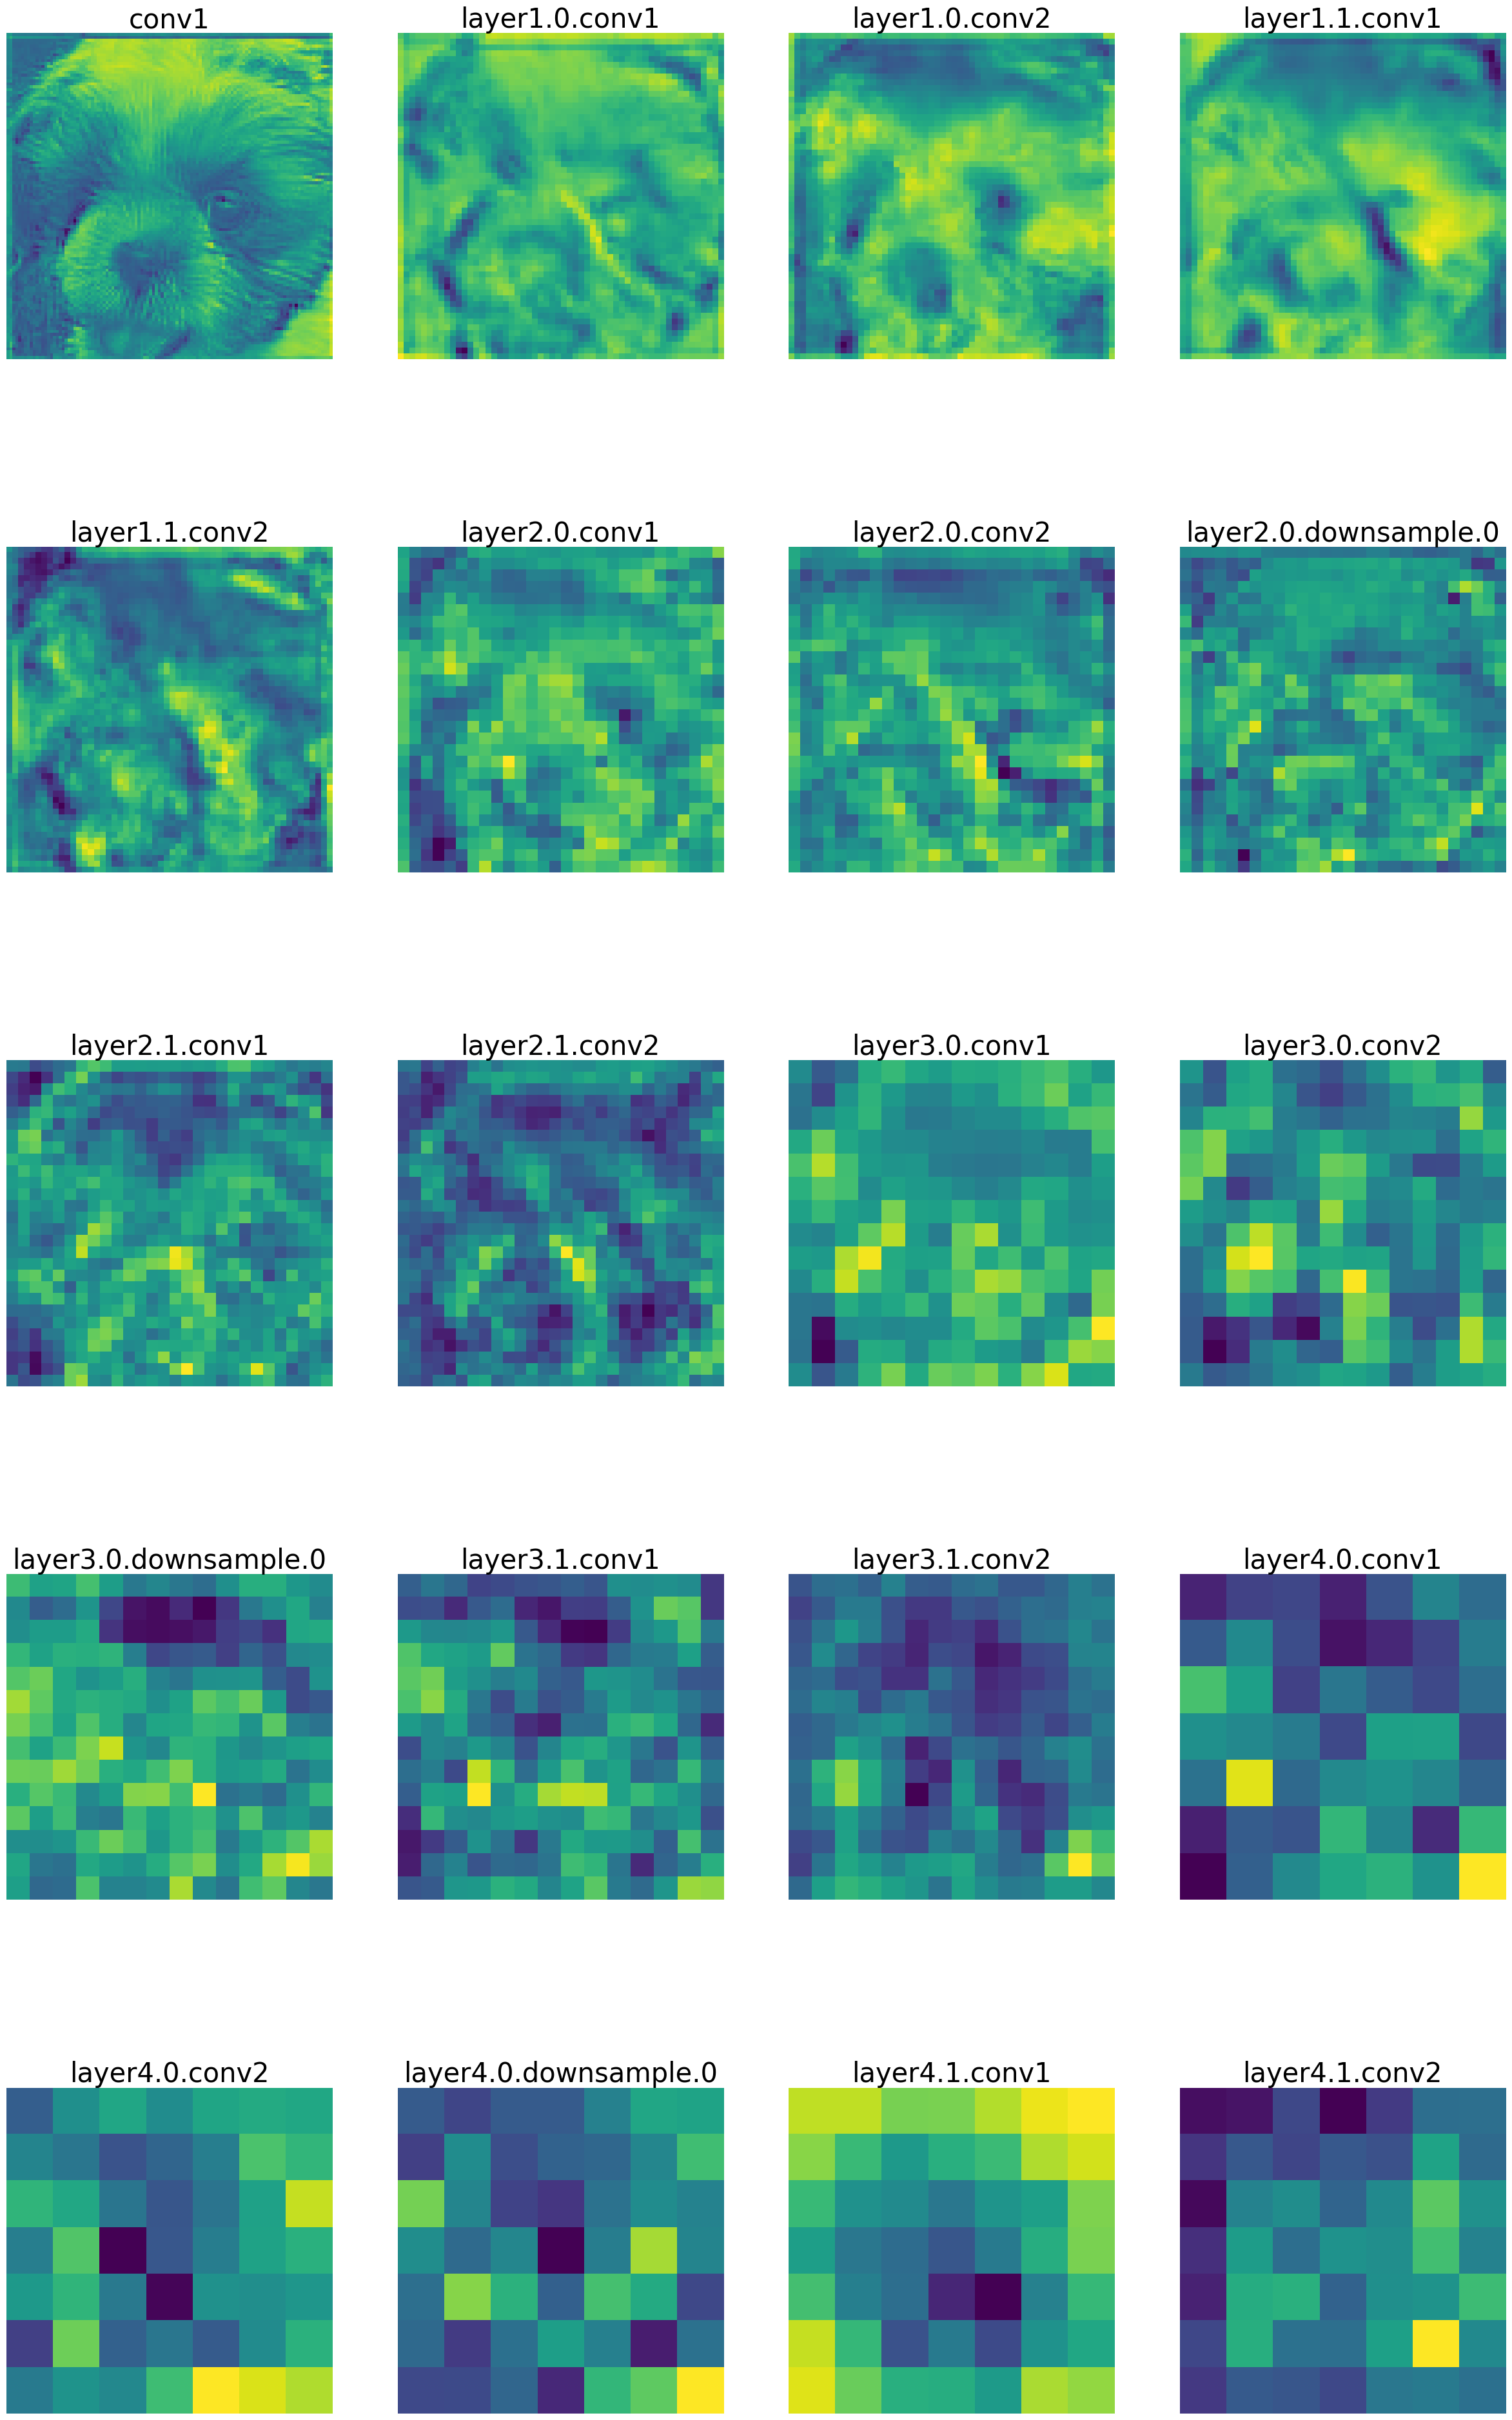

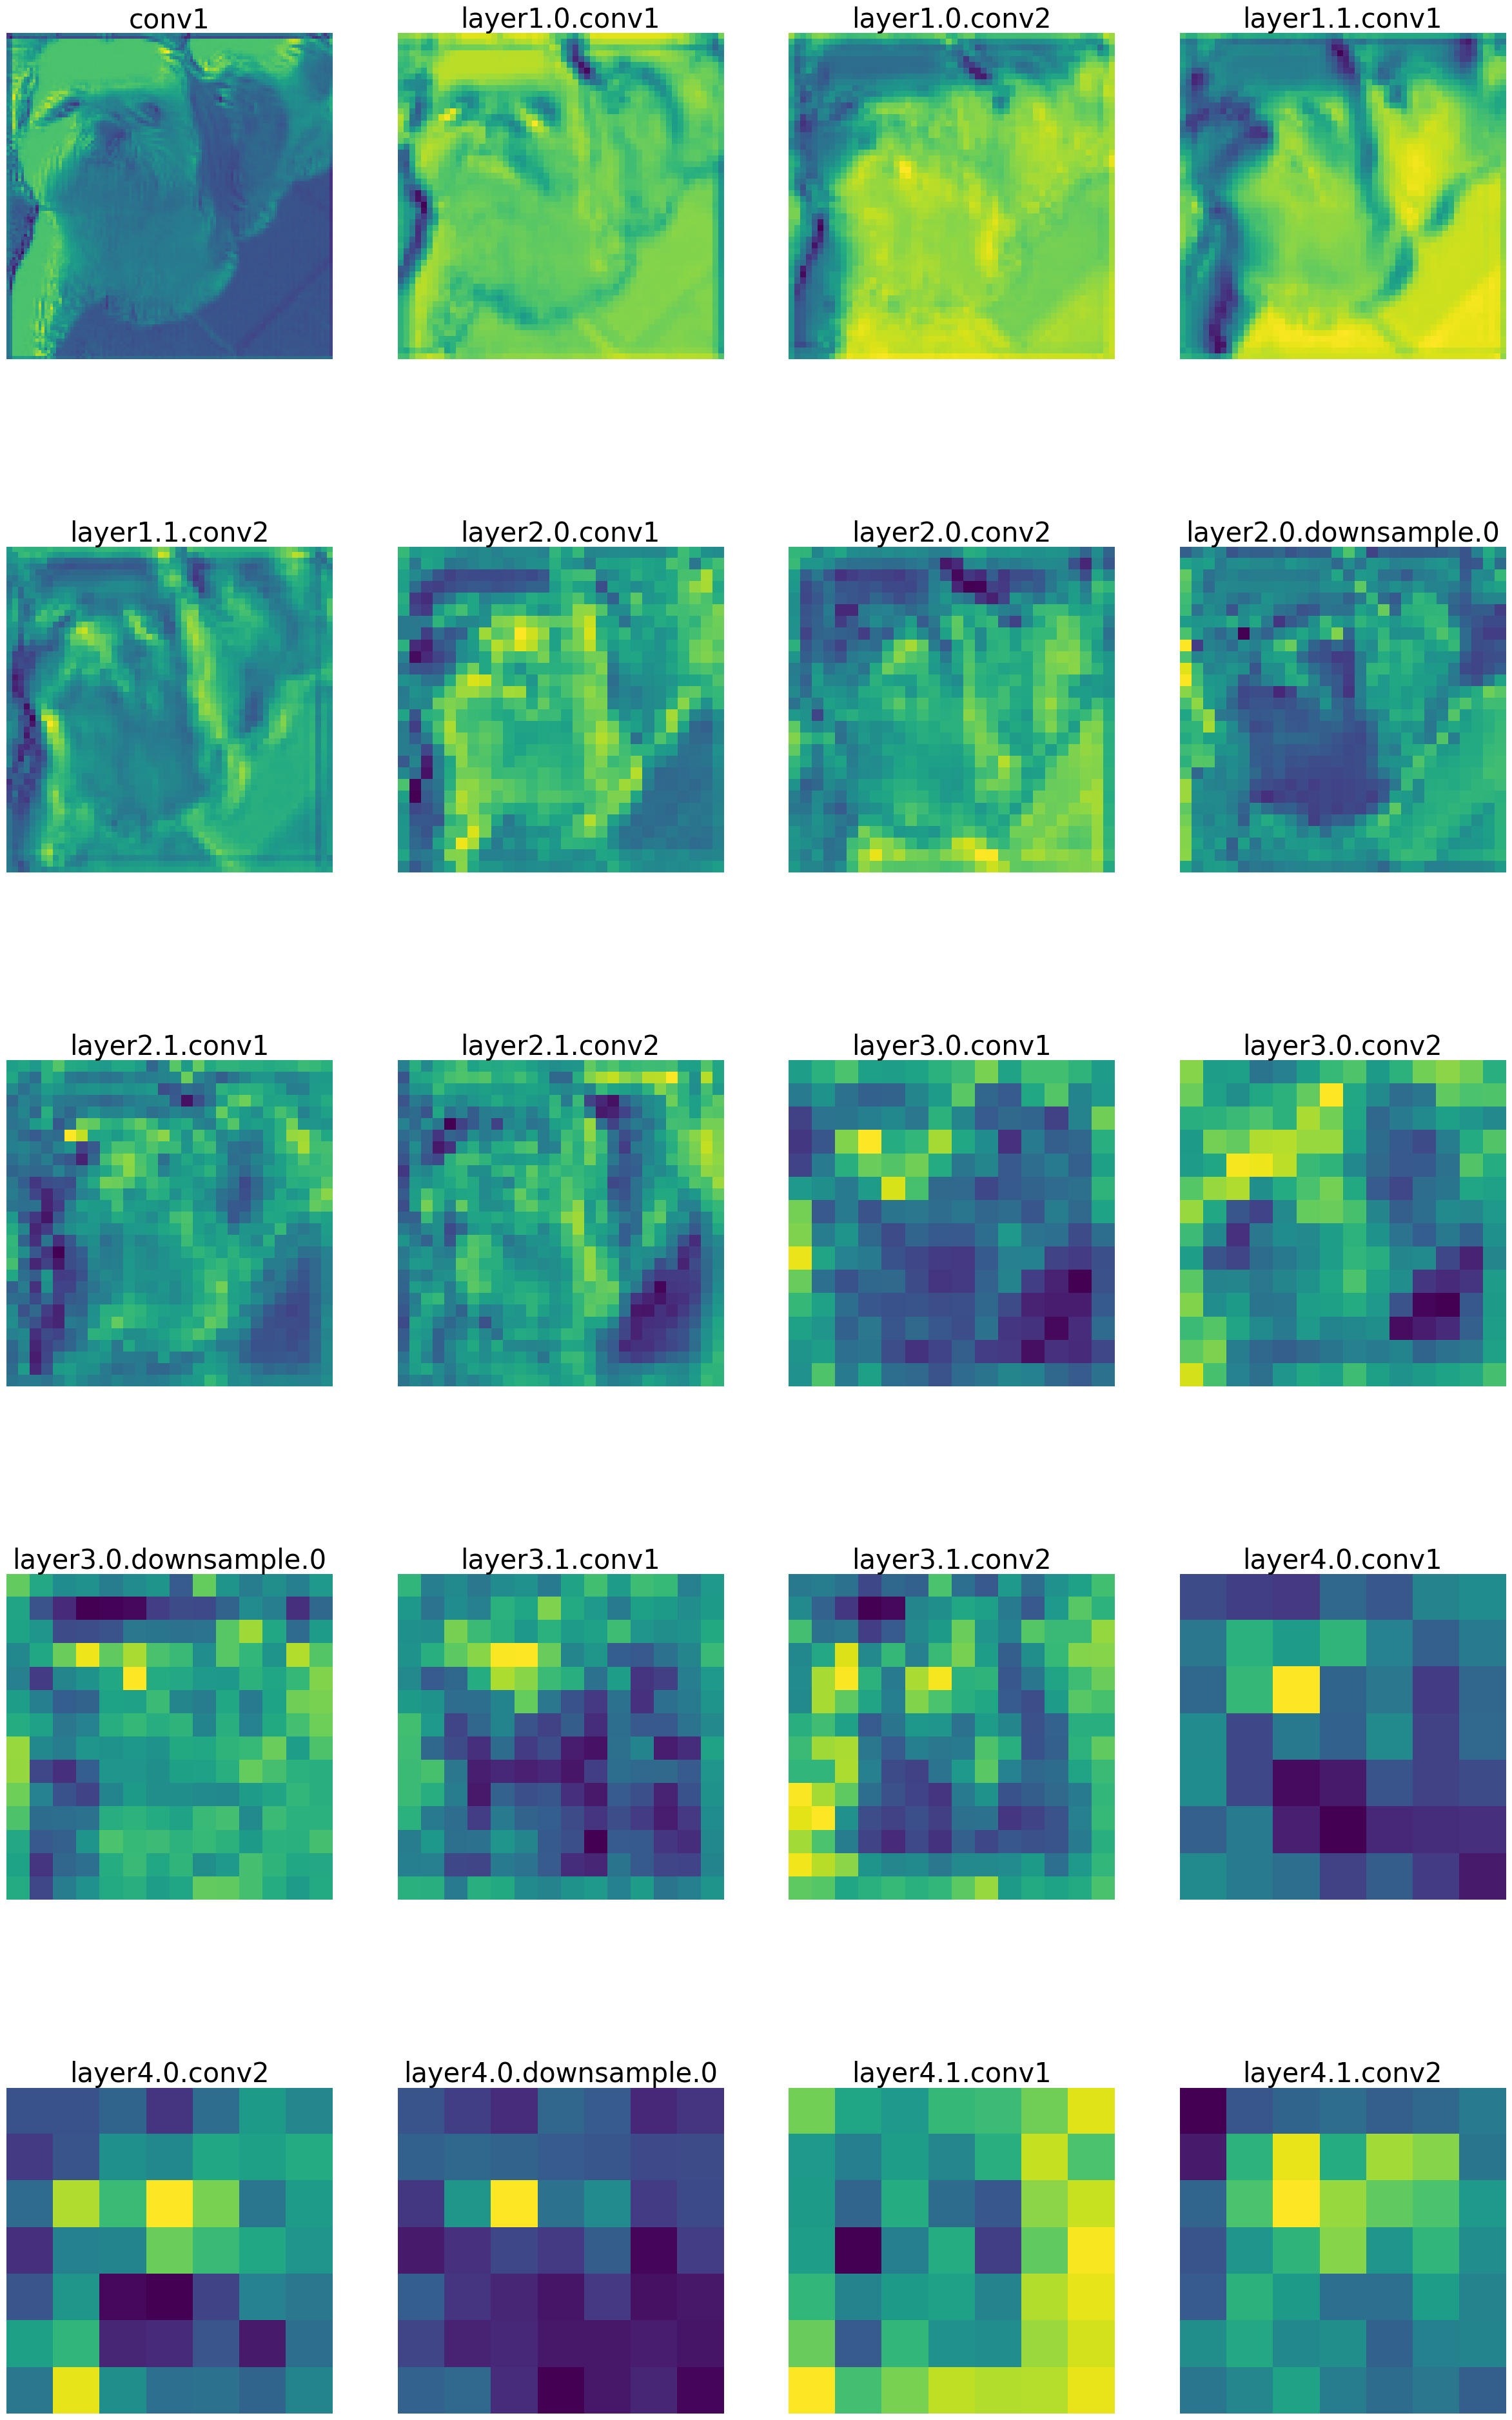

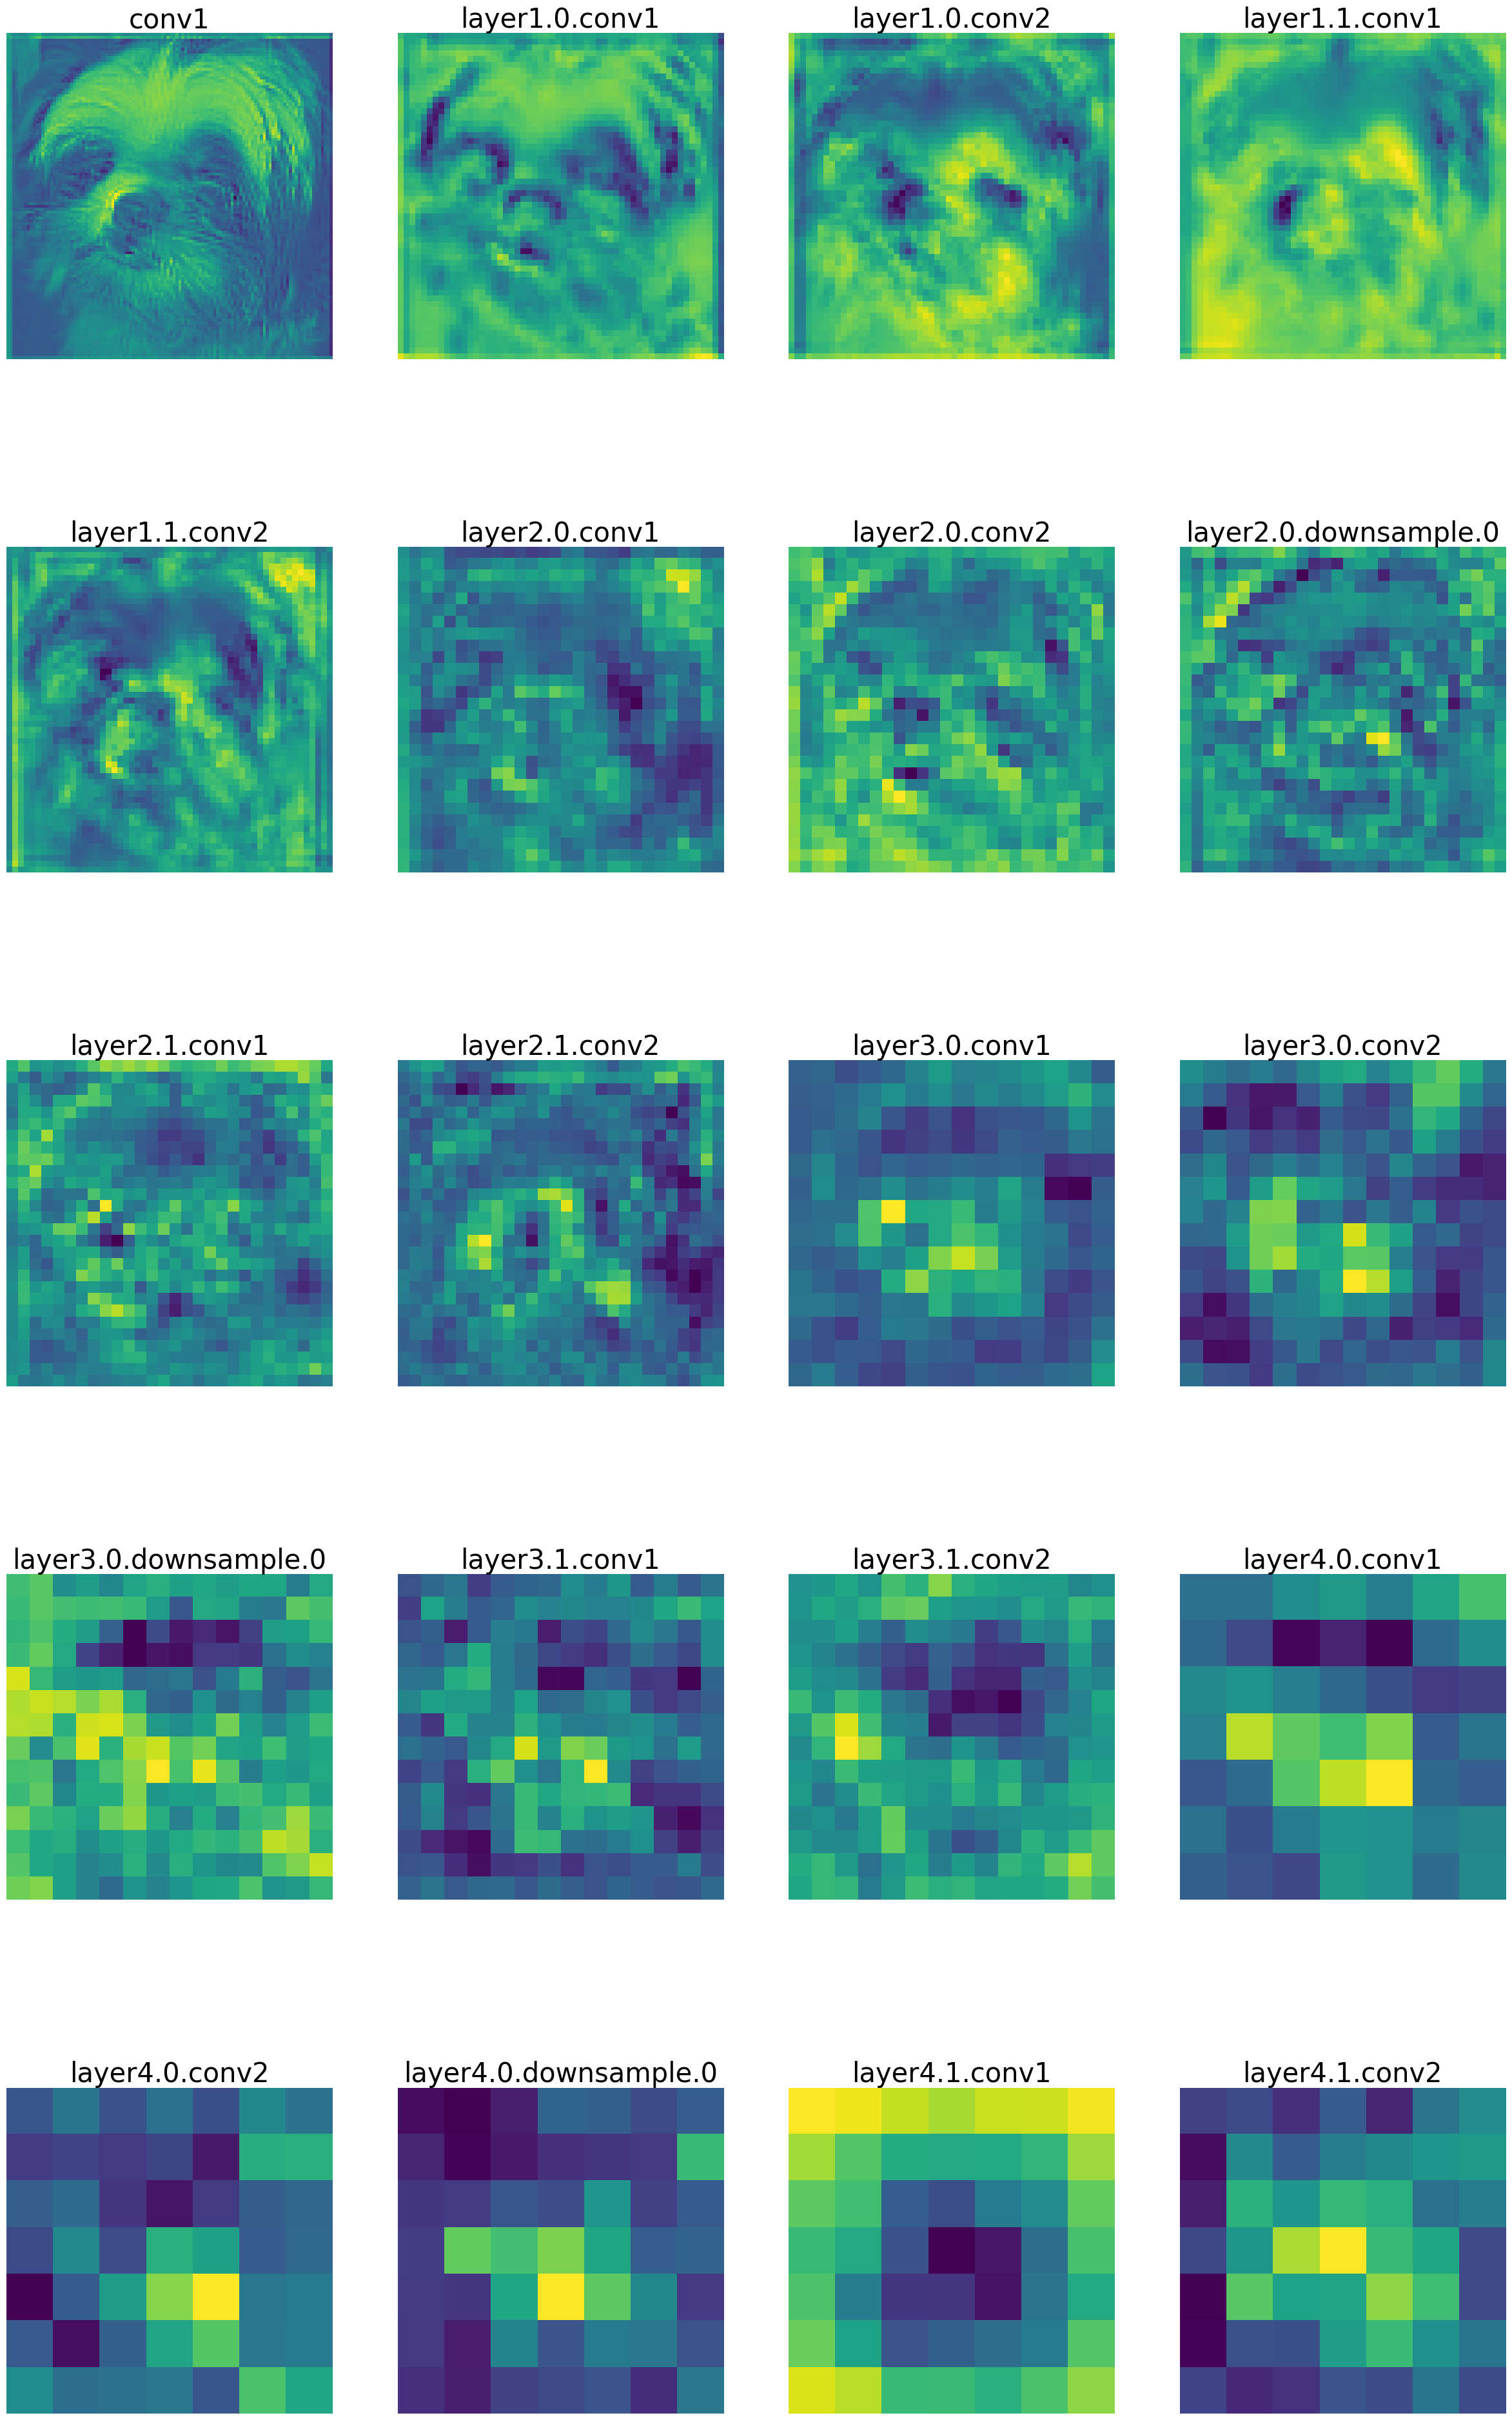

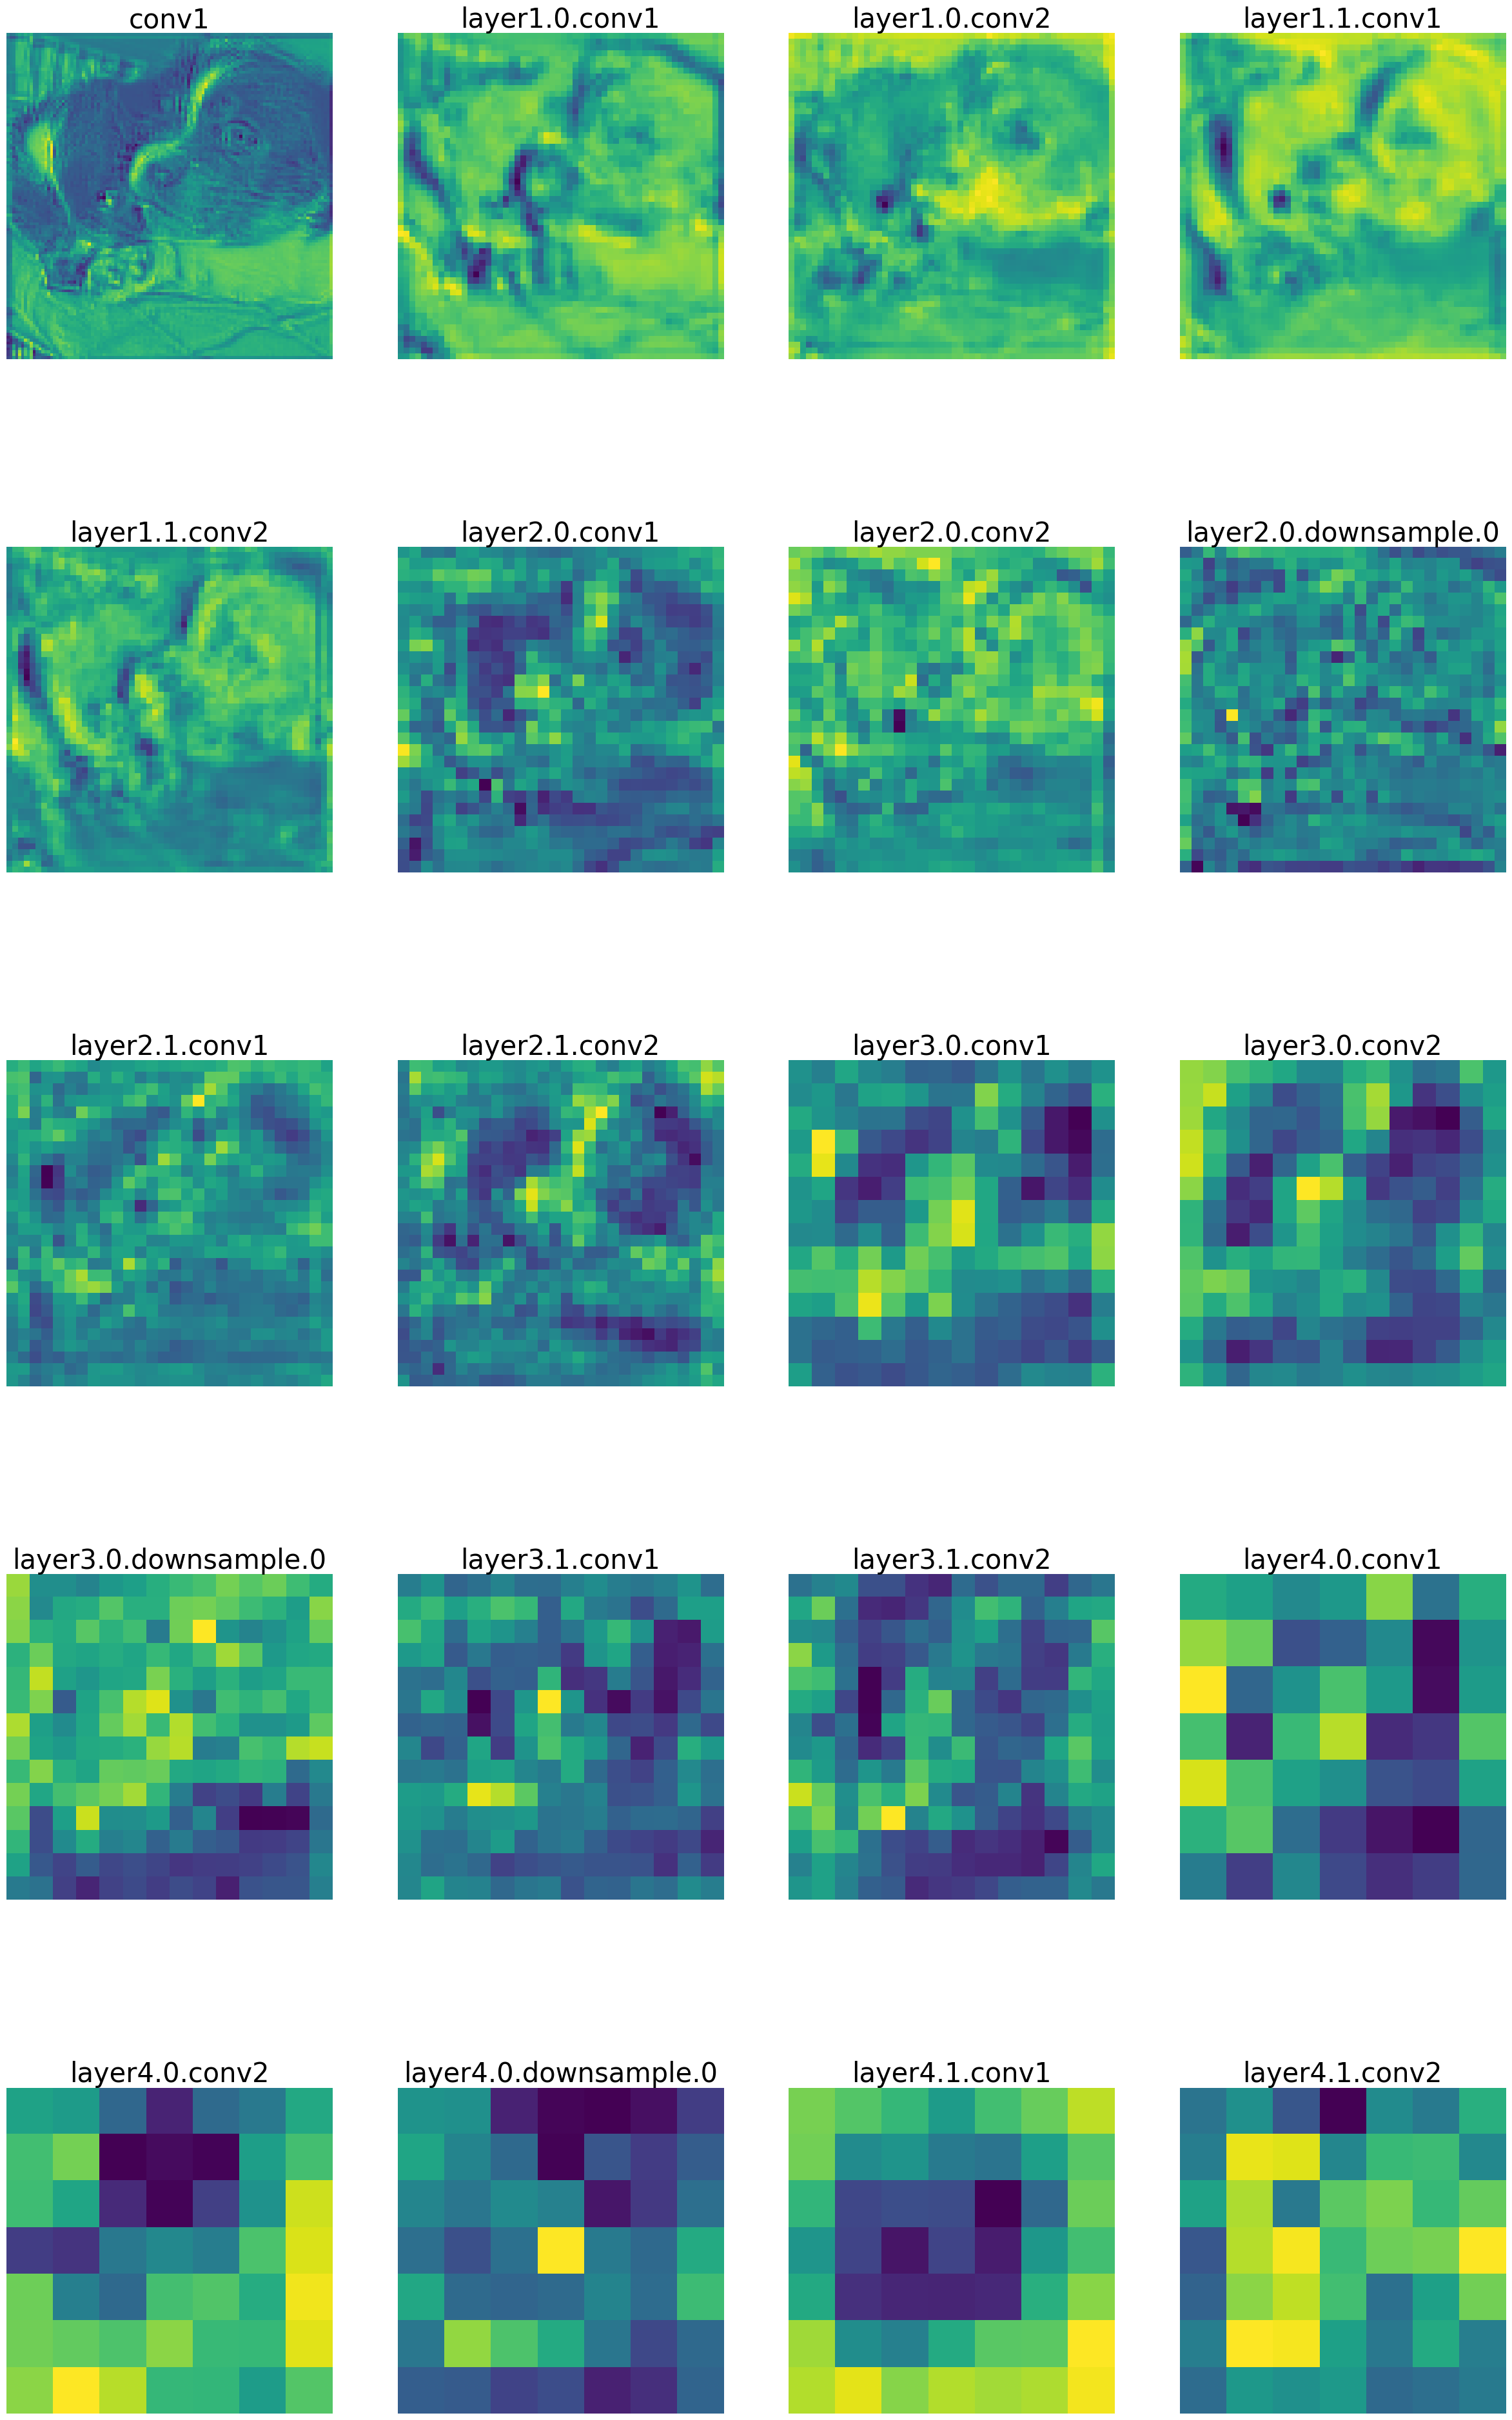

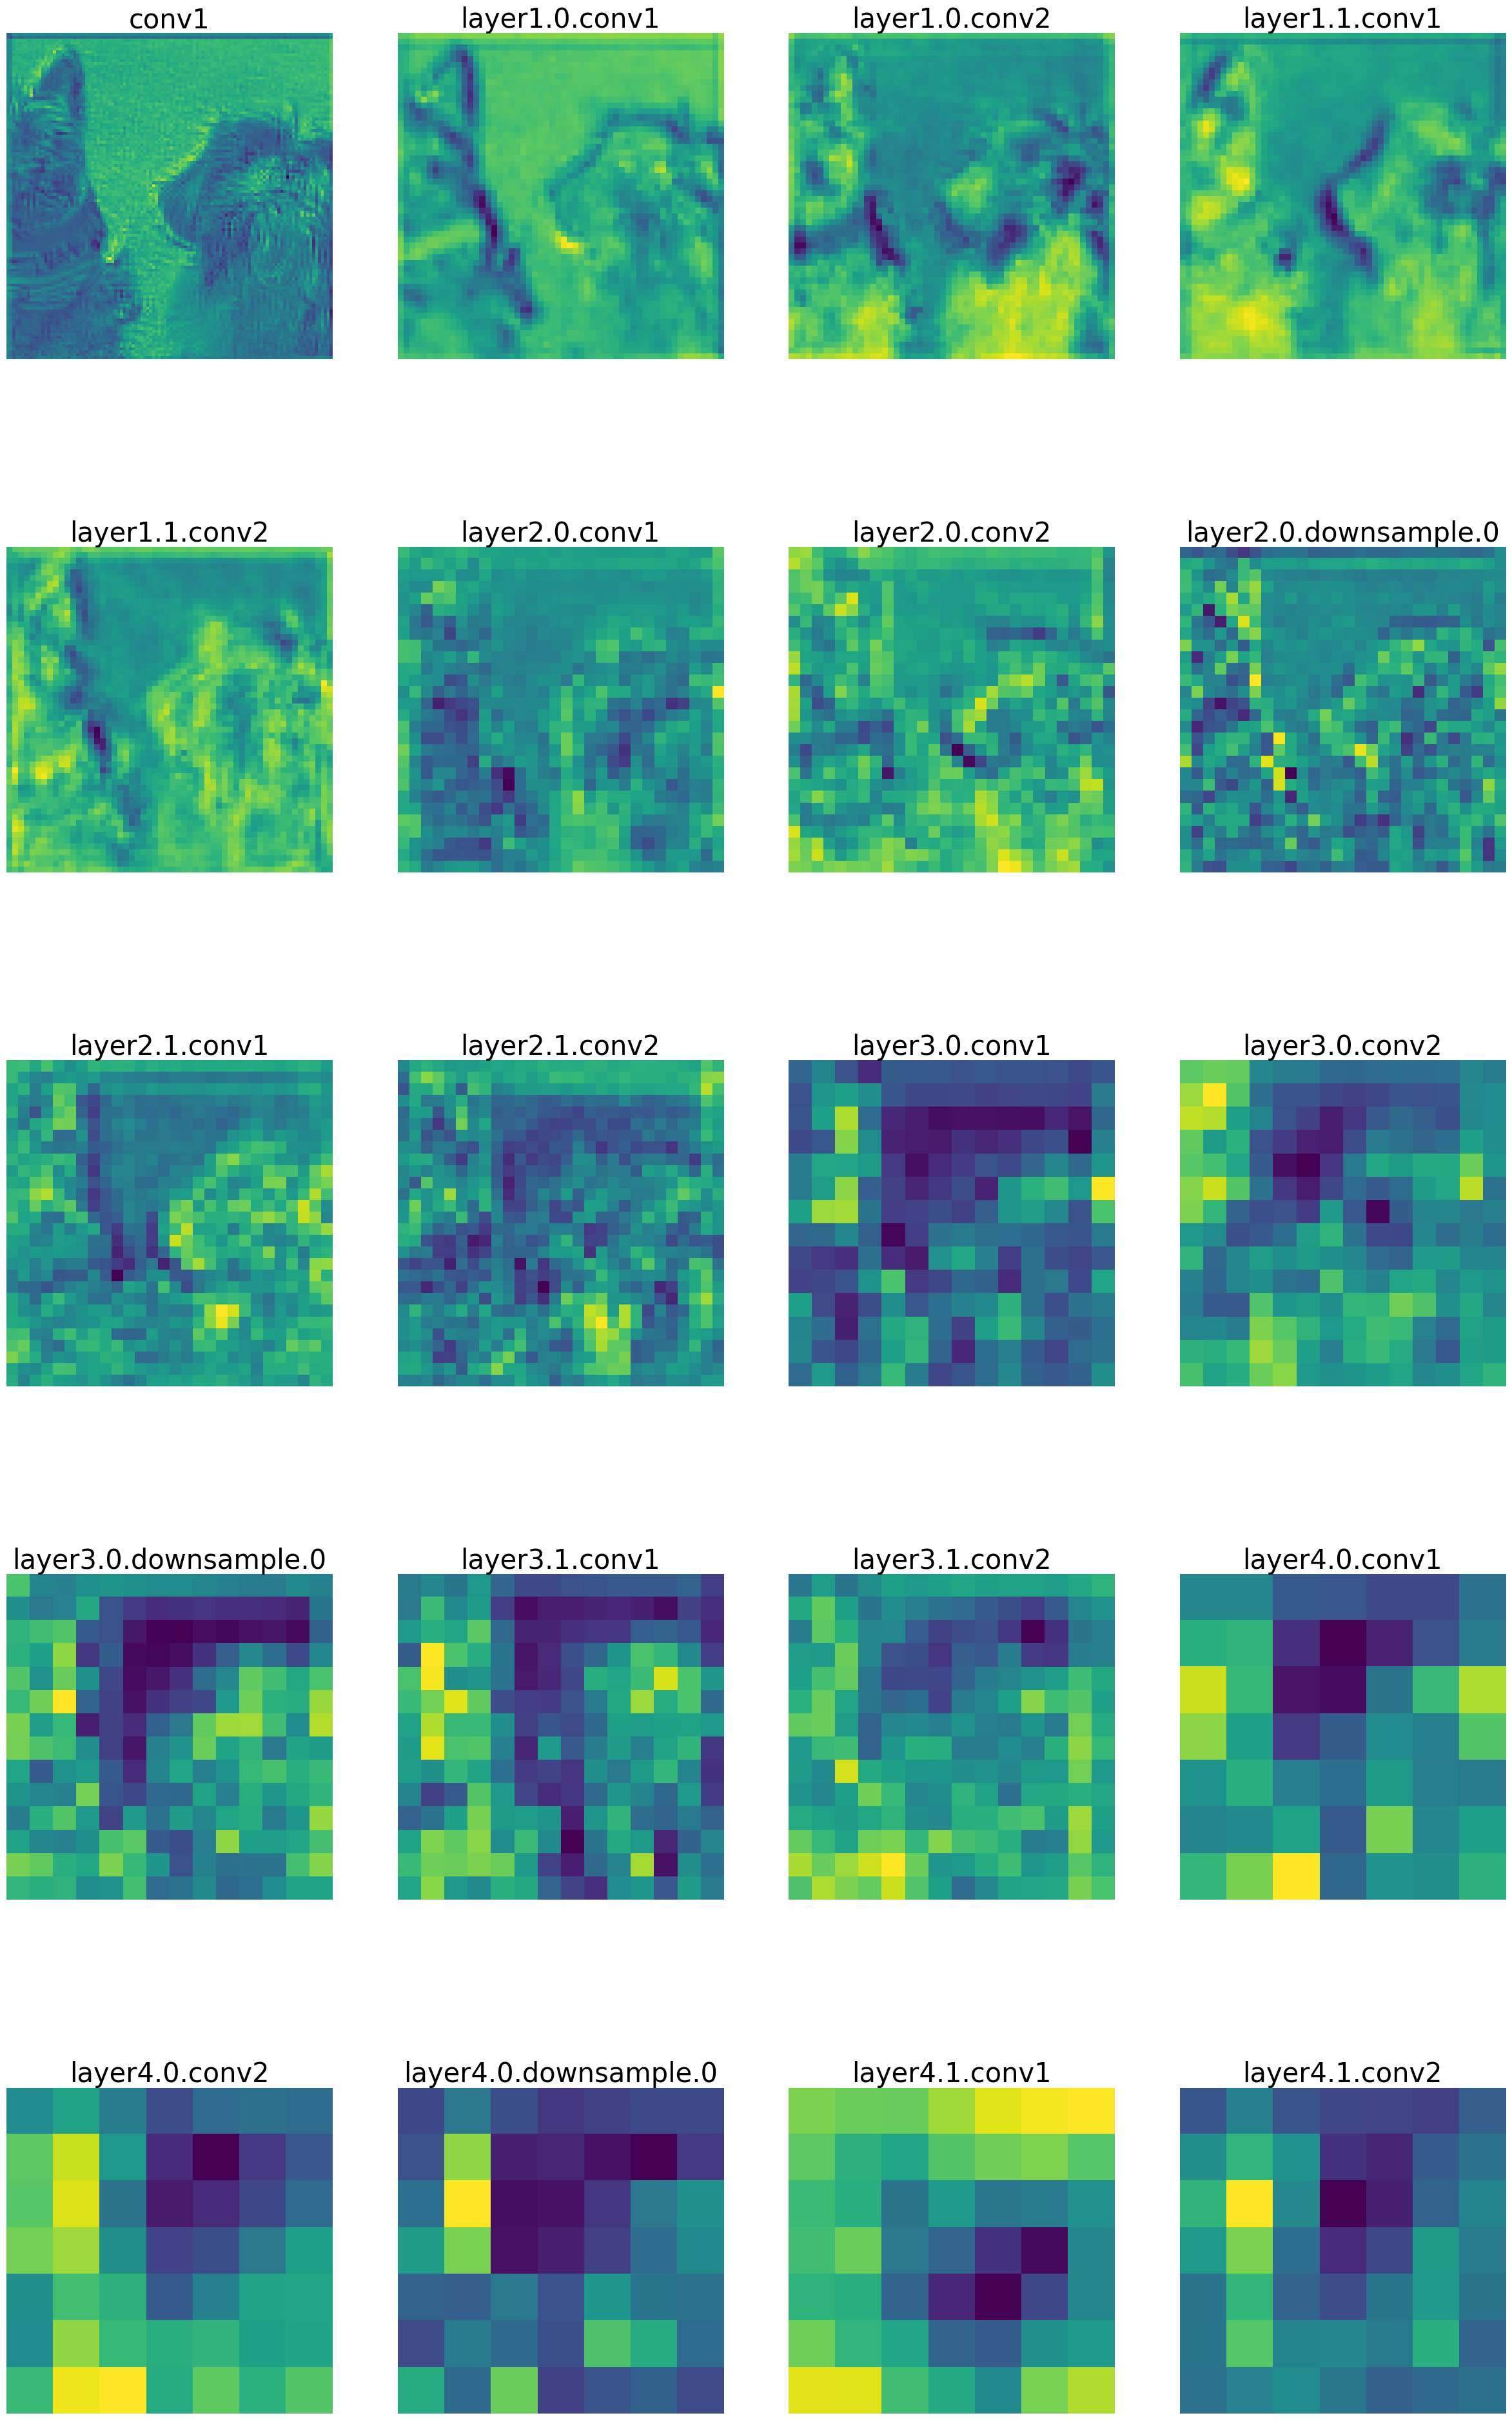

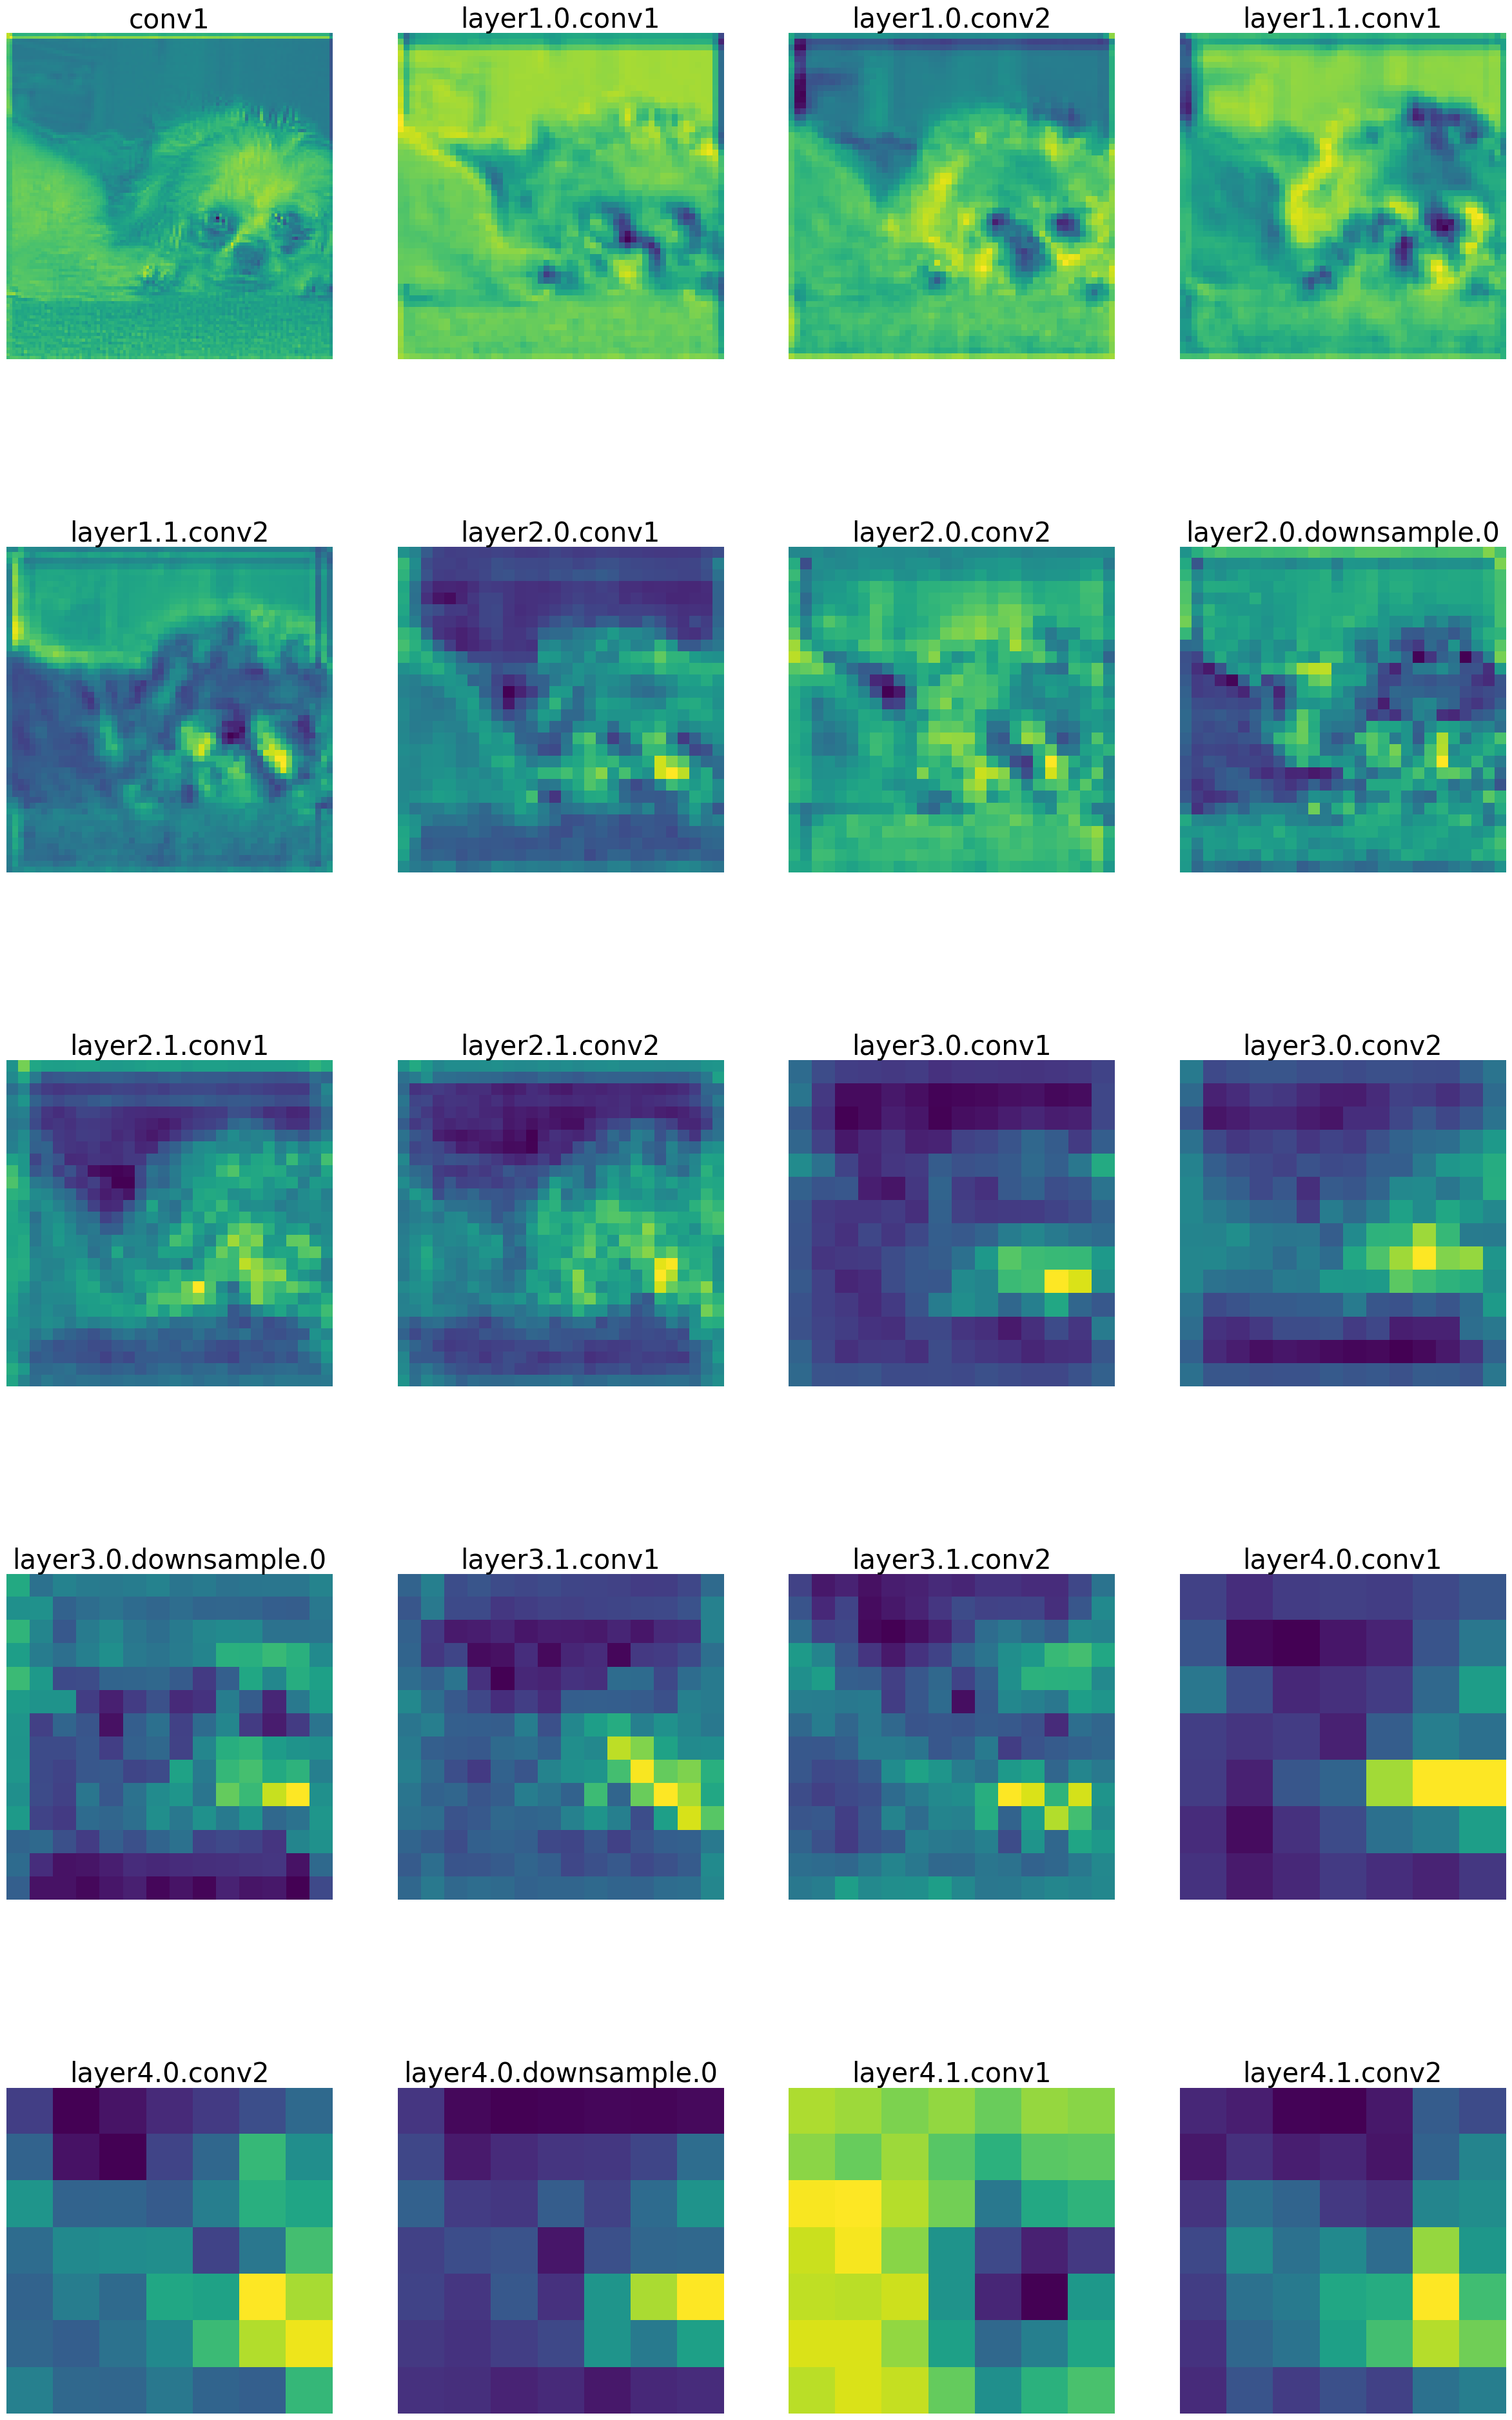

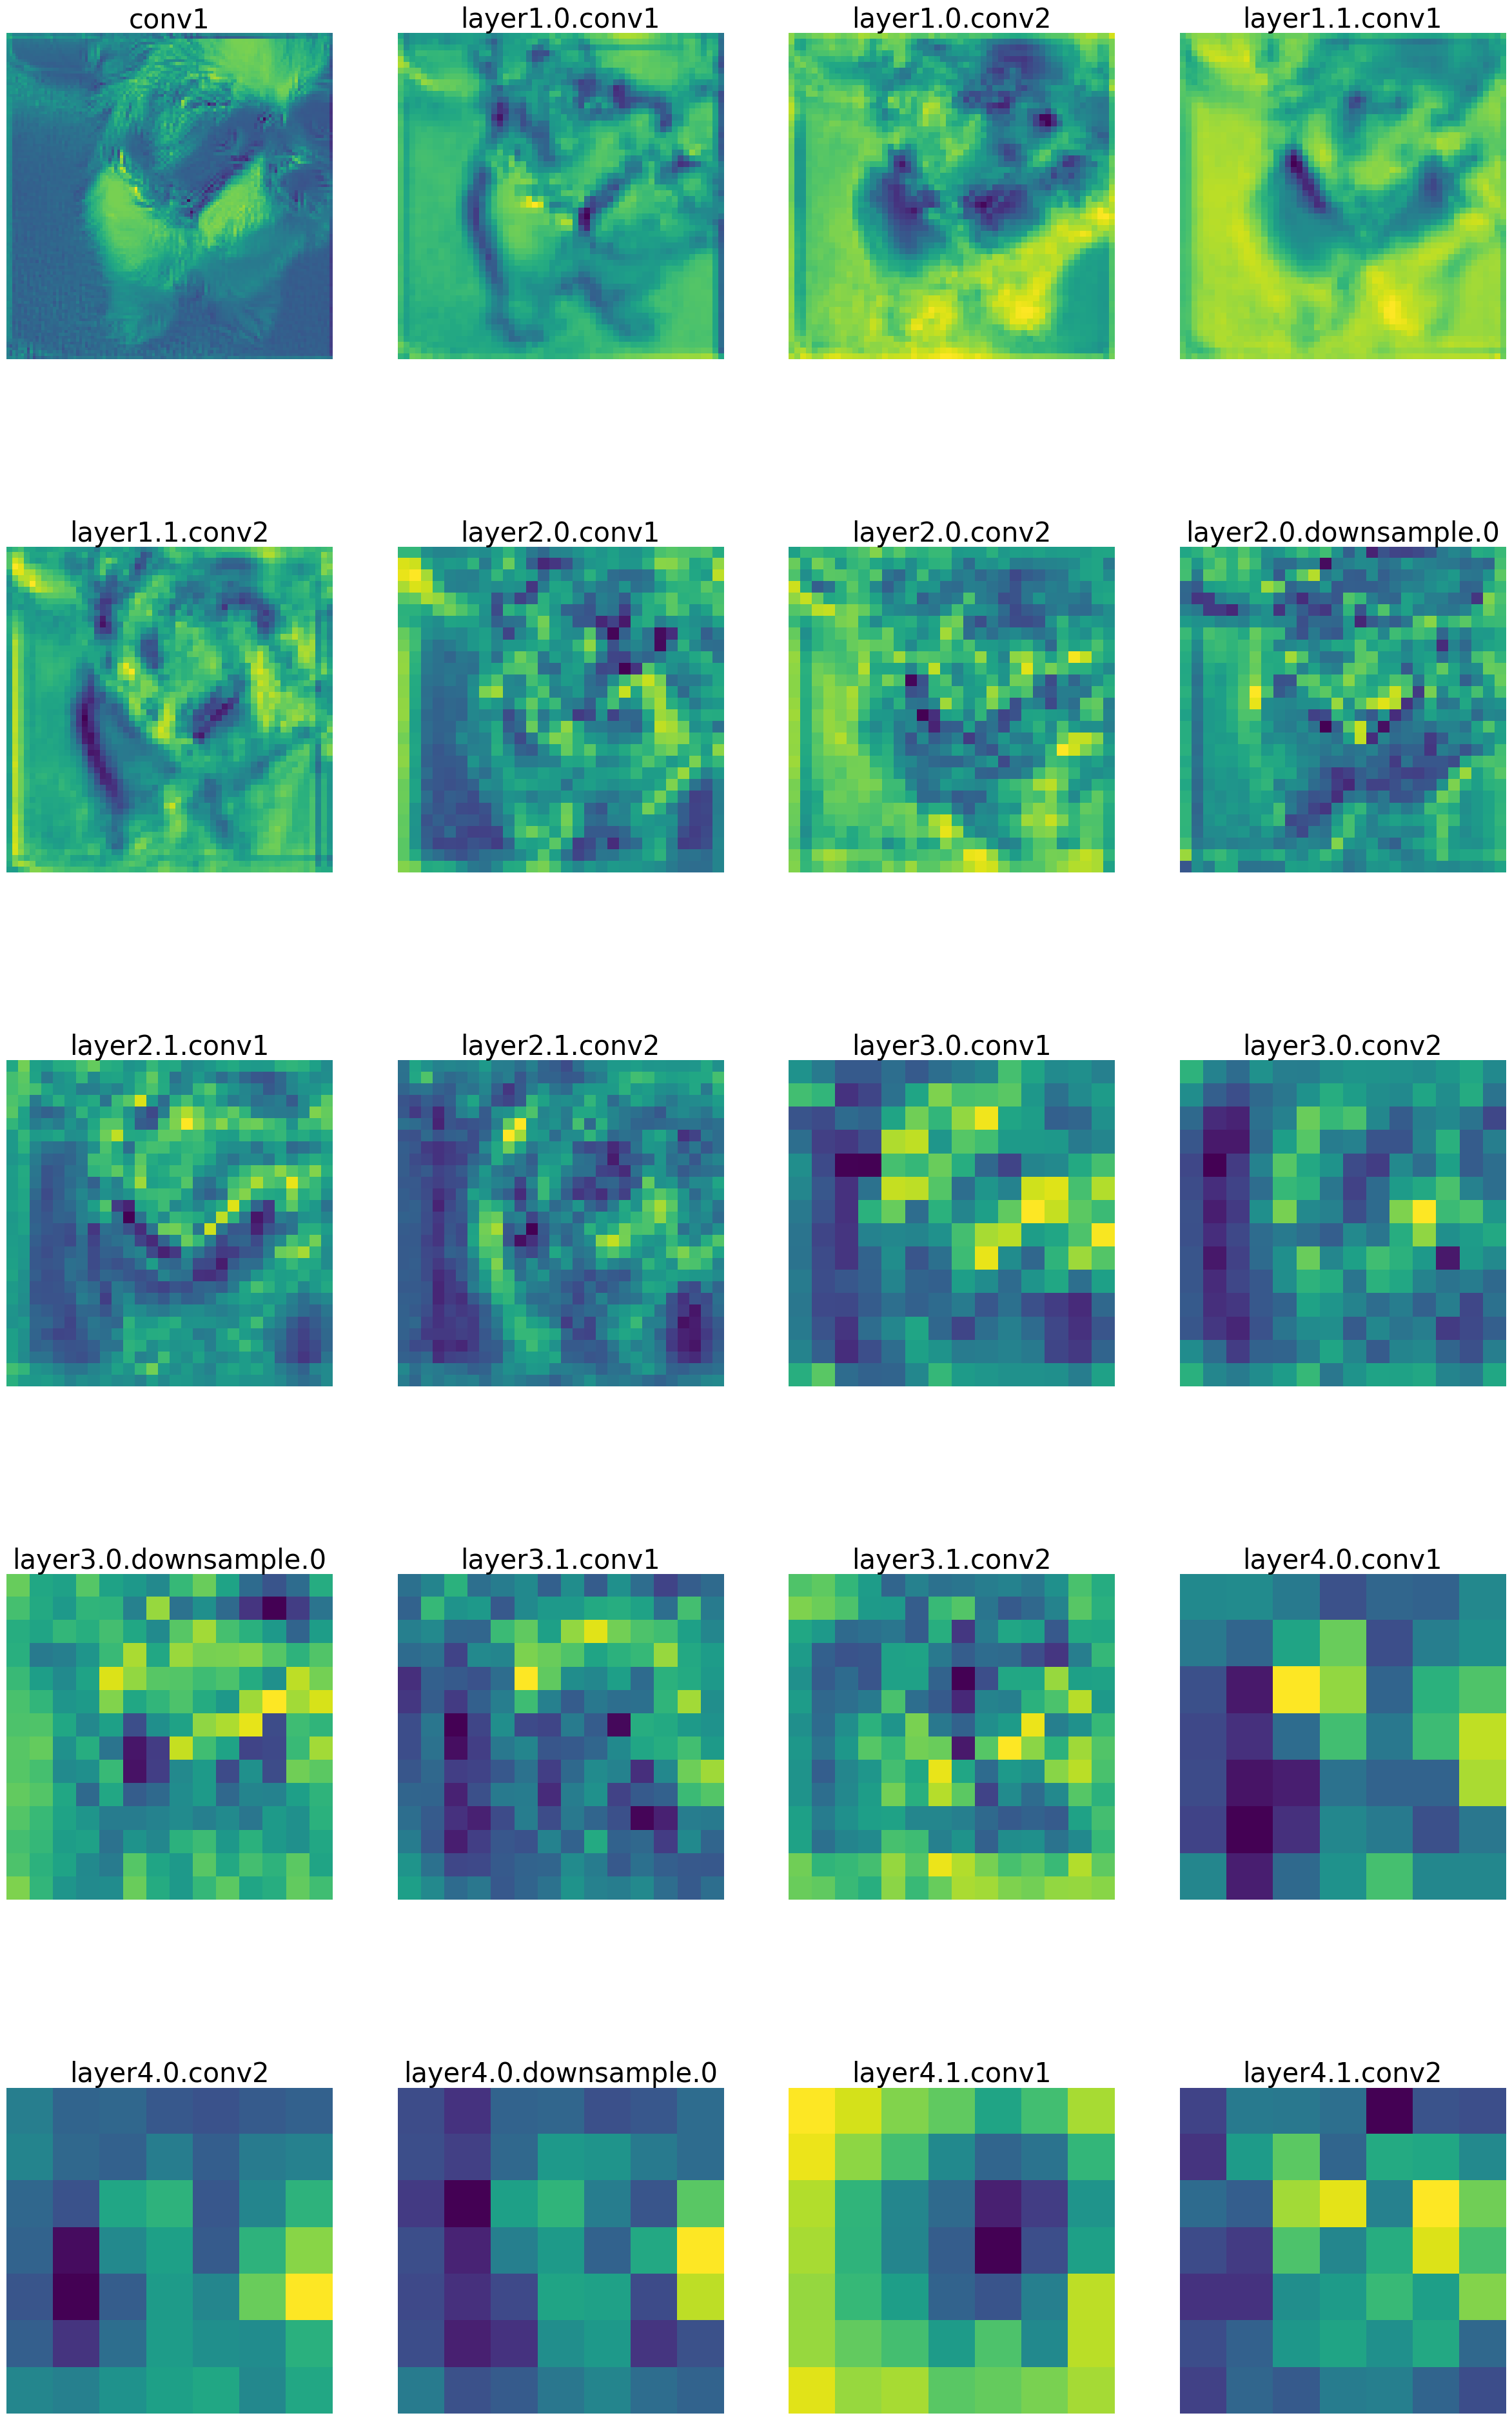

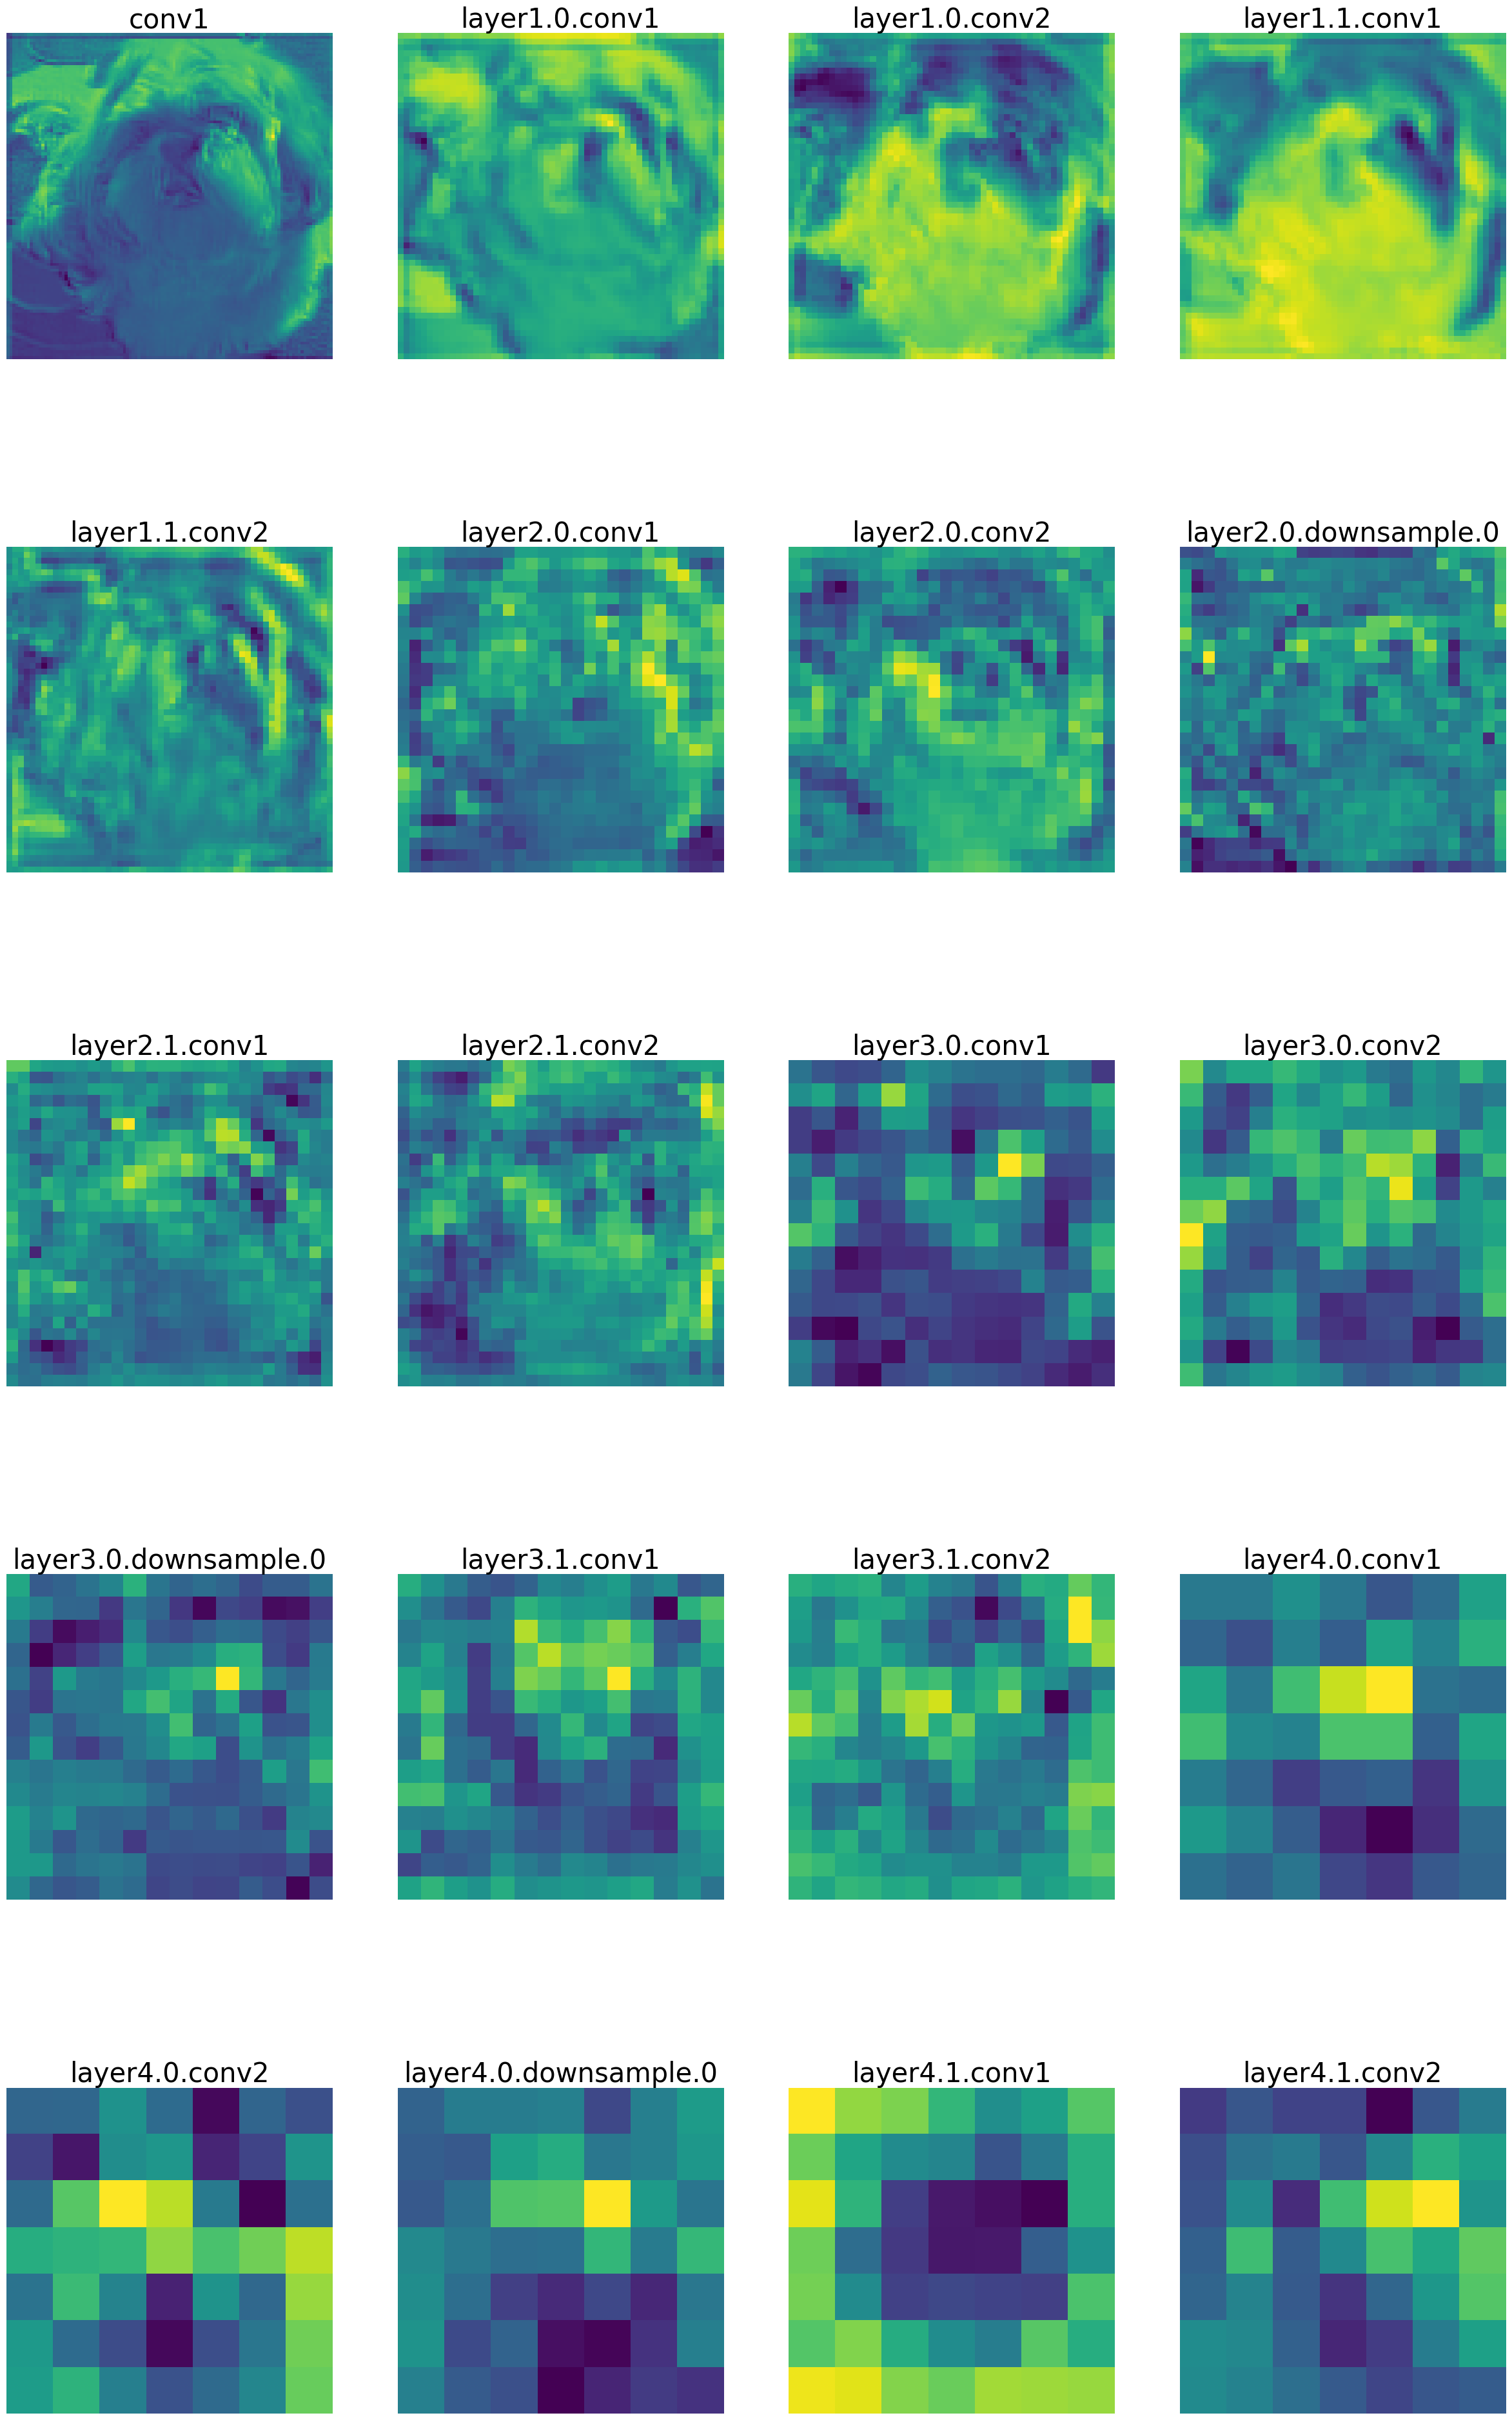

In [3]:
import matplotlib.pyplot as plt
import math

# size(0) gibt die Größe der Batch-Dimension zurück
batch_size = input_images.size(0) #[B,C,H,W]
print("Batch size:", batch_size)

# über alle Bilder im Batch iterieren
for img_idx in range(batch_size):
    # Liste um die bearbeiteten Feature Maps zu speichern
    processed_feature_maps = []
    # über alle Feature Maps iterieren
    for fm in feature_maps:
        # nur die Feature Map für das aktuelle Bild im Batch auswählen
        # mit squeeze(0) wird die Batch-Dimension entfernt, da nur ein Bild betrachtet wird
        # von [B, C, H, W] zu [C, H, W]
        feature_map = fm[img_idx].squeeze(0) 
        # torch.sum summiert über die Kanäle (Dimension 0 ist jetzt = Channels)
        # und dann wird durch die Anzahl der Kanäle geteilt --> Mittelwert
        # das ist nötig da wir eine 2D Darstellung wollen
        # danach haben wir eine [H, W] Matrix
        mean_feature_map = torch.sum(feature_map, 0) / feature_map.shape[0]  

        processed_feature_maps.append(mean_feature_map.data.cpu().numpy())

    #print ("\n Processed feature maps shape")
    #for fm in processed_feature_maps:
        #print(fm.shape)

    # Plot der feature maps
    fig = plt.figure(figsize=(30, 50))
    for i in range(len(processed_feature_maps)):
        ax = fig.add_subplot(5, 4, i + 1)
        ax.imshow(processed_feature_maps[i])
        ax.axis("off")
        ax.set_title(layer_names[i].split('(')[0], fontsize=30)
        
                

######## PLOTTING DER LRP LAYERS ########

In [5]:
# Pfad zum lrp_repo-Ordner ermitteln und zu sys.path hinzufügen

import pathlib
from pathlib import Path
import sys
# Path.cwd() gibt das aktuelle Arbeitsverzeichnis zurück
# .parent geht eine Ebene nach oben
PROJECT_ROOT = Path.cwd().resolve().parent 
print("PROJECT_ROOT:", PROJECT_ROOT) # PROJECT_ROOT: /home/zimame/ma-chaymaa-zimame
LRP_REPO_ROOT = PROJECT_ROOT / "lrp_repo"
sys.path.append(str(LRP_REPO_ROOT))

from models import OneWayResNet
from src.lrp import LRPModel
from data.dataset import ImageWoofDataset
from model.resnet18 import ResNet18

# Modell wird in OneWayResnet umgewandelt da die LRP-Klasse es so erwartet
lrp_model = OneWayResNet(model.model).to(device).eval()

# LRP Klasse initialisieren
lrp_wrapper = LRPModel(
    model=lrp_model,
    # rel_pass_ratio wird implizit == 0.0 gesetzt, d.h. die Relevanz wird nicht gefiltert, alles wird weitergegeben
    # flows_skip ist die beste Regel nach dem Paper (in lrp_repo/src/utils.py)
    skip_connection_prop="flows_skip"
).to(device)

# DataLoader für den Validierungsdatensatz erstellen, mit BS==8
val_loader = torch.utils.data.DataLoader(val_dataset_7, batch_size=8, shuffle=False)

# nur der erste Batch wird geladen (8 Bilder)
for images, labels in val_loader:
    break 

# Bilder ins Gerät verschieben
# with torch.no_grad() um den Speicherverbrauch zu reduzieren
with torch.no_grad():
    input_images = images.to(device)

# --- LRP ---
# ich rufe forward_per_layer aus lrp_repo/src/lrp.py
# mit topk=1 auf, damit nur die höchste Klasse pro Bild berücksichtigt wird
# relevances ist eine Liste von Relevance Maps pro Layer
# names ist eine Liste von Layer-Namen pro Layer
relevances, names = lrp_wrapper.forward_per_layer(input_images, topk=1)

print("Batch size:", input_images.shape[0])
print("Anzahl Layer:", len(relevances))
#print("Names der Layer:", names)
#print("Relevance map shape pro Layer:")
#for rel in relevances:
#   print(rel.shape)

PROJECT_ROOT: /home/zimame/ma-chaymaa-zimame
Batch size: 8
Anzahl Layer: 142


In [7]:
from methods.mapping_param_lrp import PARAMLAYER_TO_RELLAYER_AND_LAYERTYPE

# alle Relevance-Layer-Namen, die wirklich benutzt werden (für lrp generell und auch für plotting hier)
used_relevance_layers = {
    rel_name
    for (rel_name, _) in PARAMLAYER_TO_RELLAYER_AND_LAYERTYPE.values()
}

# ich printe in txt-Datei alle Relenance Layers mit zugehöriger shape
with open("relevance_shapes.txt", "w") as f:
    for name, rel in zip(names, relevances):
        if name not in used_relevance_layers:
            continue
        f.write(f"Layer: {name}, Shape: {rel.shape}\n")

Batch size: 8


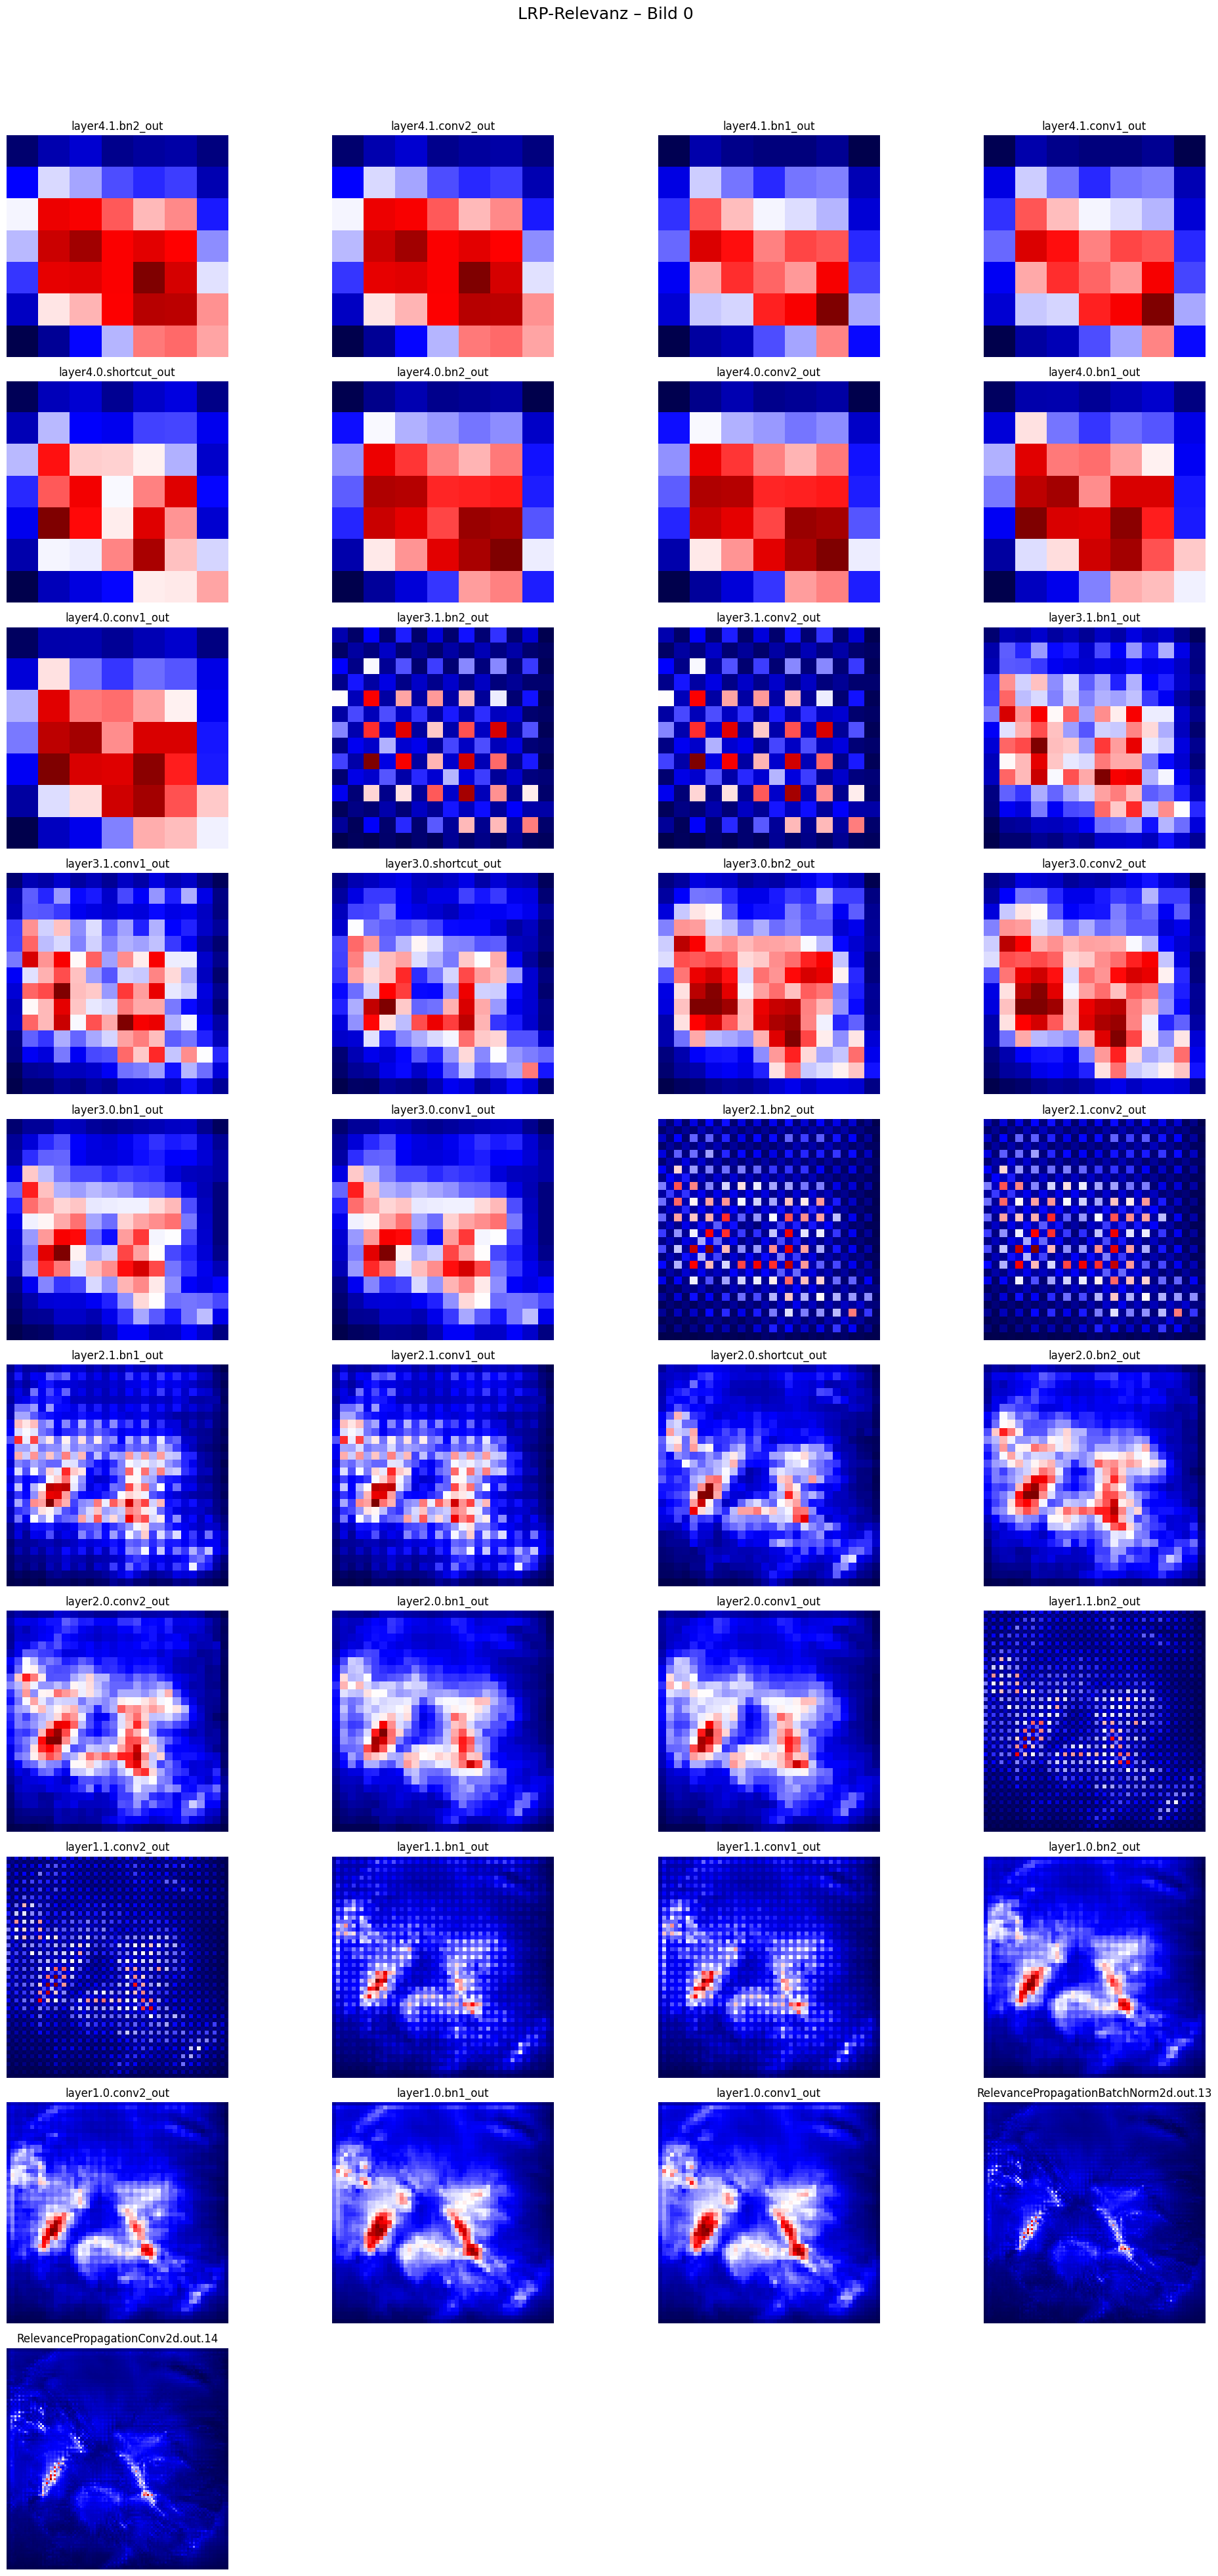

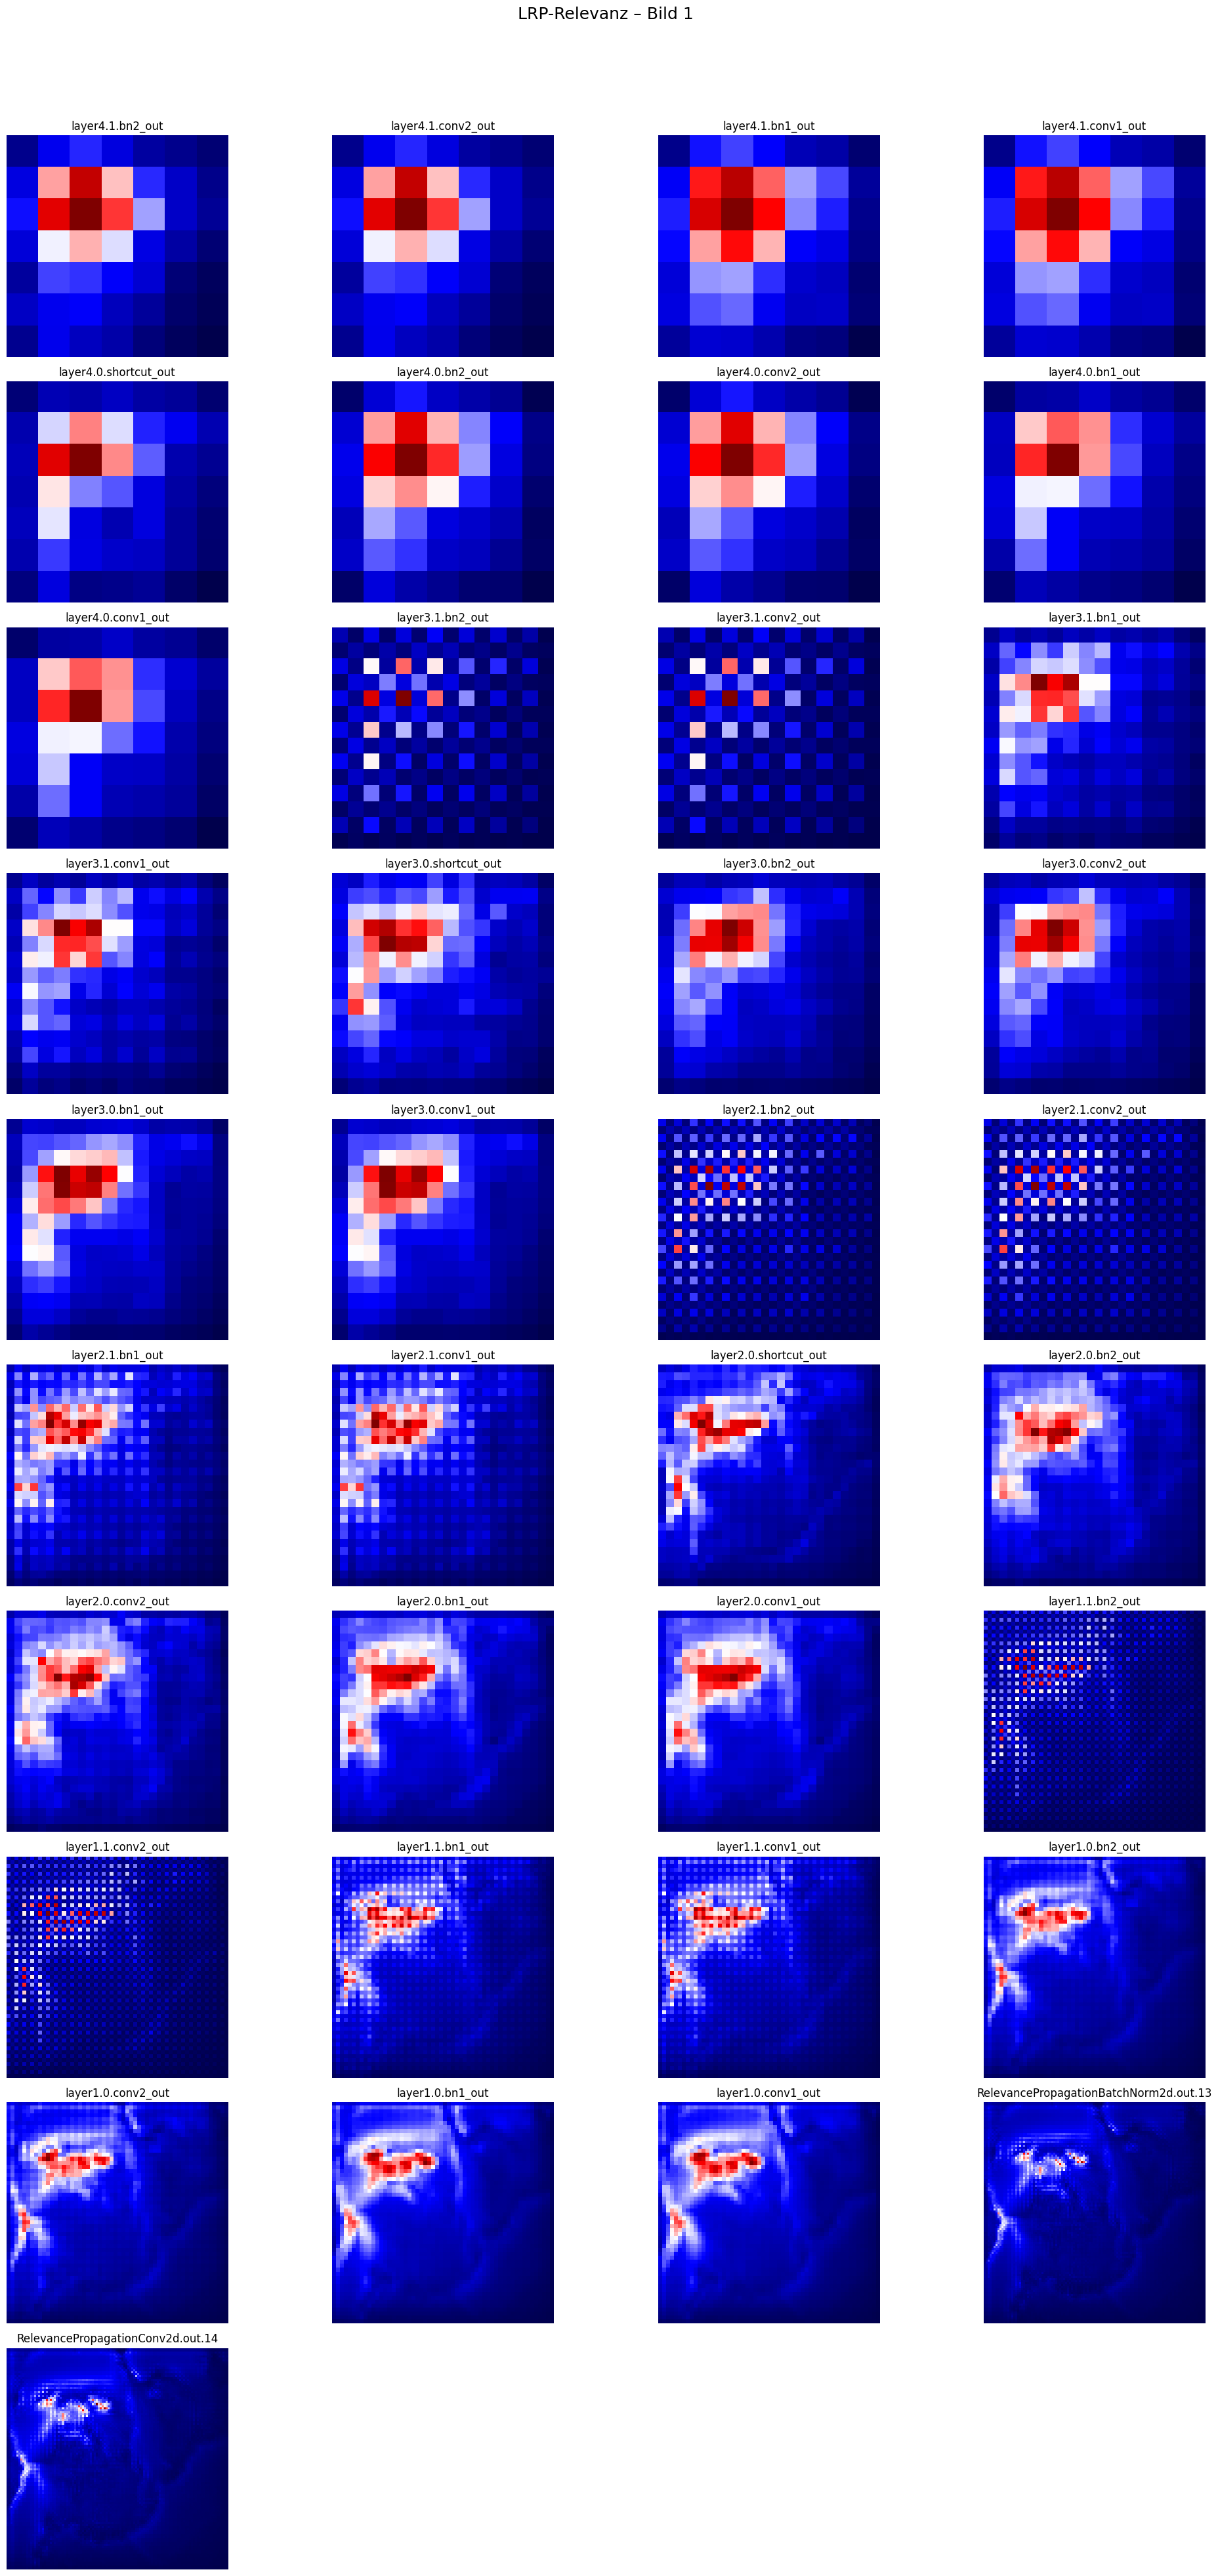

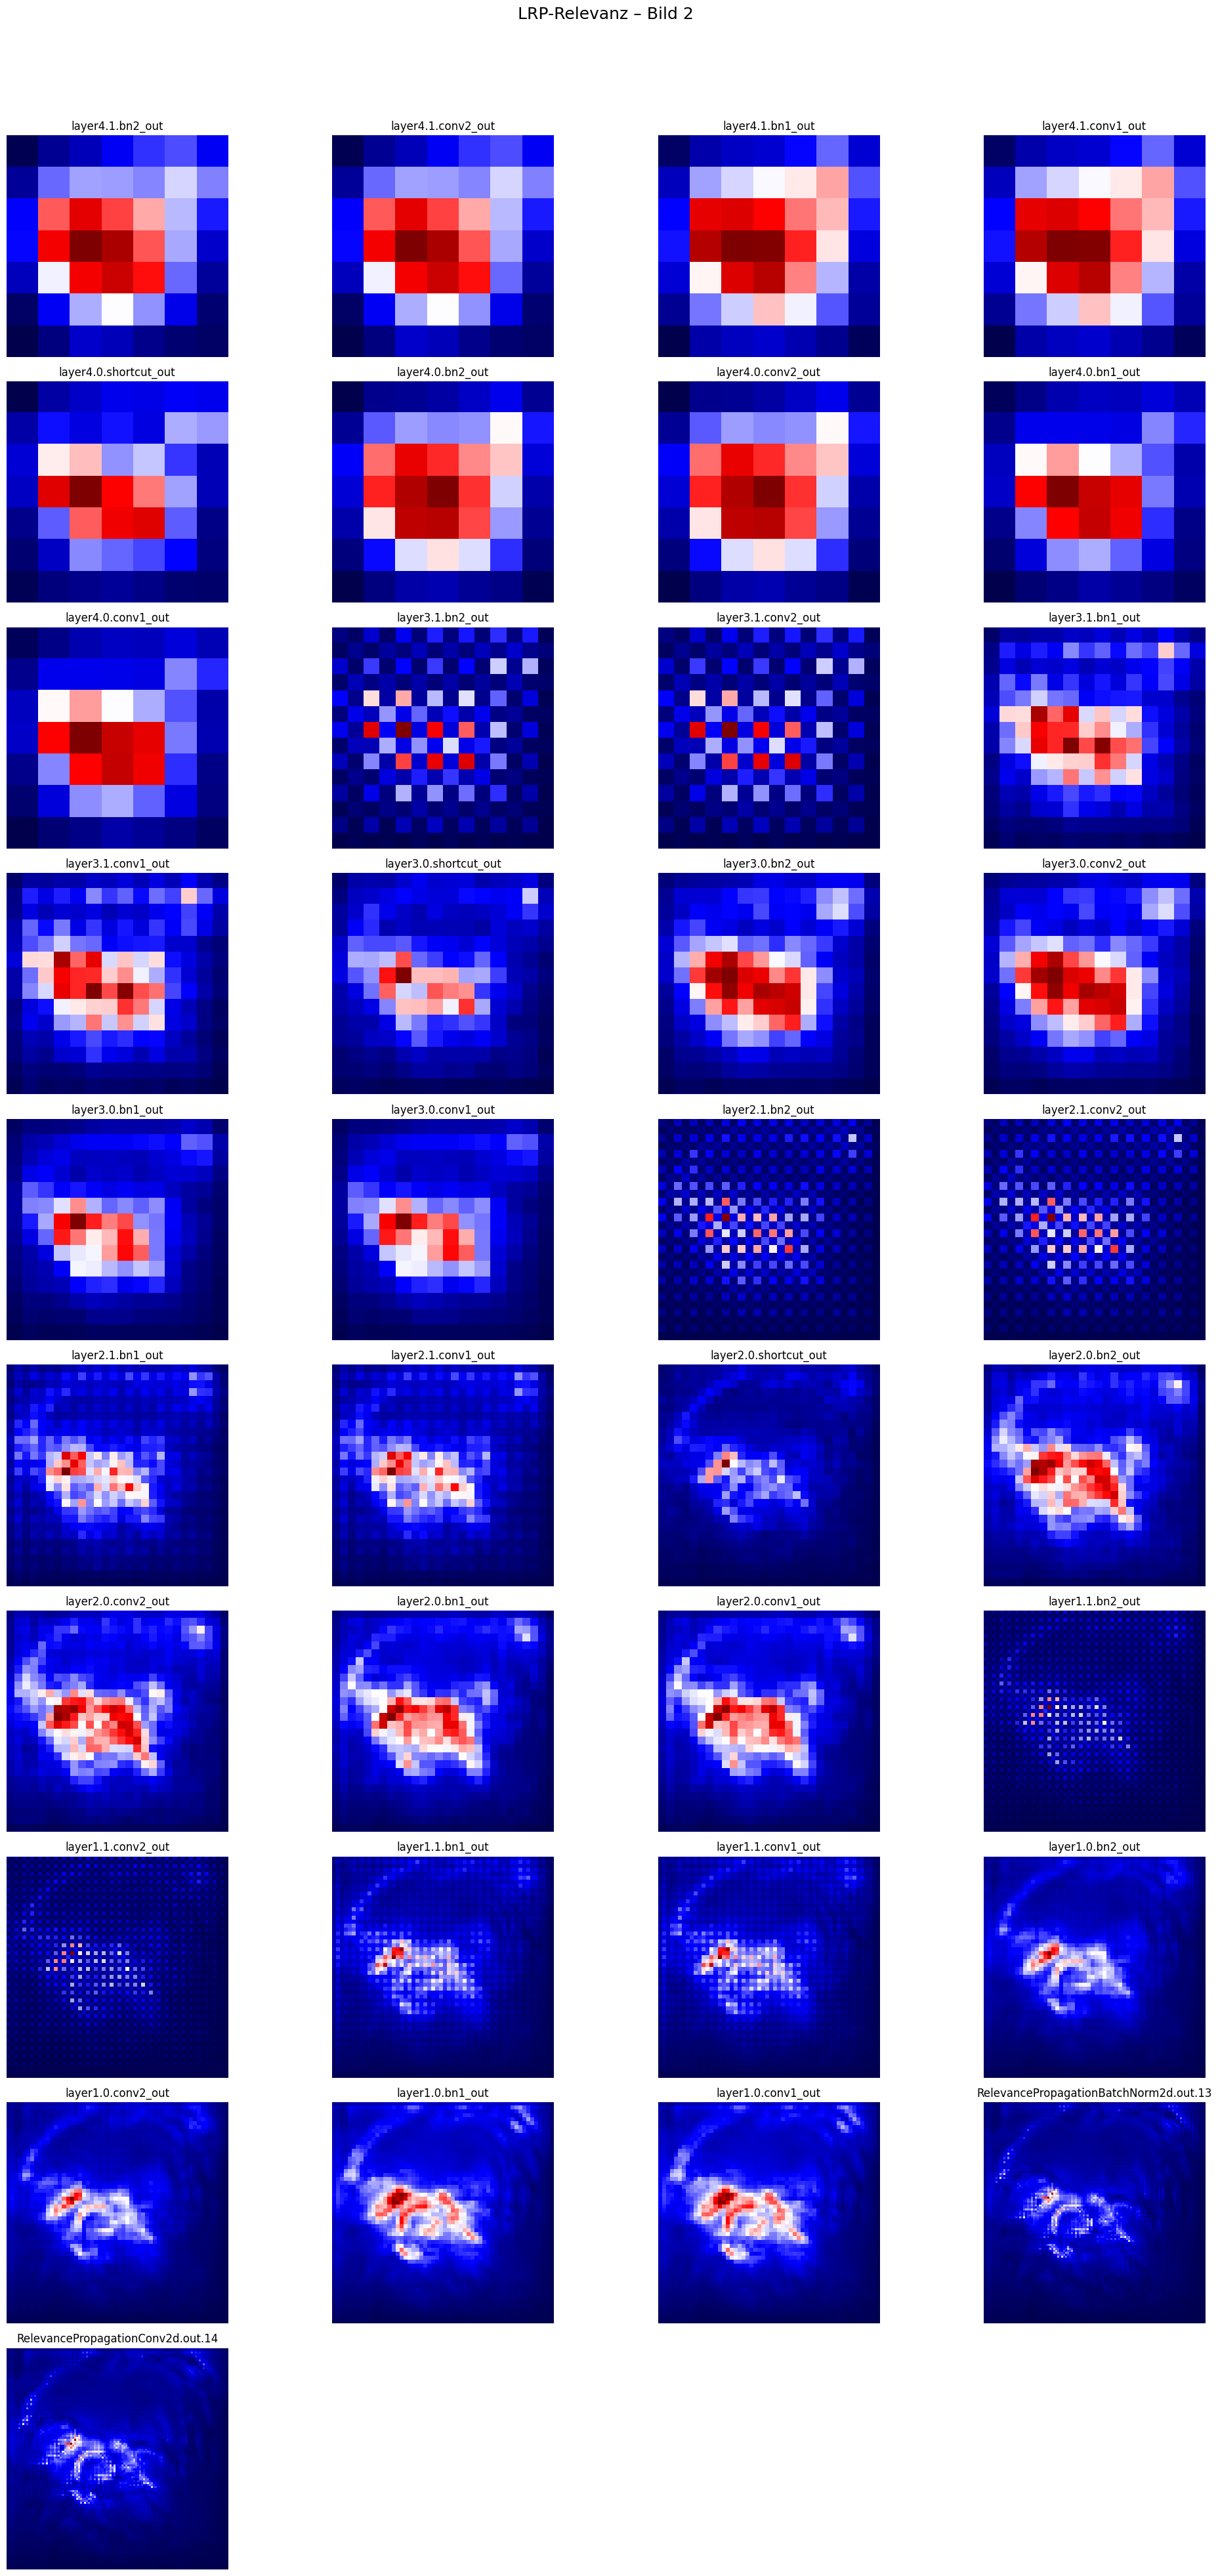

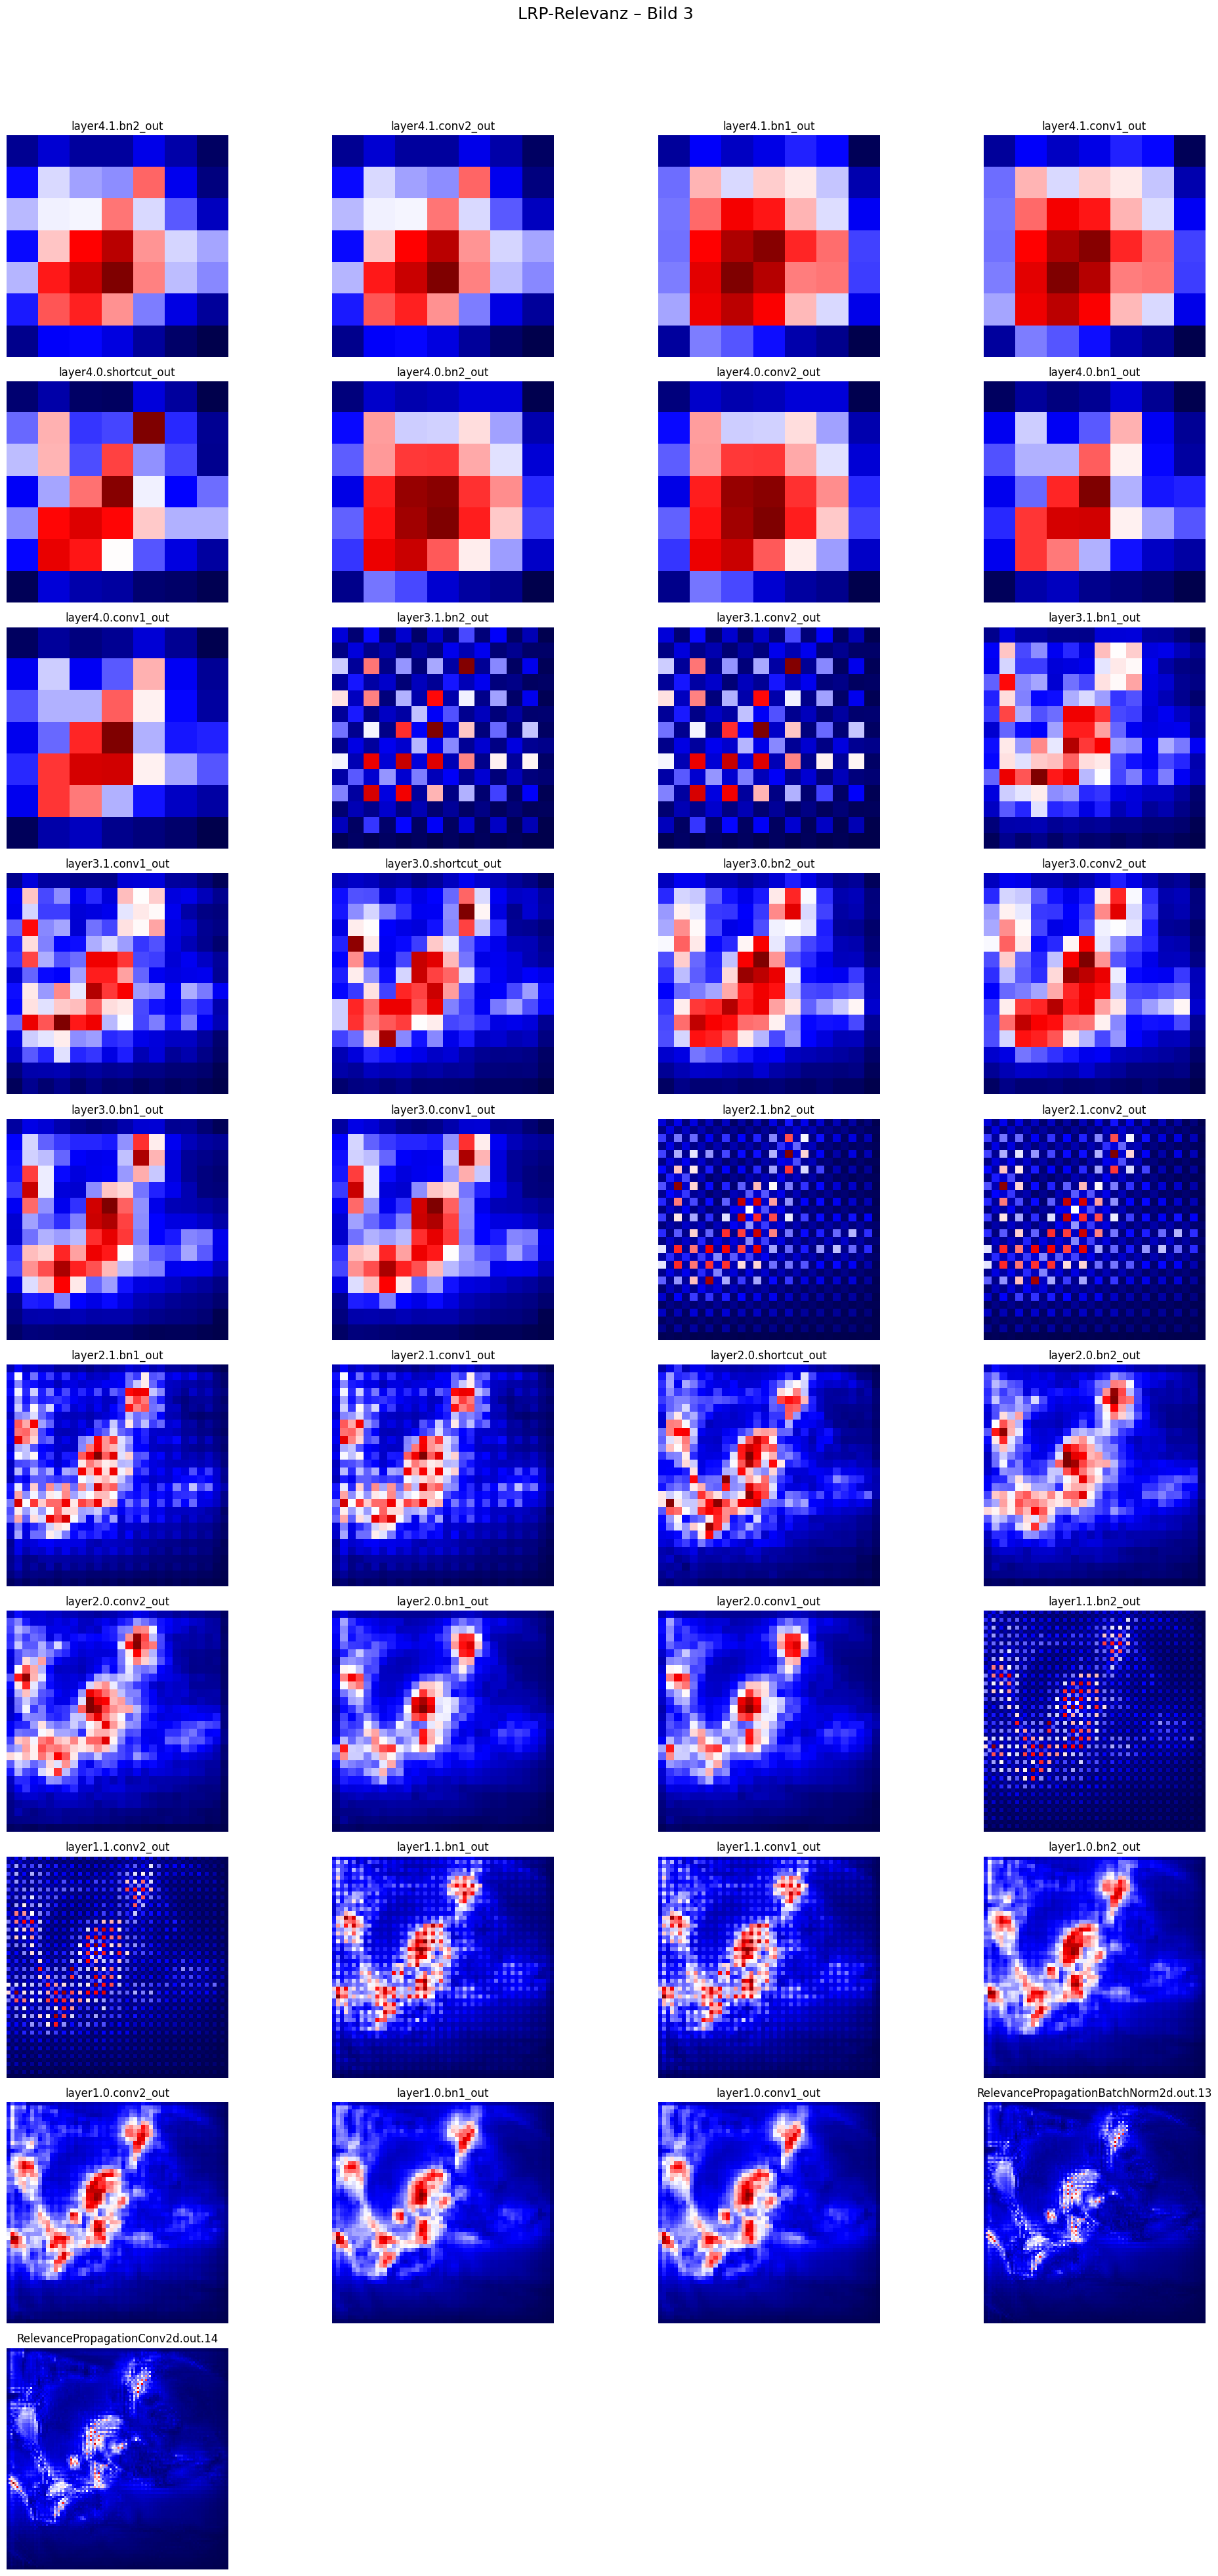

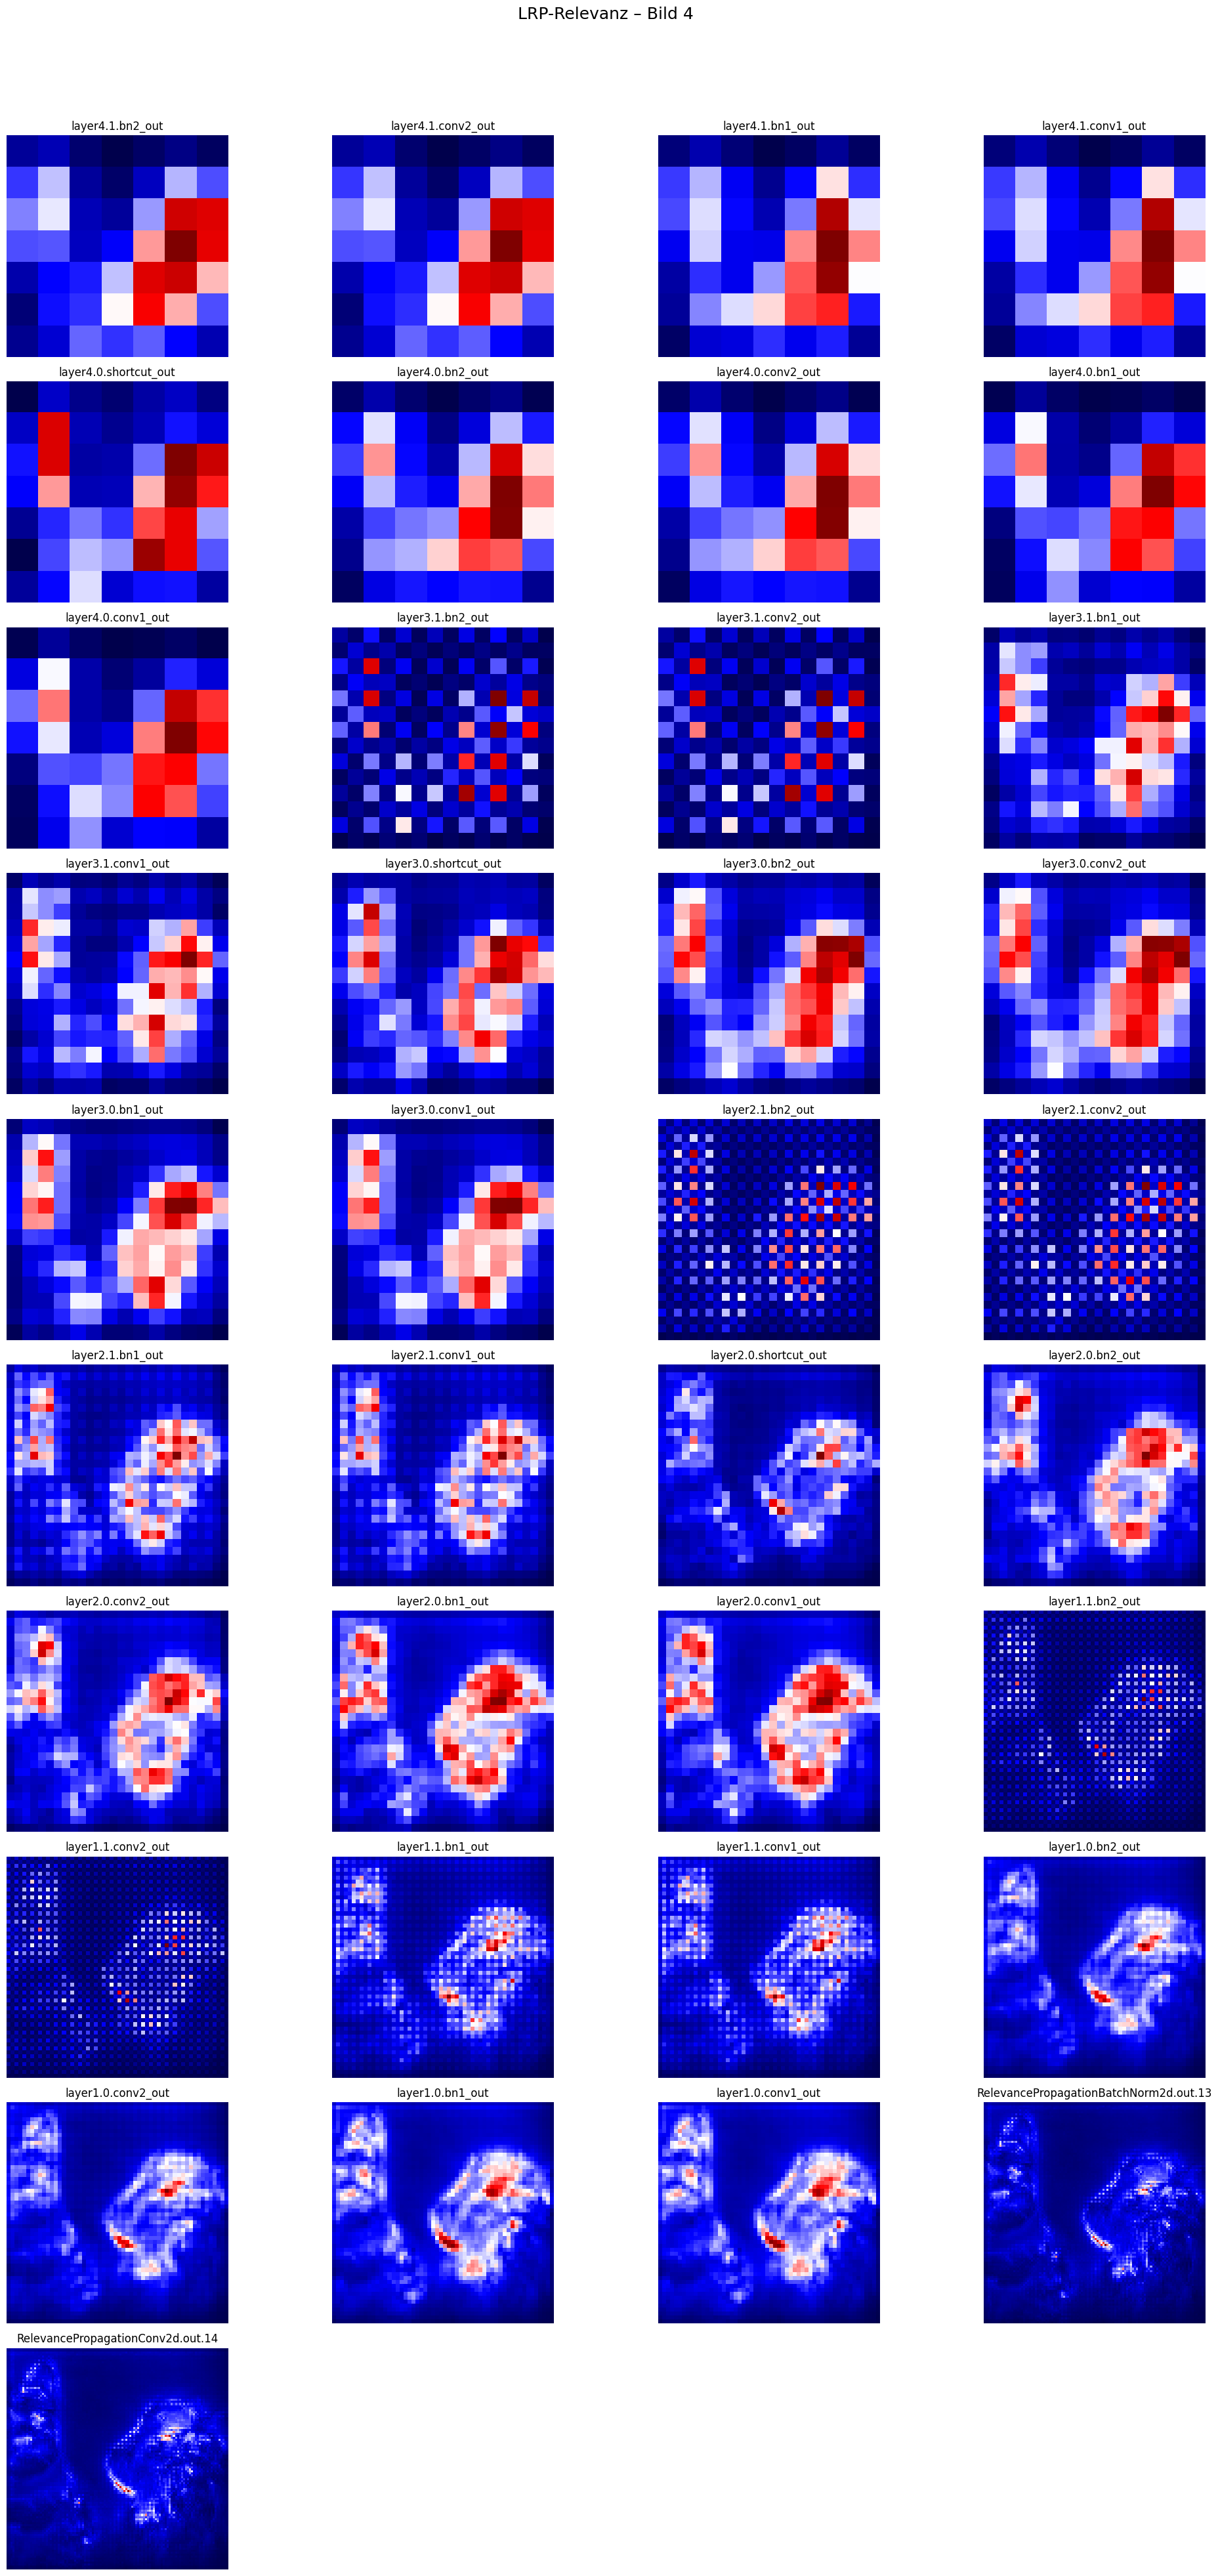

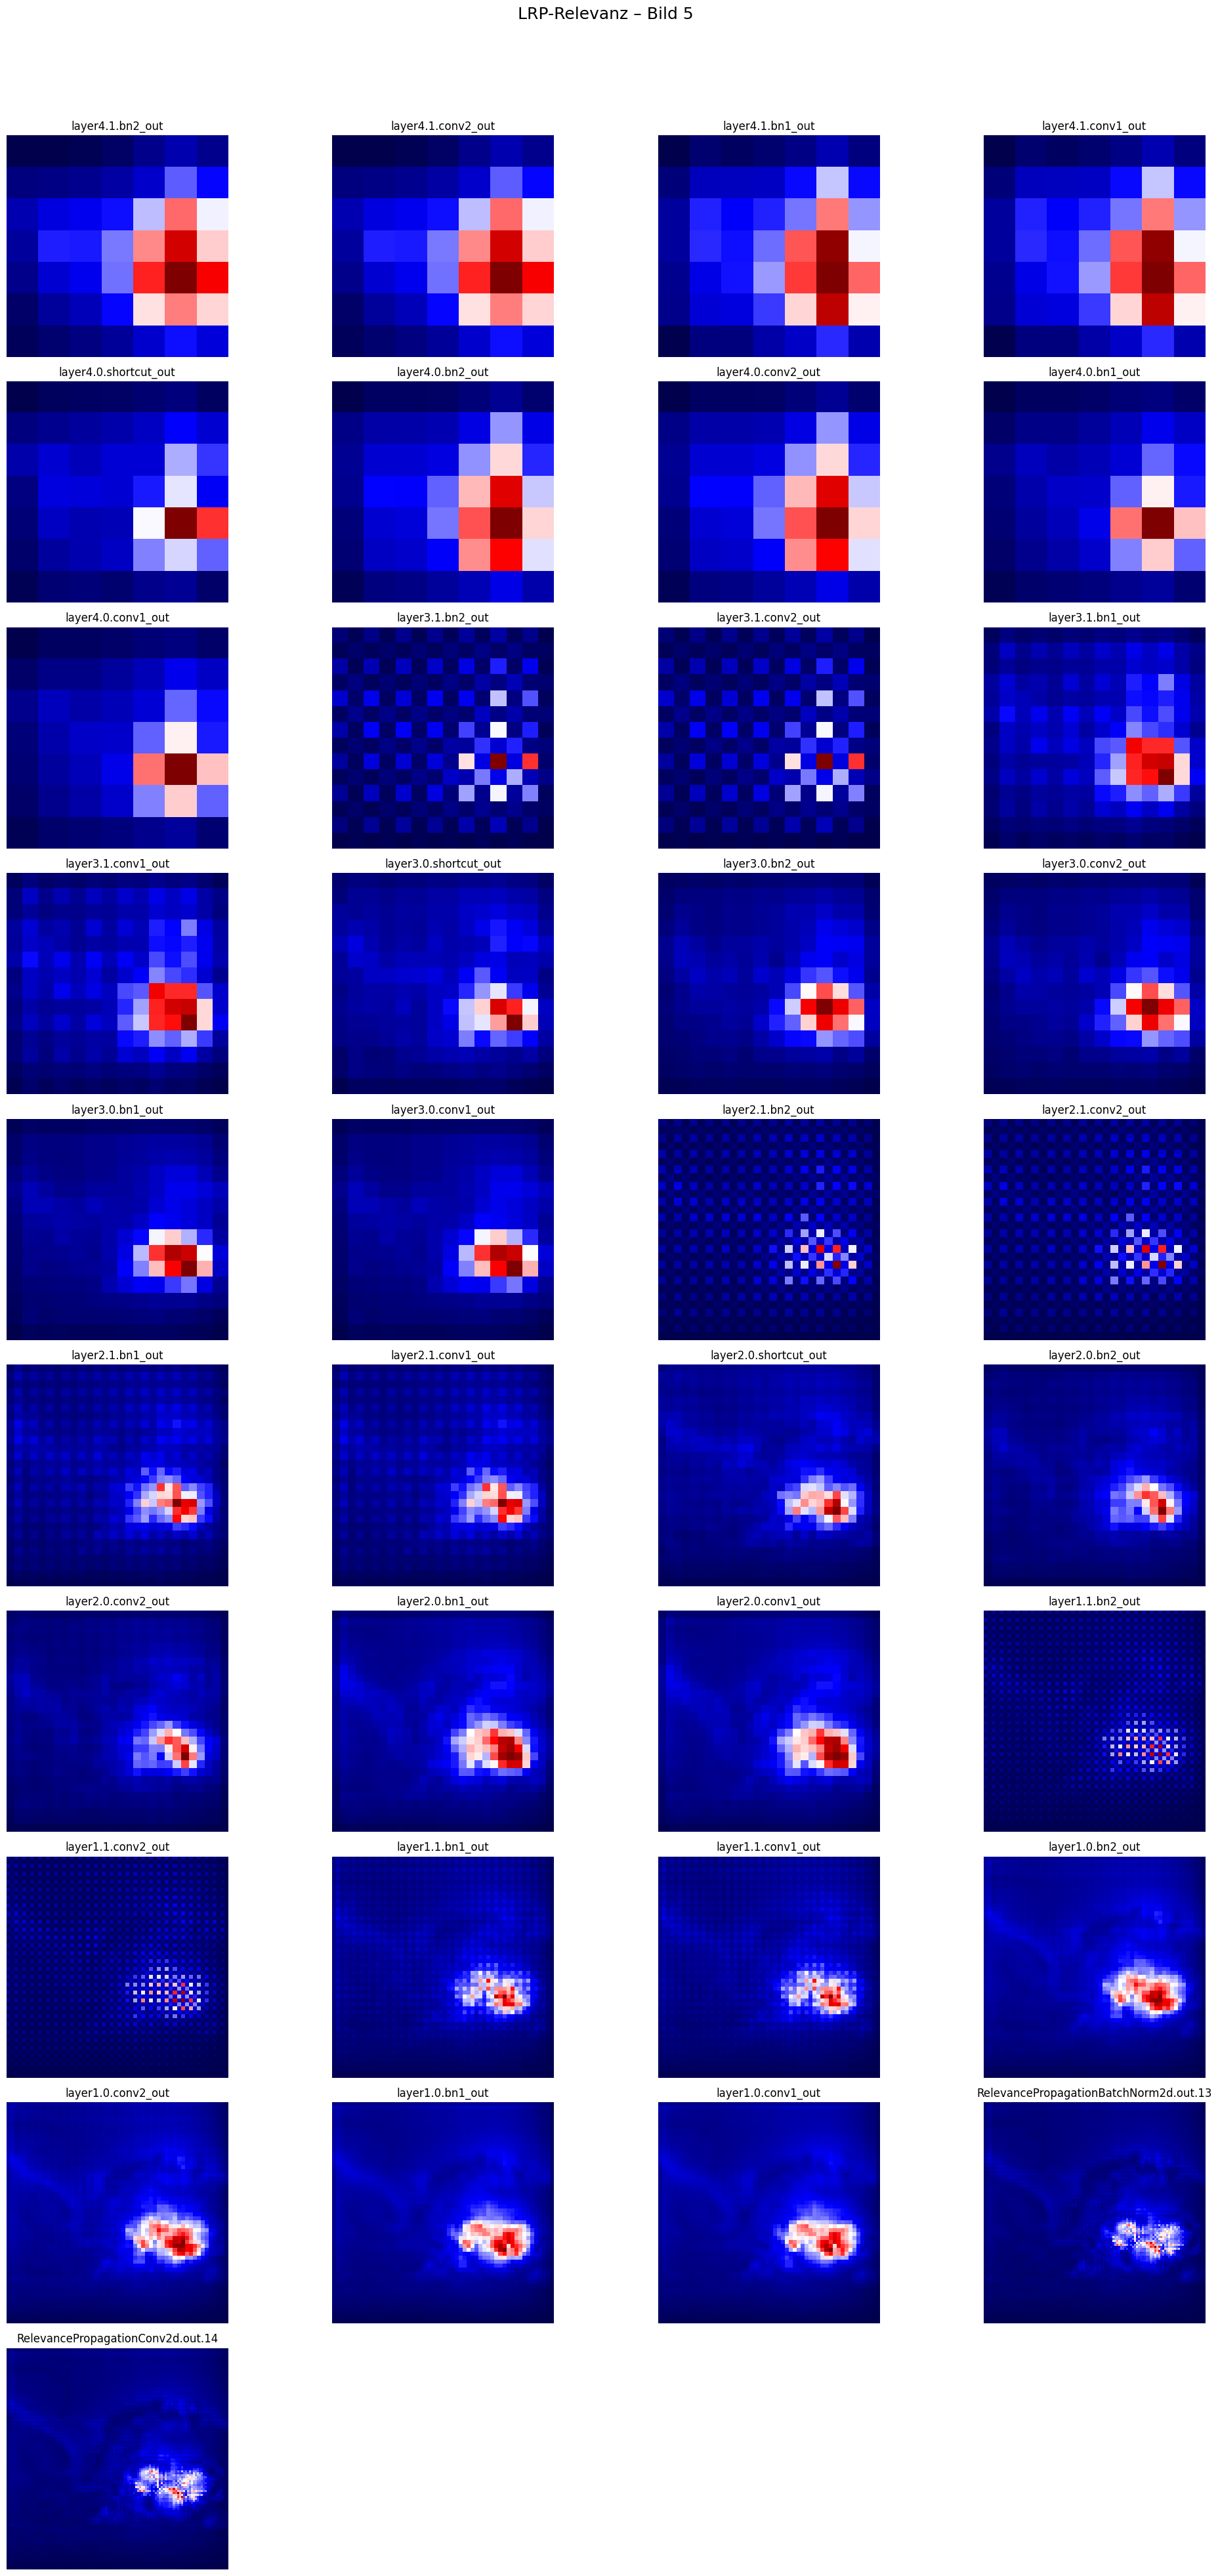

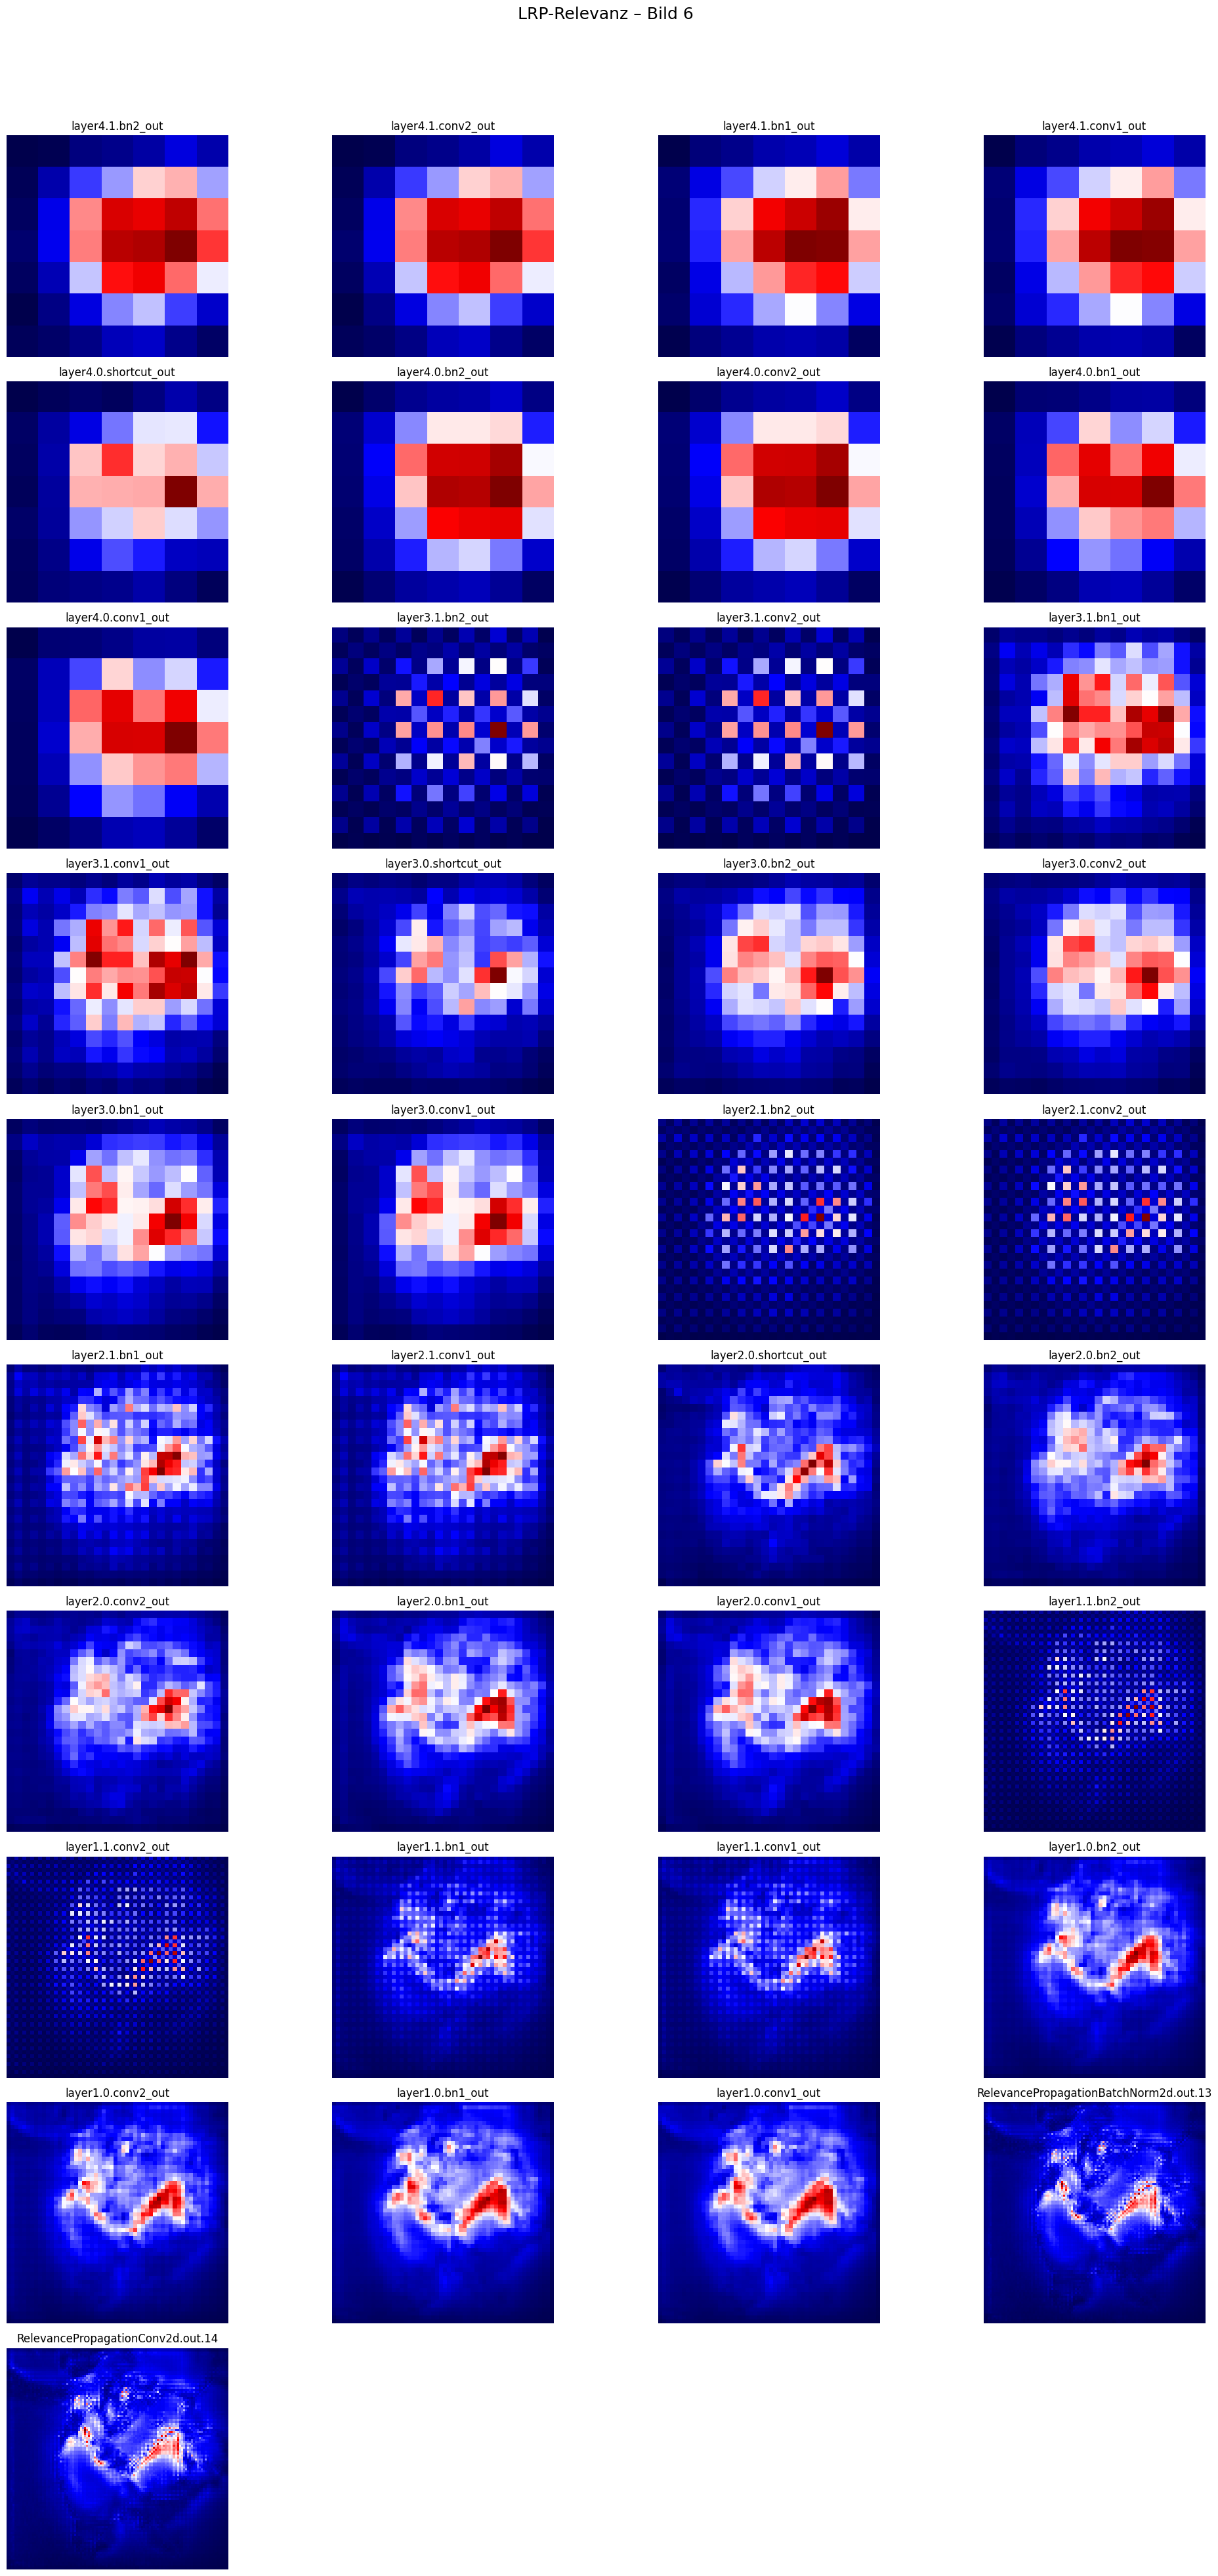

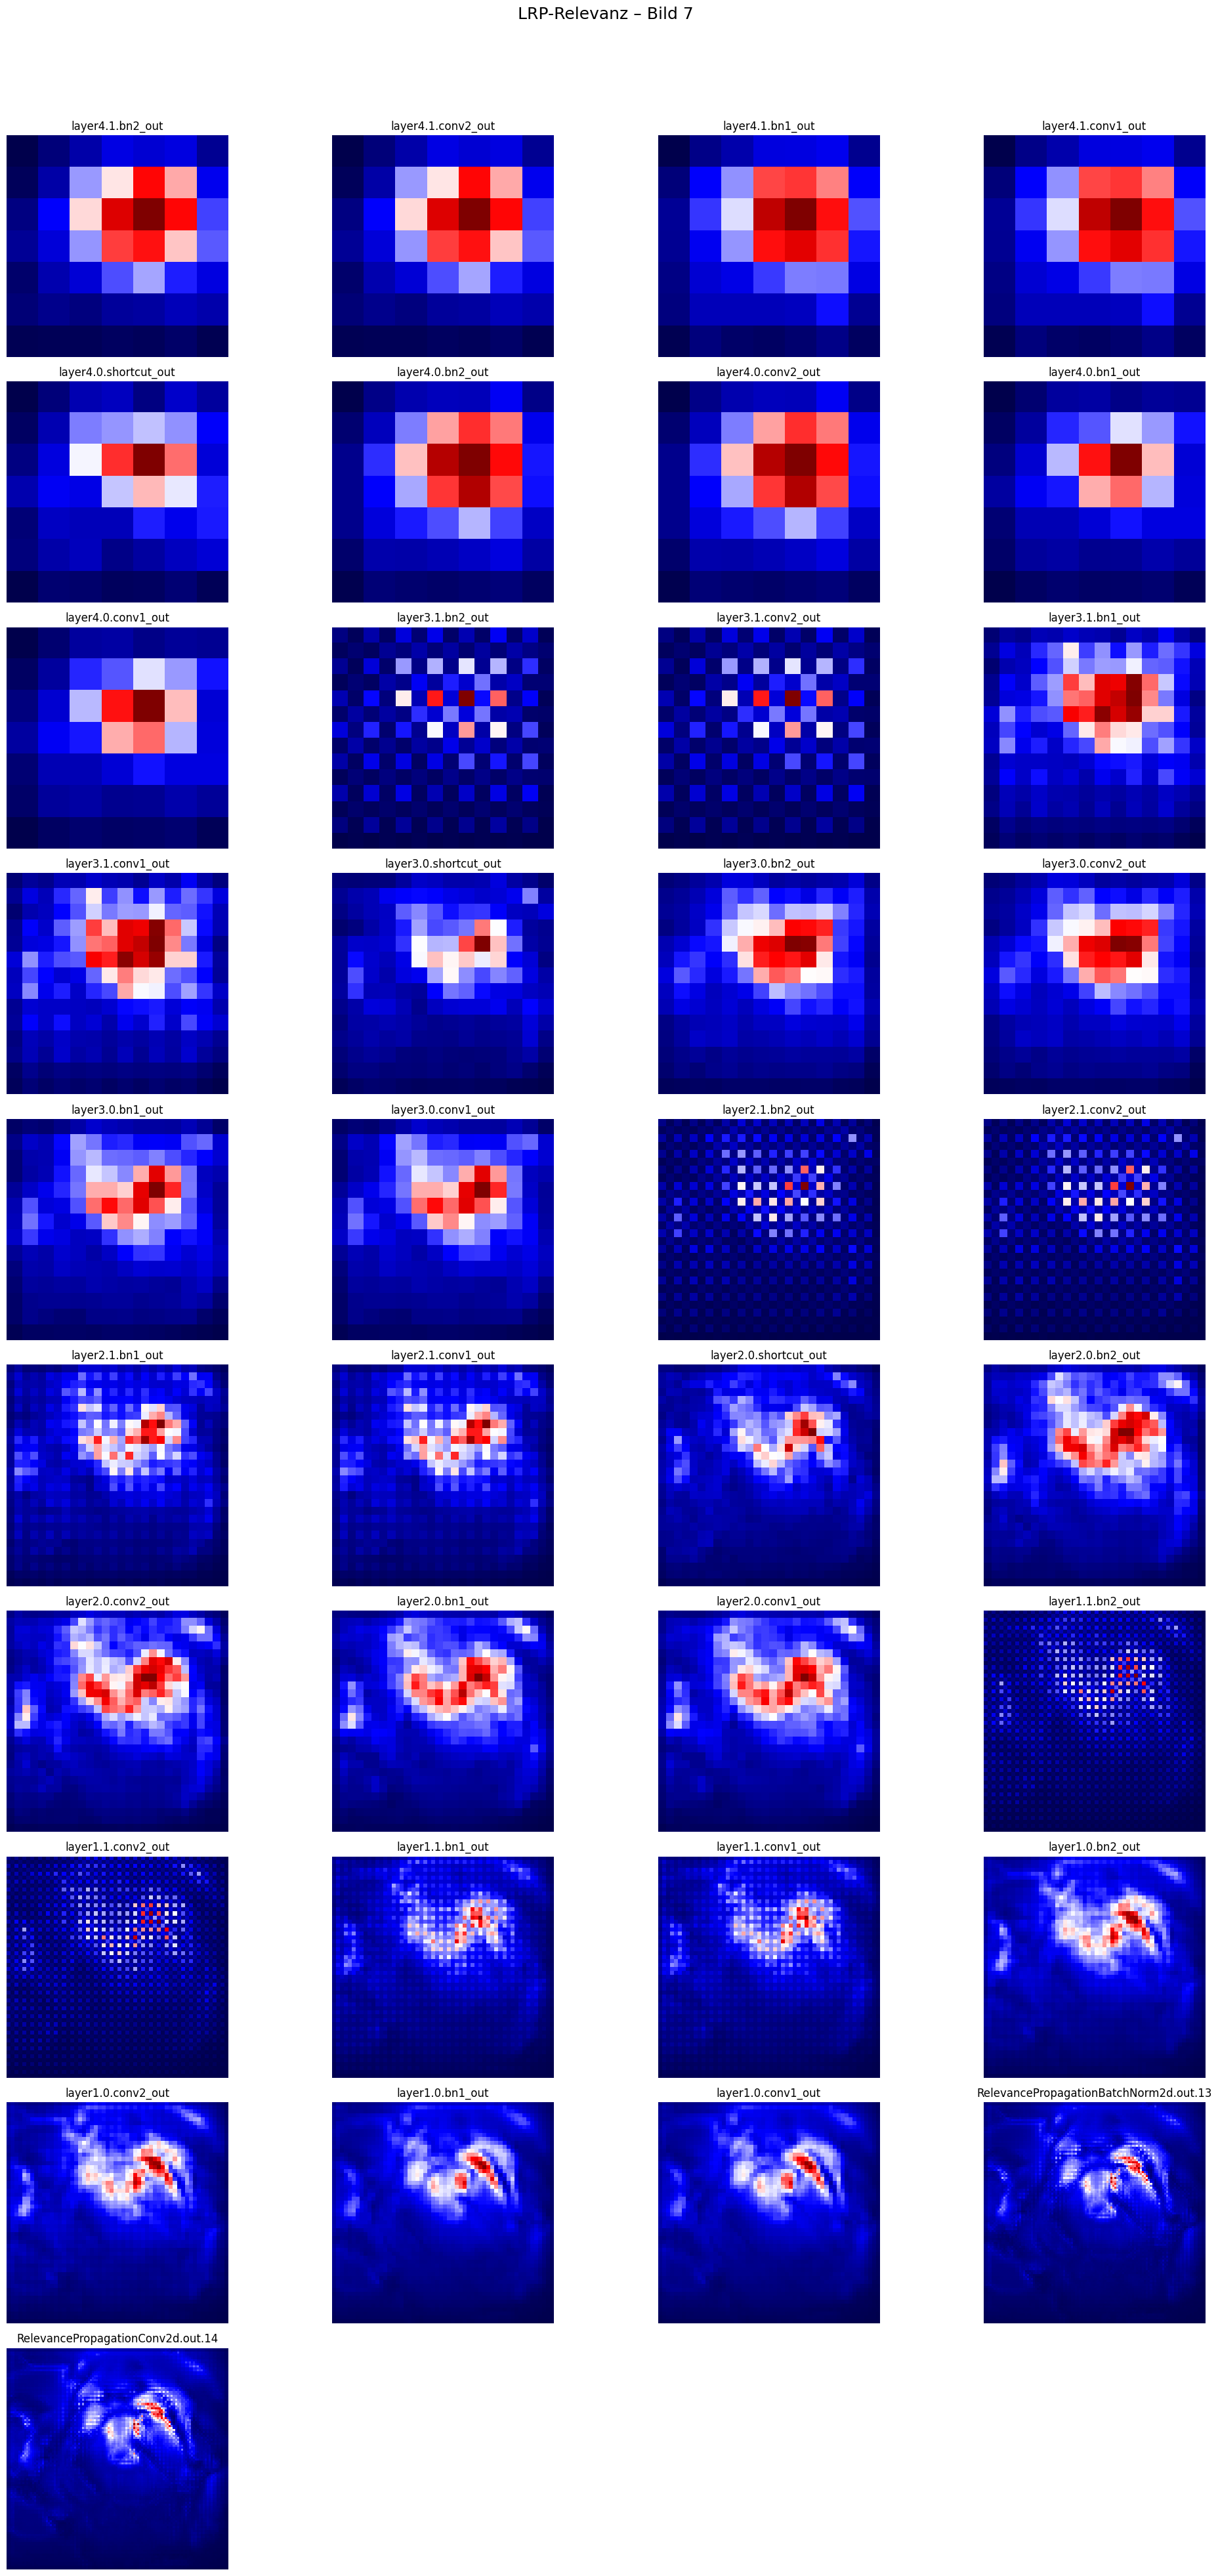

In [8]:
import matplotlib.pyplot as plt
import math

batch_size = input_images.size(0)
print("Batch size:", batch_size)

cols = 4

for img_idx in range(batch_size):

    processed_relevance_maps = []
    processed_names = []

    # zip kombiniert die zwei Liste, damit ich darüber iterieren kann
    for relevance, name in zip(relevances, names):
        # es werden nur Layers geplottet, die im mapping sind
        if name not in used_relevance_layers:
            continue

        relevance_map = relevance.detach()[img_idx]

        if relevance_map.dim() == 3:  # [C,H,W]
            mean_map = relevance_map.sum(0) / relevance_map.shape[0]
        else:
            continue

        processed_relevance_maps.append(mean_map.cpu().numpy())
        processed_names.append(name)

    # Plotting
    L = len(processed_relevance_maps)
    if L == 0:
        continue

    rows = math.ceil(L / cols)
    fig = plt.figure(figsize=(5 * cols, 4 * rows))

    for i in range(L):
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(processed_relevance_maps[i], cmap="seismic")
        ax.axis("off")
        ax.set_title(processed_names[i], fontsize=12)

    fig.suptitle(f"LRP-Relevanz – Bild {img_idx}", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Batch size: 8


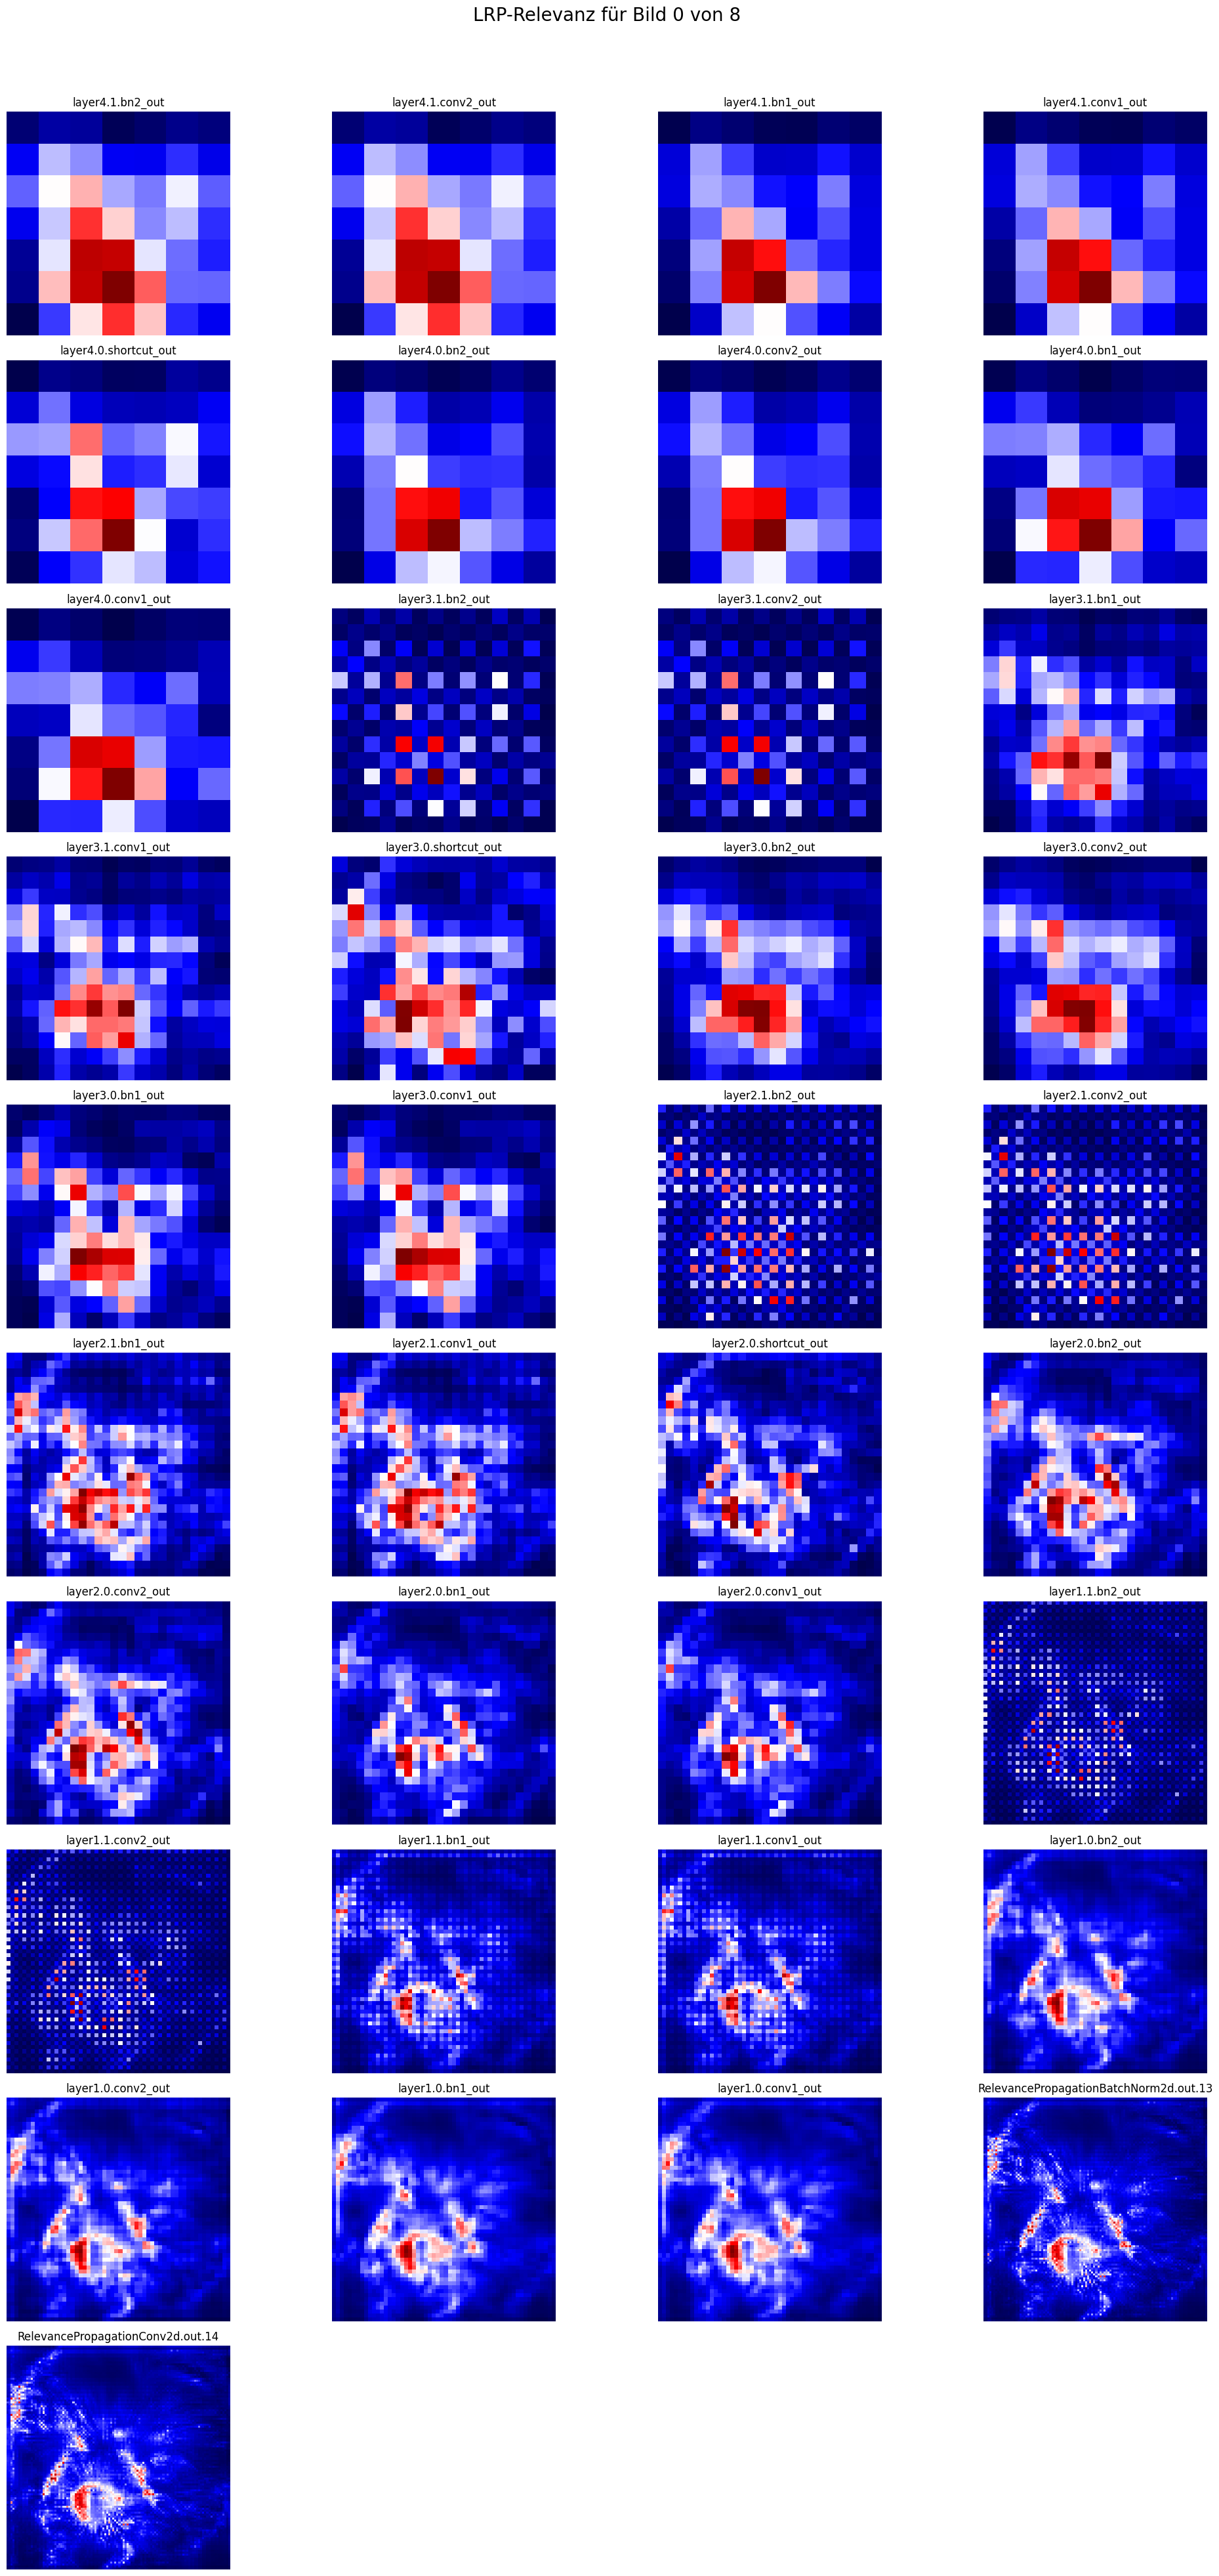

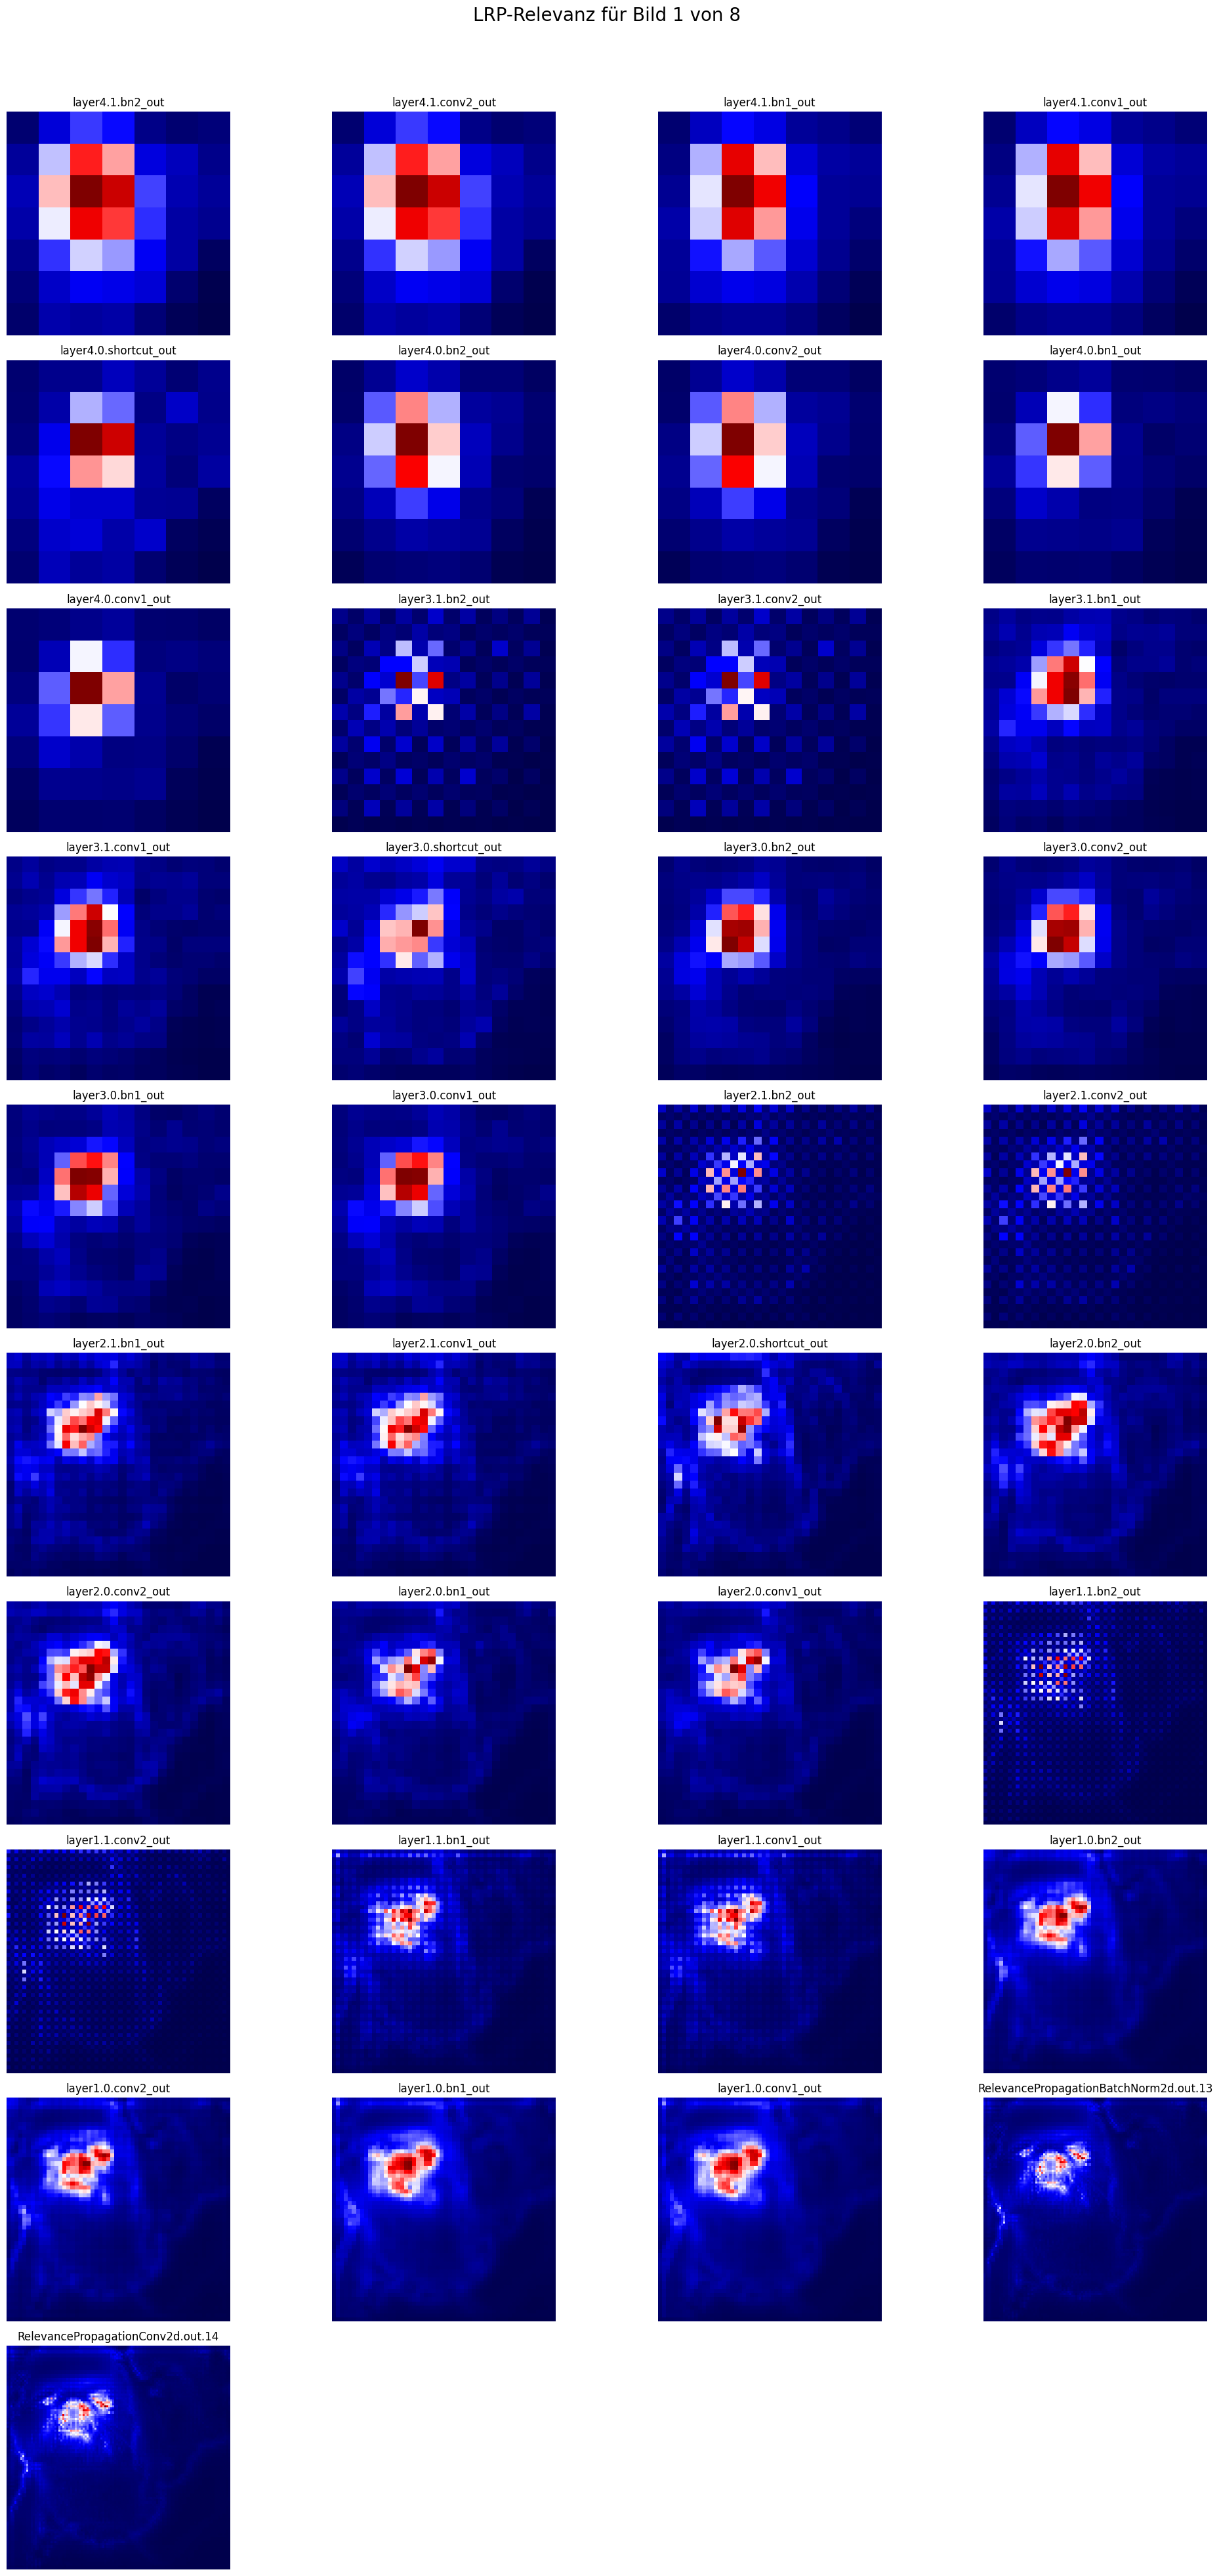

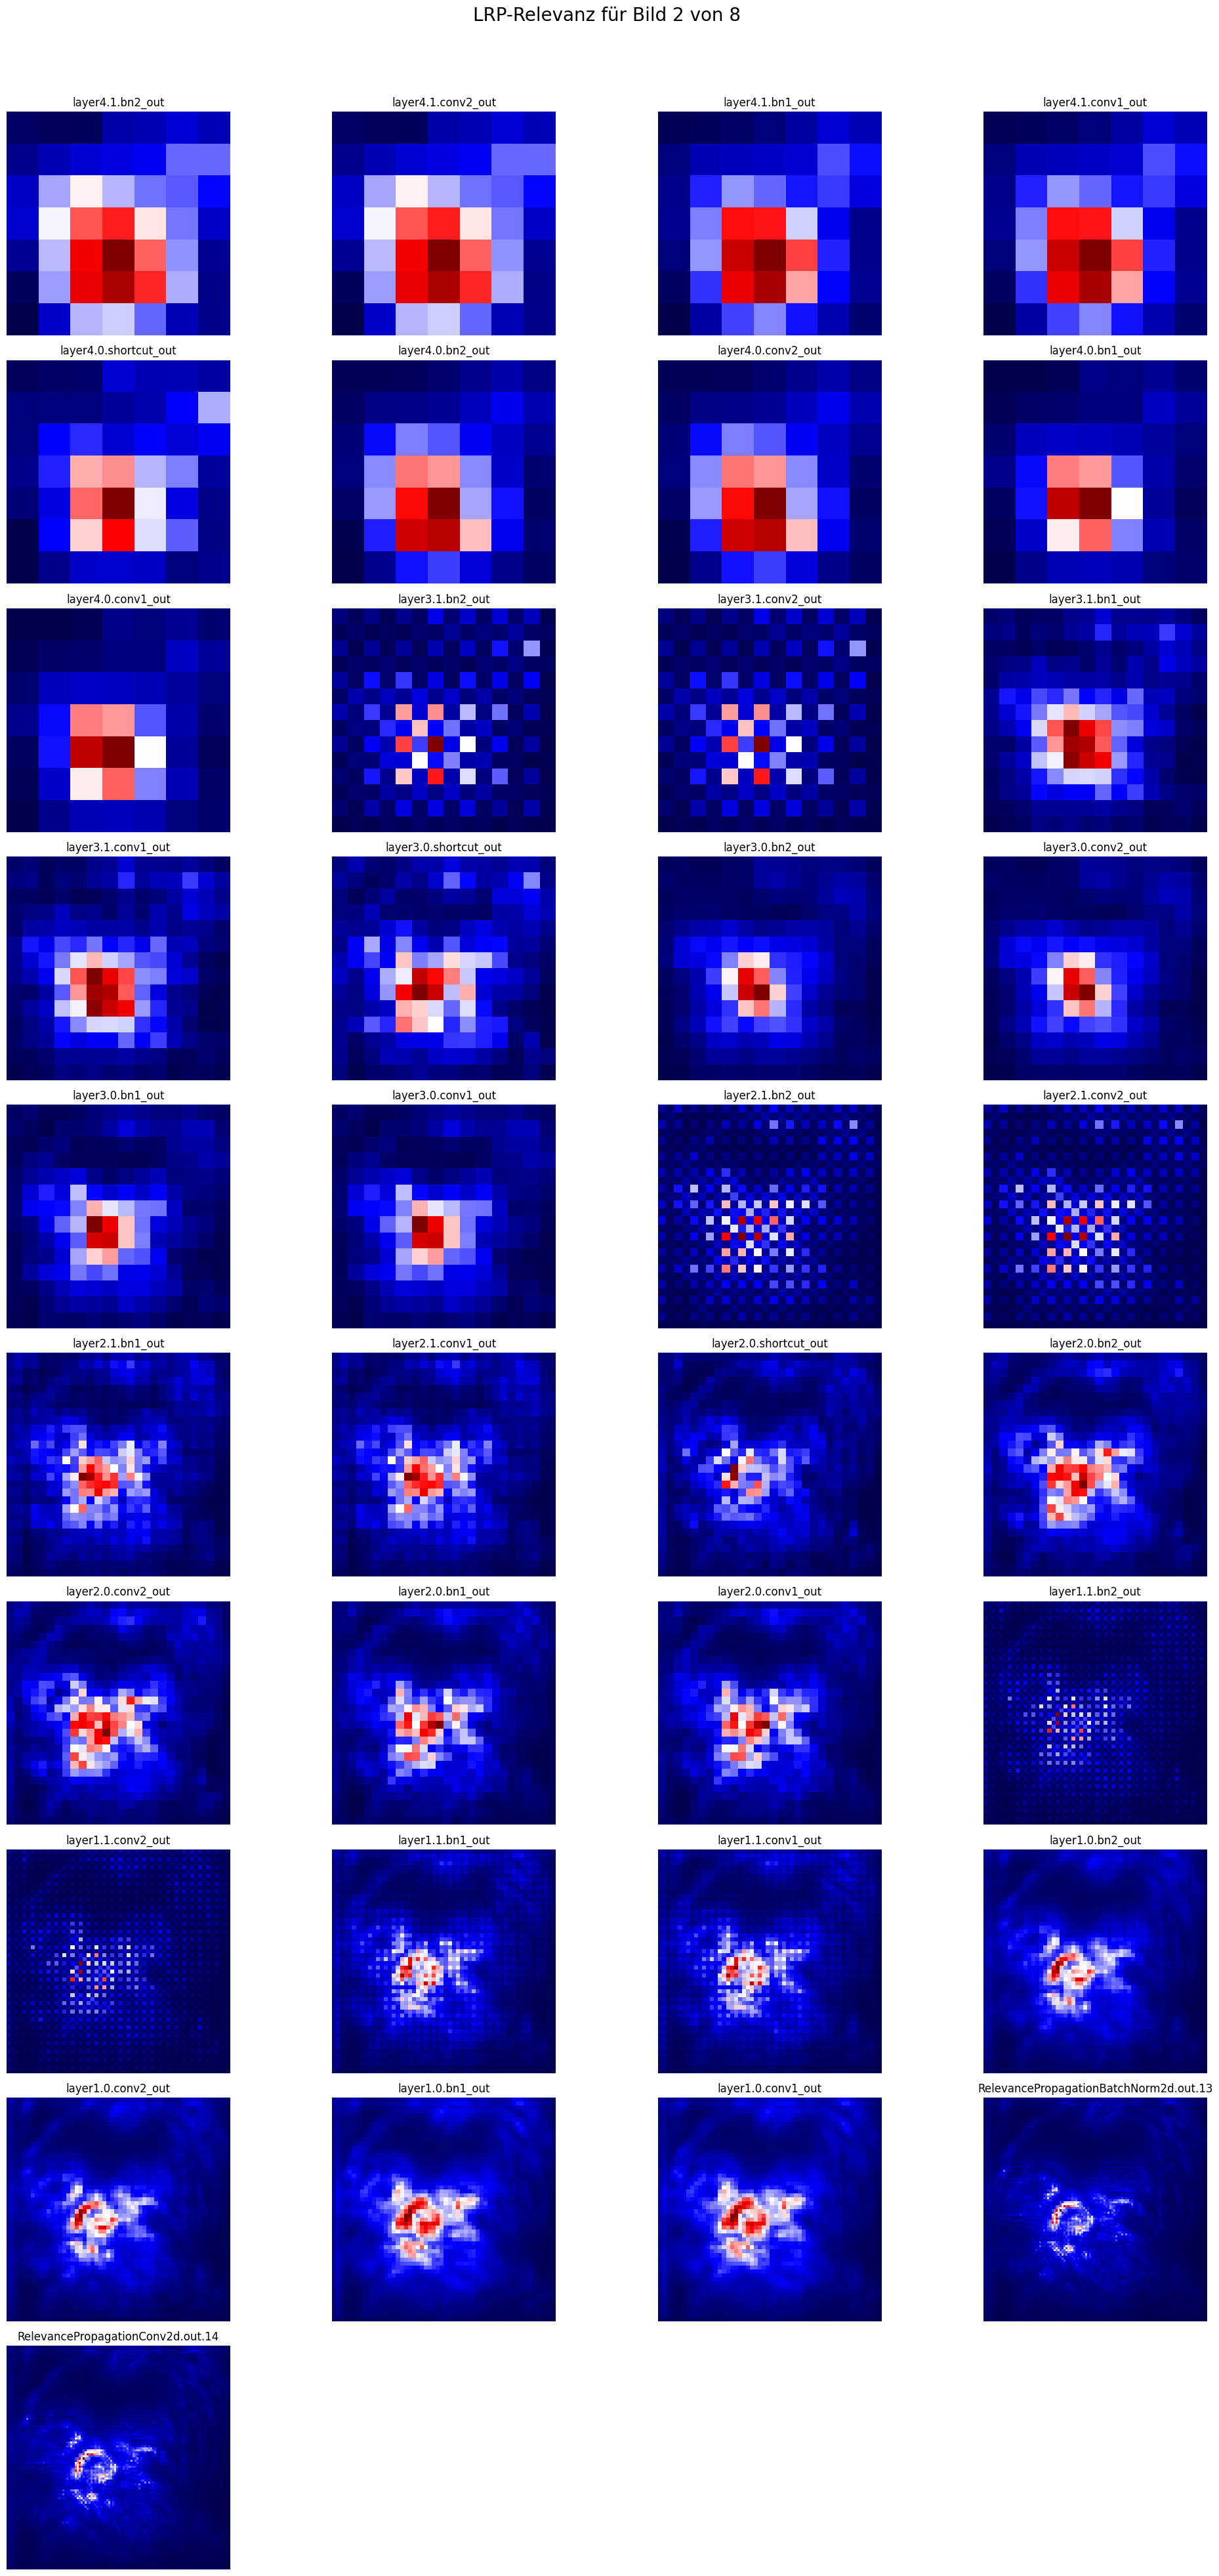

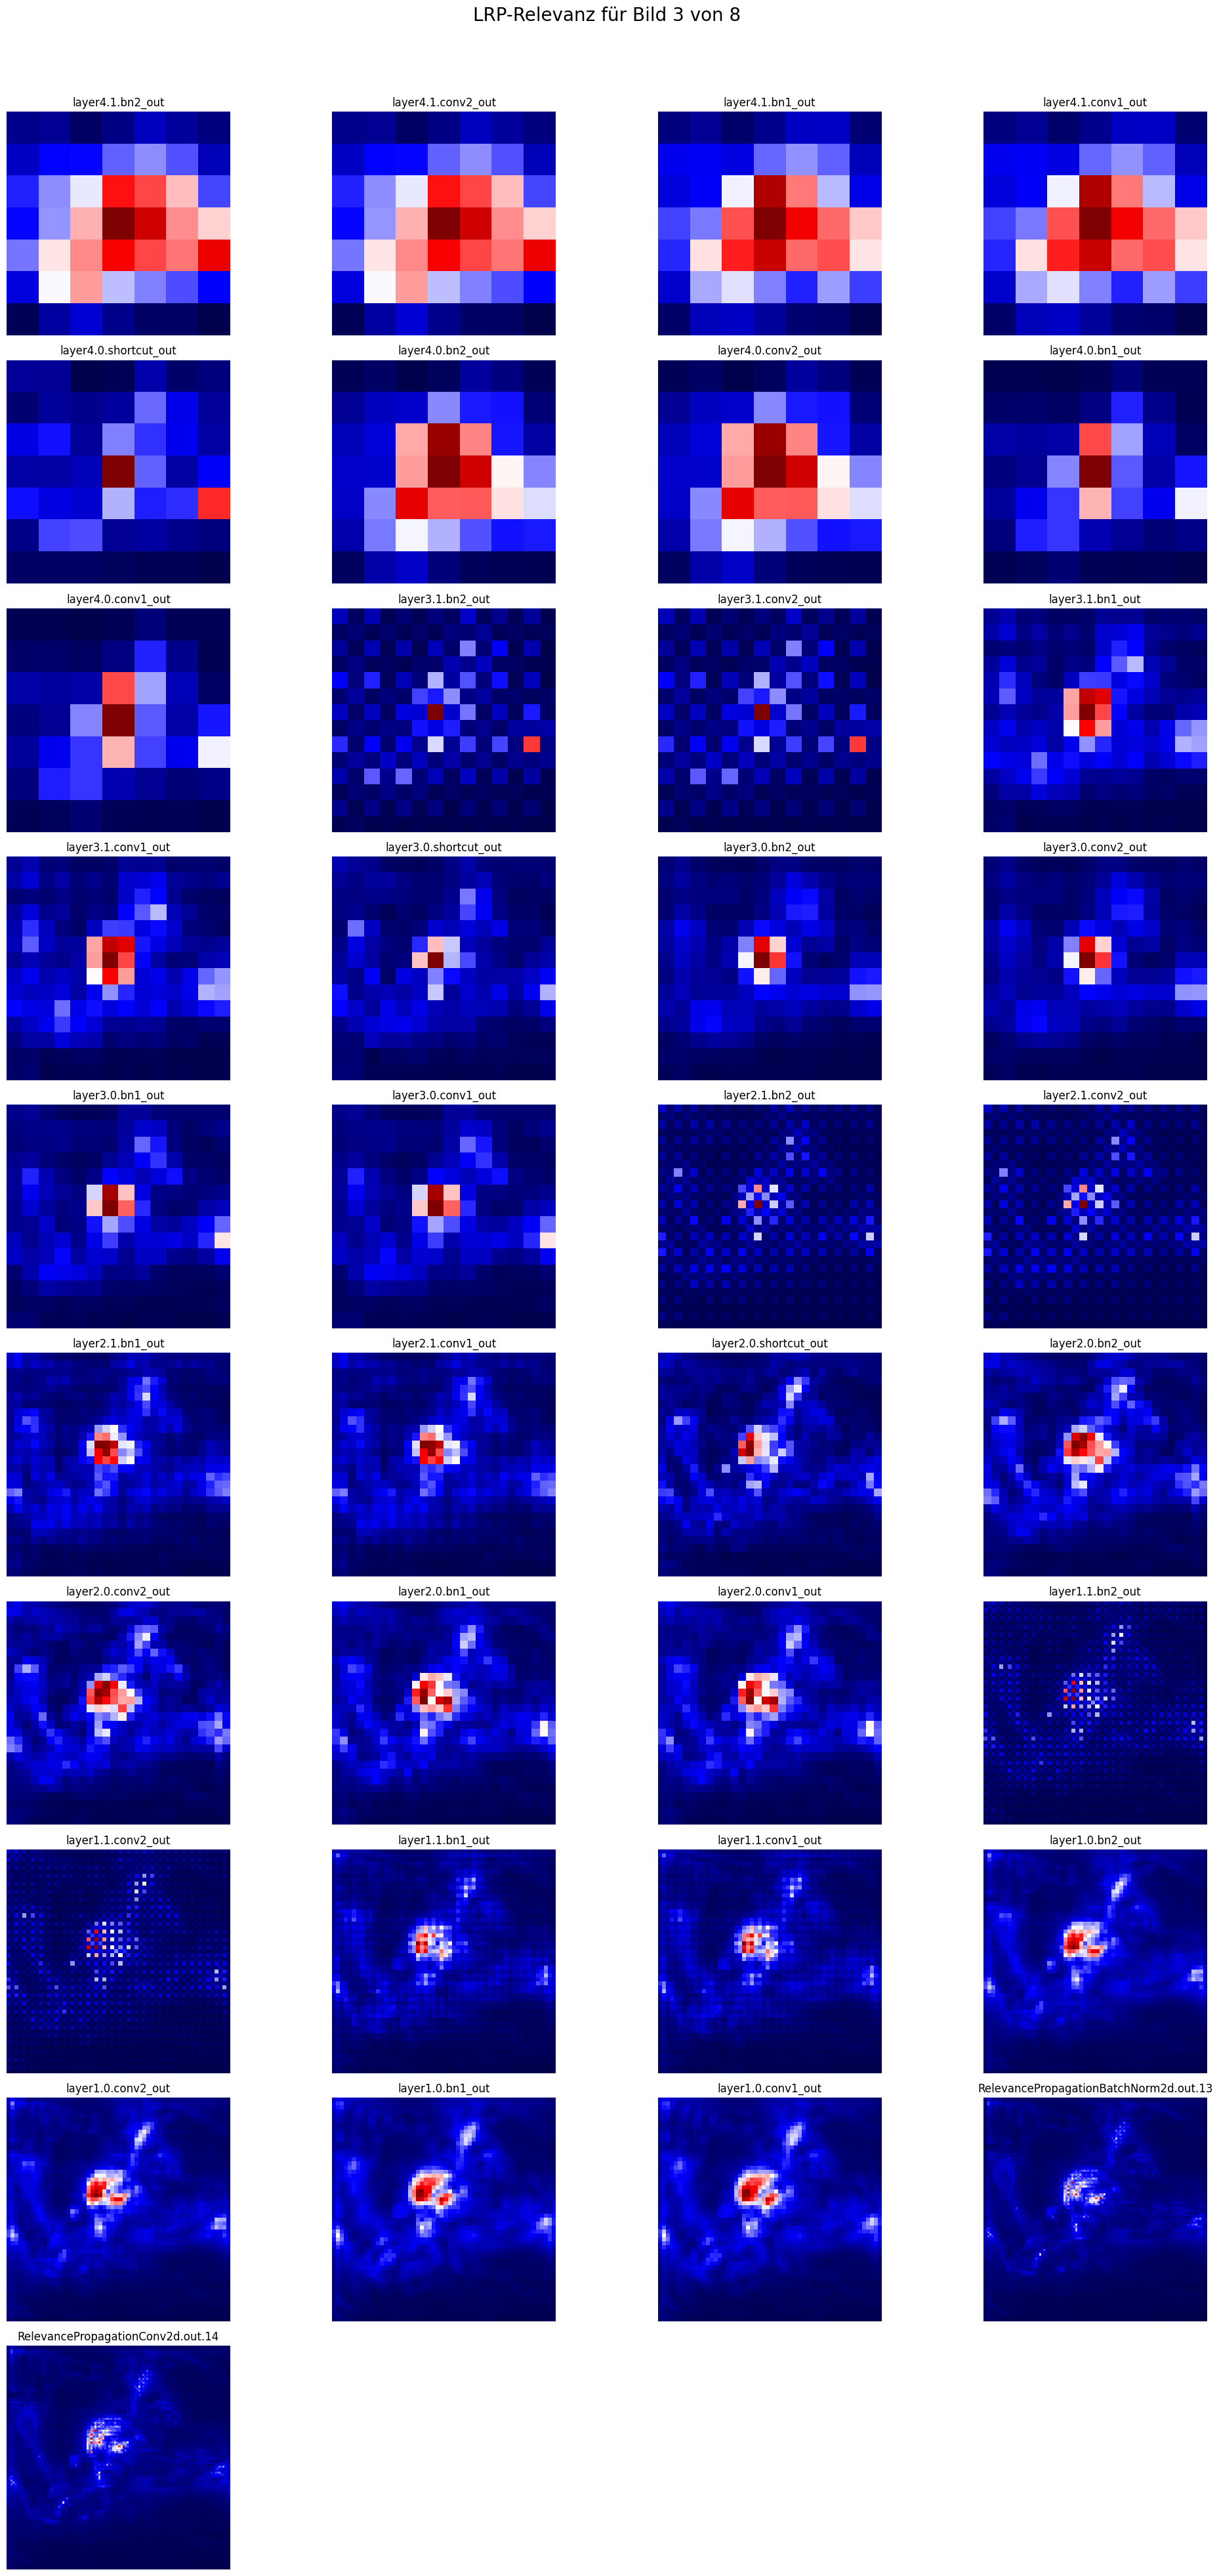

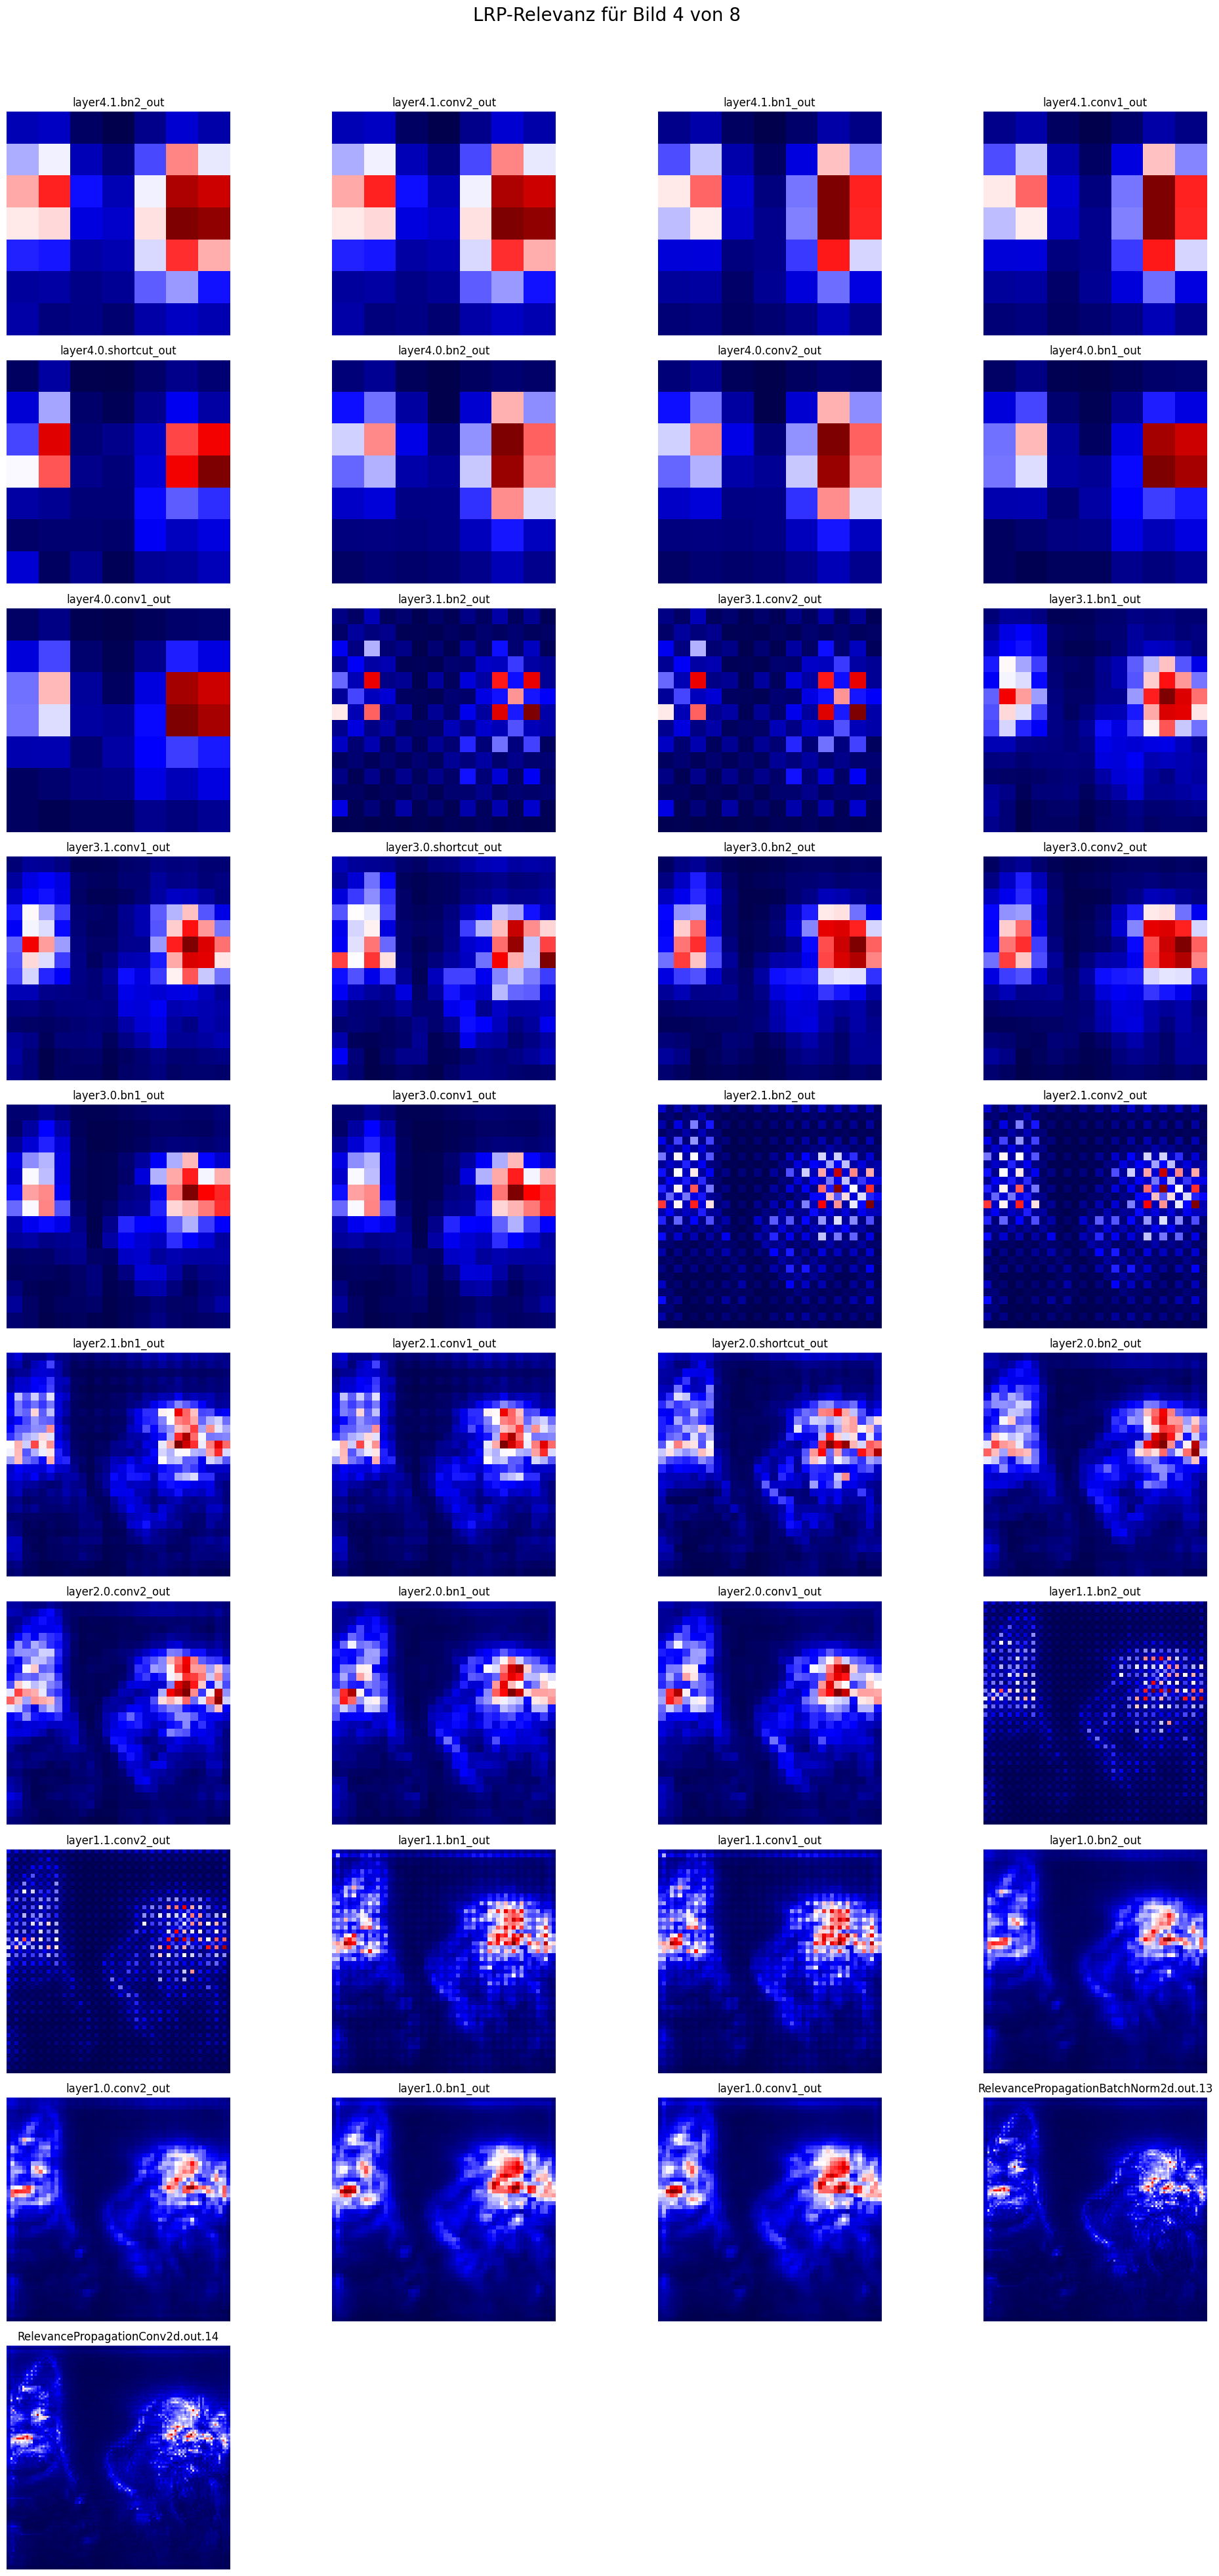

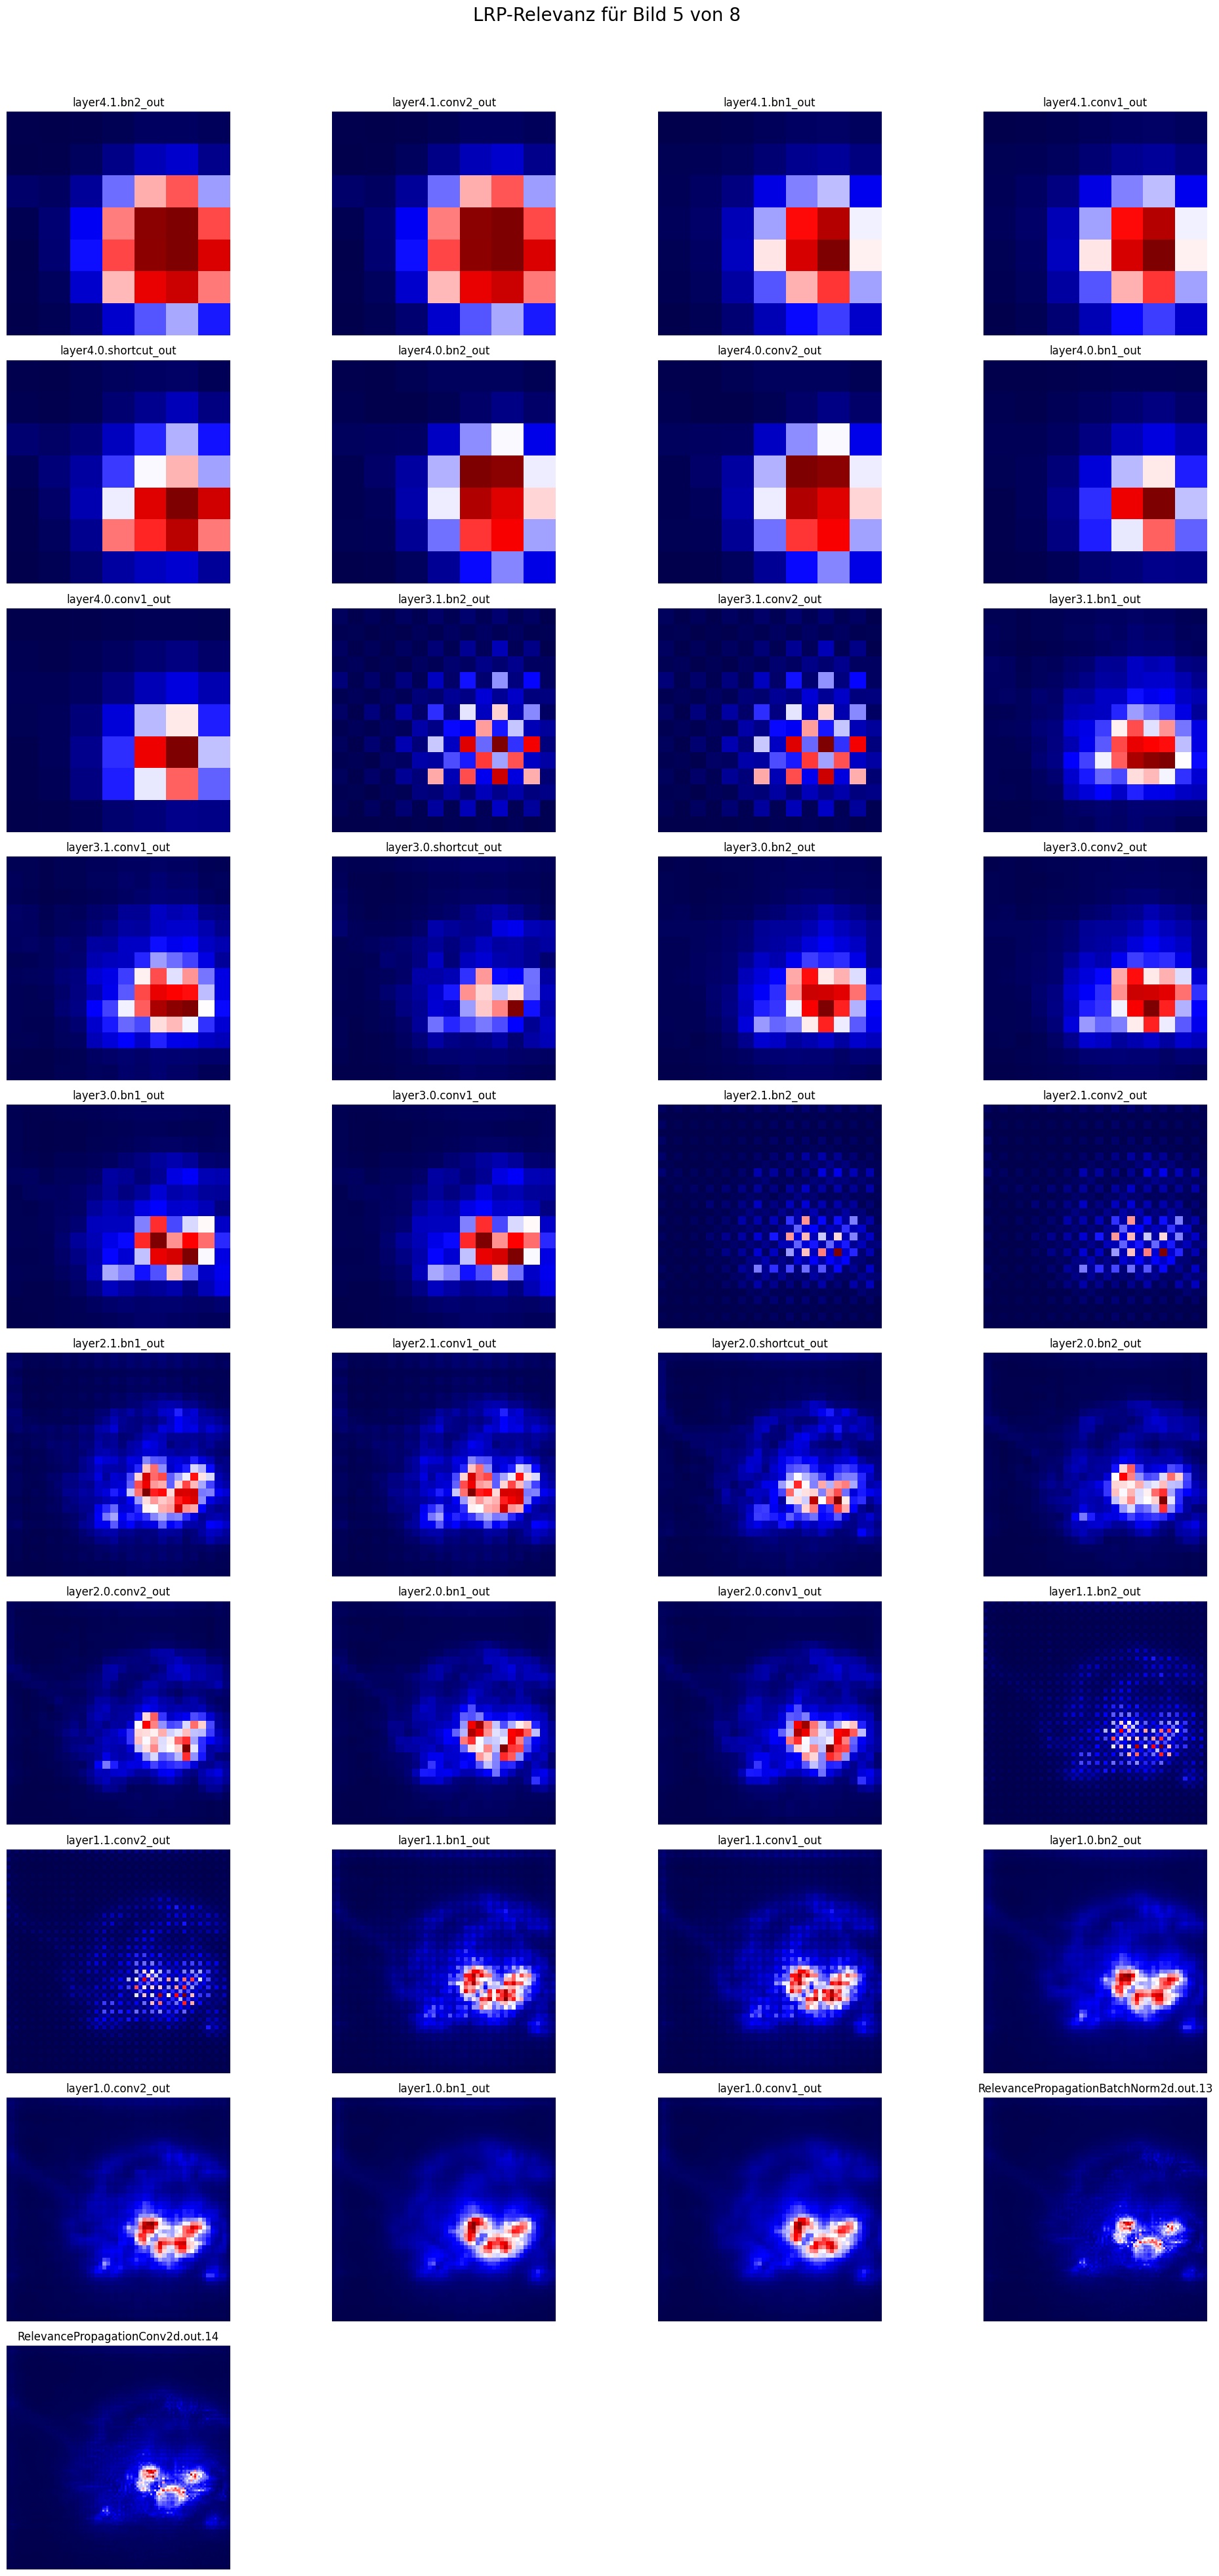

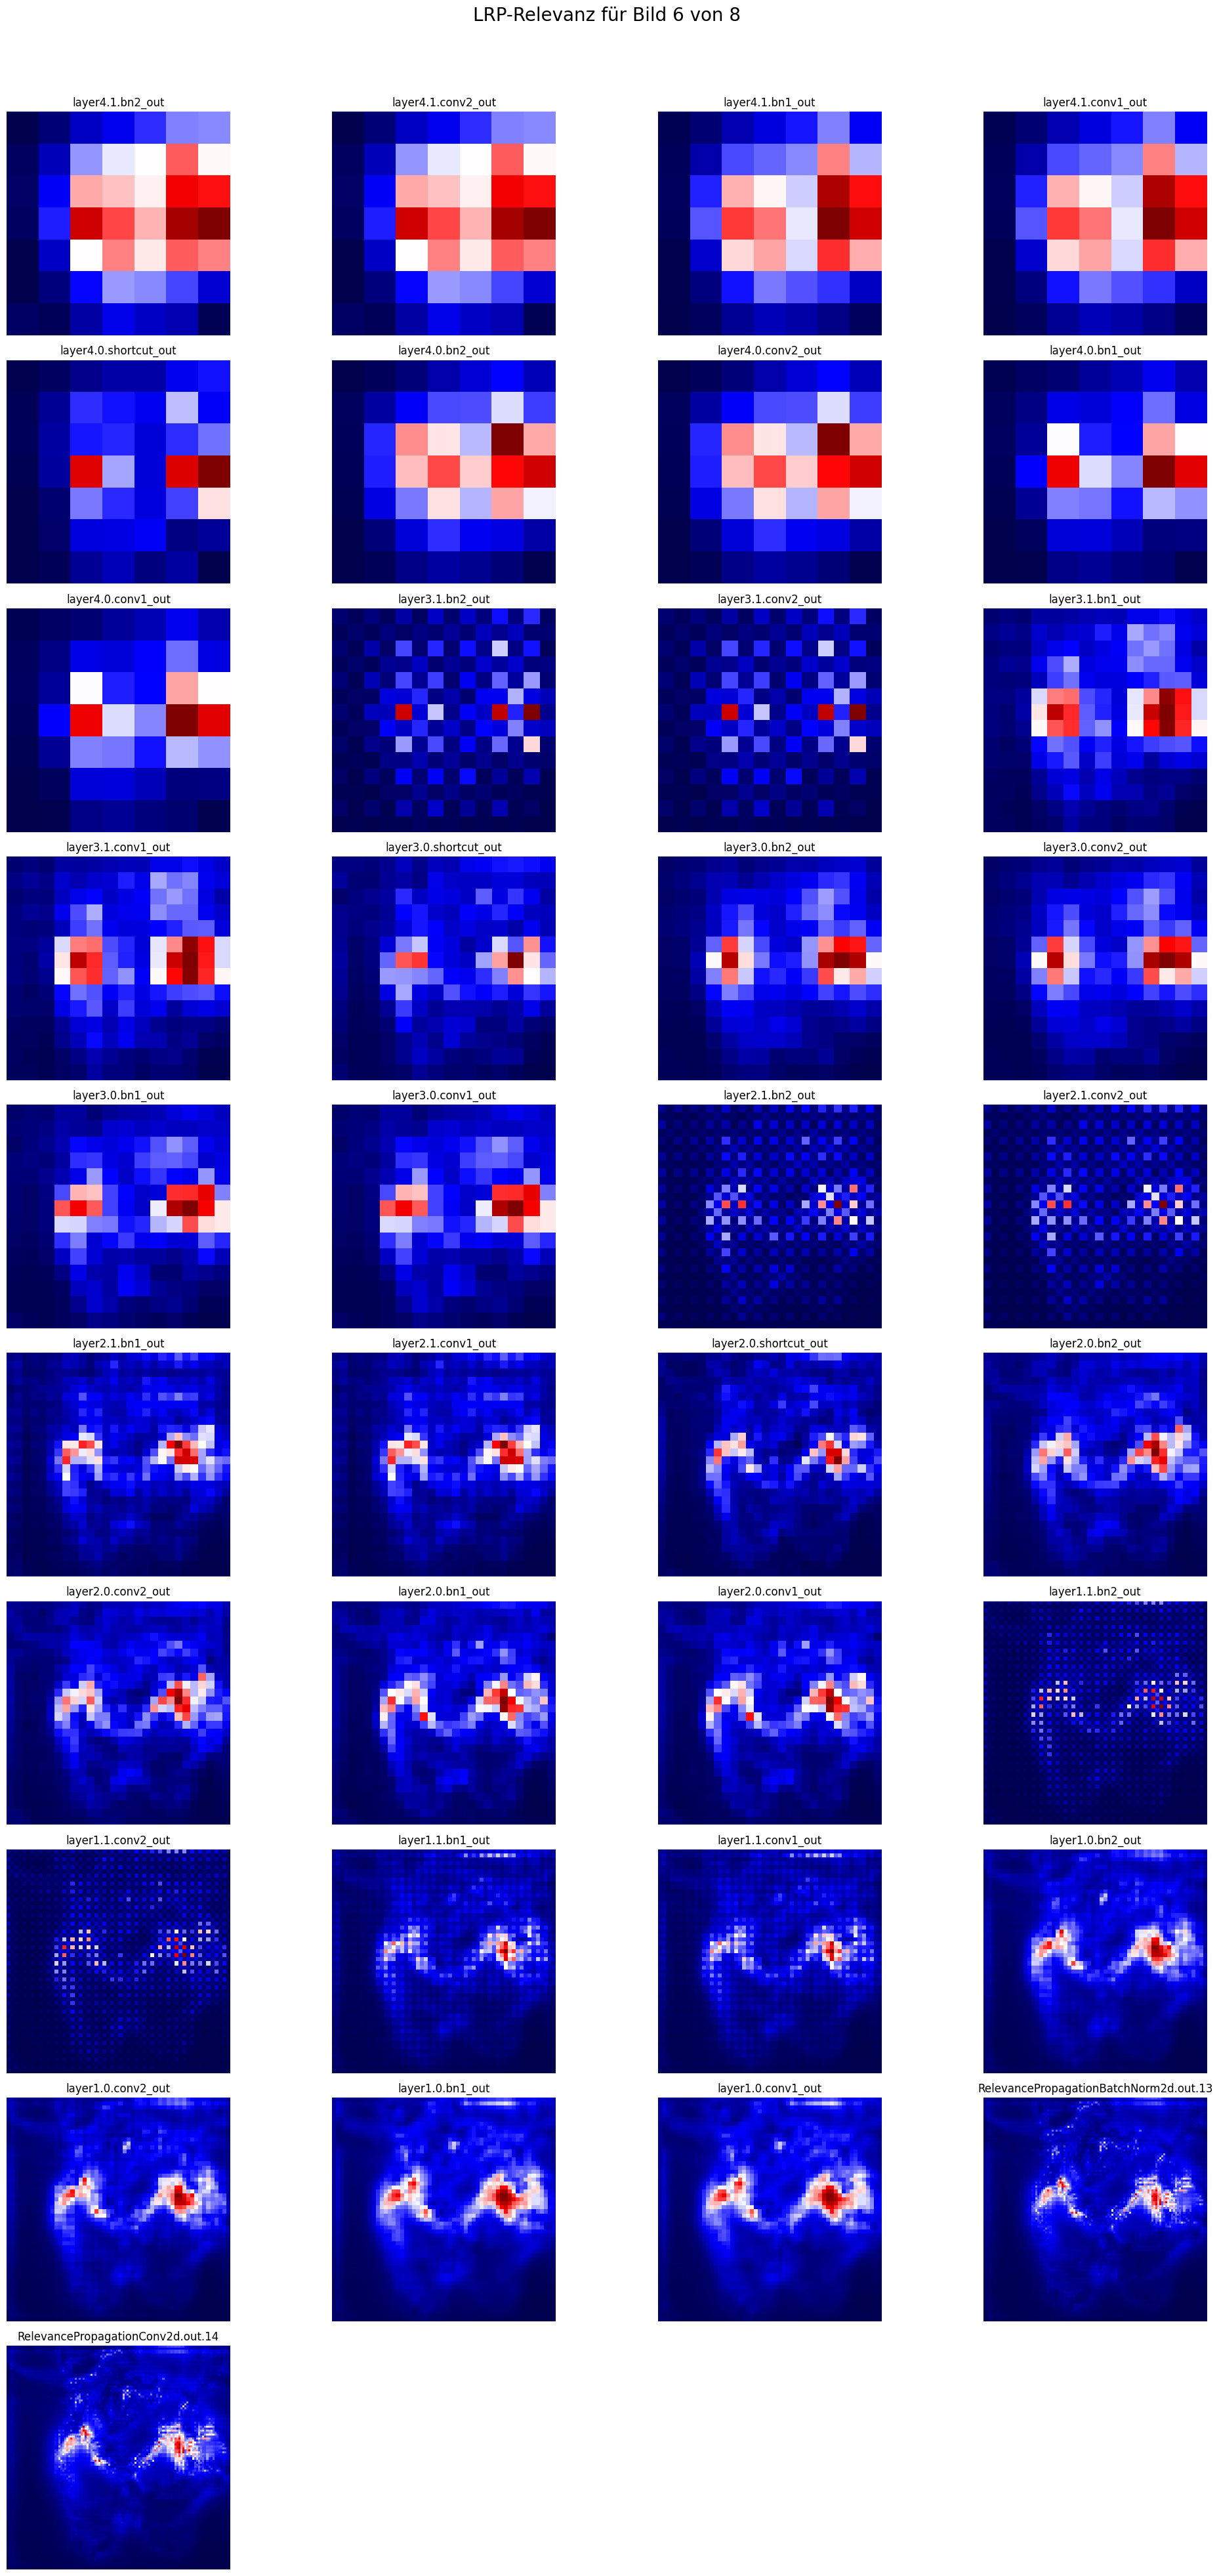

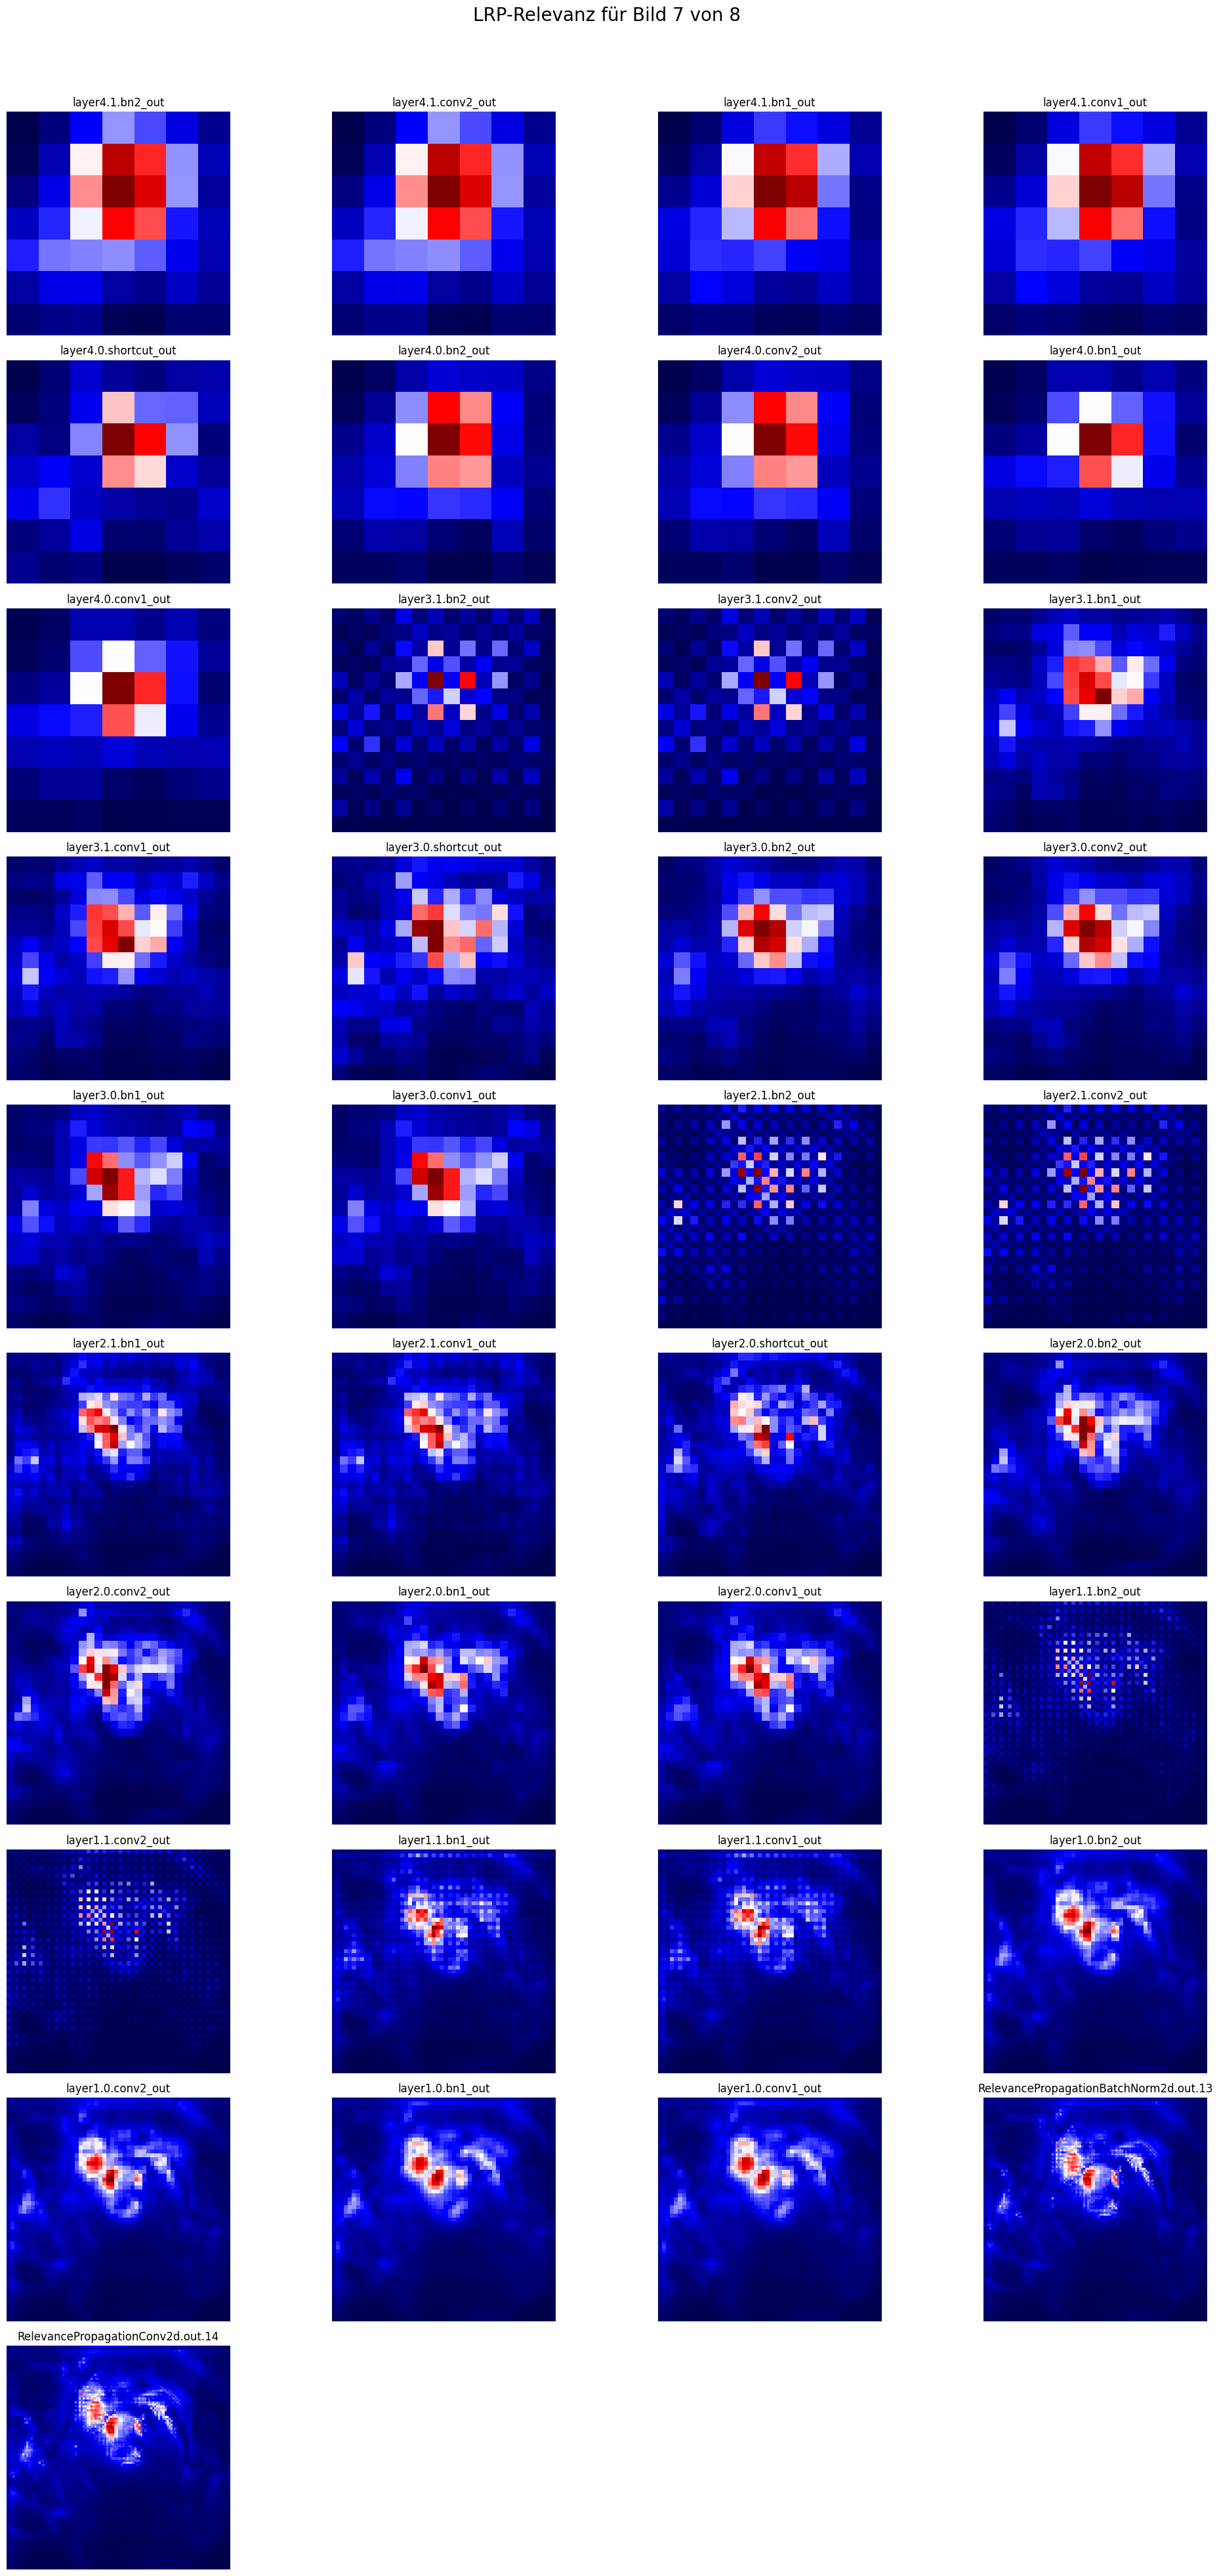

In [ ]:

import matplotlib.pyplot as plt
import math
# size(0) gibt die Größe der Batch-Dimension zurück
batch_size = input_images.size(0)
print("Batch size:", batch_size)

cols = 4

# über alle Bilder im Batch iterieren
for img_idx in range(batch_size):
    # Liste um die bearbeiteten Relevance Maps zu speichern
    processed_relevance_maps = []
    # auch die Namen der bearbeiteten Relevanz-Layer speichern, da diese für die Titel der Plots benötigt werden
    processed_names = []
    # über alle Relevanzen in der Liste relevances iterieren
    for relevance, name in zip(relevances, names):
        
        # es werden nur Layers geplottet, die im mapping sind
        if name not in used_relevance_layers:
            continue
            
        relevance_map = relevance.detach() [img_idx]
        #print(f"Processing layer: {name}, relevance_map shape: {relevance_map.shape}")

        # da die Dimensionen der Layers unterschiedlich sind, anders als bei den Feature Maps, wo sie immer [B, C, H, W]
        # die Dimensionen der Relevance Maps können variieren
        #relevance_map = relevance[img_idx].squeeze(0) 
        # torch.sum summiert über die Kanäle (Dimension 0 = Channels)
        # und dann wird durch die Anzahl der Kanäle geteilt --> Mittelwert
        # das ist nötig da wir eine 2D Darstellung wollen
        # danach haben wir eine [H, W] Matrix
        if relevance_map.dim() == 3: # [C,H,W]
            mean_relevance_map = torch.sum(relevance_map, 0) / relevance_map.shape[0]  
        else: # R.dim() == 1: [B,K] -- sind 3 letze Layers, sind nicht 2d darstellbar, da sie die Klassenscores darstellen, deswegen
           continue
        processed_relevance_maps.append(mean_relevance_map.cpu().numpy())
        processed_names.append(name)
    #print("len(processed_relevance_maps):", len(processed_relevance_maps))
    #print("len(processed_names):", len(processed_names))
    #print ("\n Processed relevance maps shape")
    #for rm in processed_relevance_maps:
        #print(rm.shape)
    """
    # Plot the relevance maps
    fig = plt.figure(figsize=(35, 60))
    for i in range(len(processed_relevance_maps)):
        ax = fig.add_subplot(20, 7, i + 1)
        ax.imshow(processed_relevance_maps[i], cmap='bwr')
        ax.axis("off")
        ax.set_title(processed_names[i].split('(')[0], fontsize=16)
        
    """

    # Plot
    L = len(processed_relevance_maps)

    if L == 0:
        continue

    rows = math.ceil(L / cols)
    fig = plt.figure(figsize=(5 * cols, 4 * rows))

    for i in range(L):
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(processed_relevance_maps[i], cmap="seismic")
        ax.axis("off")
        ax.set_title(processed_names[i], fontsize=12)

    fig.suptitle(f"LRP-Relevanz für Bild {img_idx} von {batch_size}", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  
    plt.show()
